In [20]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 1: Setup
# Purpose: Initialize paths, device, imports for ablation study
# ============================================================

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from tqdm.auto import tqdm

PROJECT_ROOT = "/mnt/g/banglafake-detection"
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "csebuetnlp/banglabert"
MAX_LENGTH = 256

print("Device:", device)

Device: cuda


In [21]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 2: Define Model Architectures (Baseline + Ablations + Full)
# ============================================================

class BanglaBERTOnly(nn.Module):
    def __init__(self, model_name, num_classes=2, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # CLS token (ELECTRA has no pooler)
        output = self.dropout(cls_output)
        return self.classifier(output)


class BanglaBERTWithCNN(nn.Module):
    def __init__(self, model_name, cnn_channels=256, kernel_size=3, num_classes=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.cnn = nn.Conv1d(
            self.bert.config.hidden_size, cnn_channels, kernel_size,
            padding=kernel_size // 2
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(cnn_channels, num_classes)

    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        x = x * mask
        x = x.permute(0, 2, 1)
        x = torch.relu(self.cnn(x))
        pooled = torch.mean(x, dim=2)
        return self.classifier(self.dropout(pooled))


class BanglaBERTWithAttention(nn.Module):
    def __init__(self, model_name, attention_dim=128, num_classes=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.attention_projection = nn.Linear(self.bert.config.hidden_size, attention_dim)
        self.attention_score = nn.Linear(attention_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        att_hidden = torch.tanh(self.attention_projection(x))
        att_logits = self.attention_score(att_hidden).squeeze(-1)
        att_logits = att_logits.masked_fill(attention_mask == 0, -1e9)
        att_weights = torch.softmax(att_logits, dim=1)
        attended = (x * att_weights.unsqueeze(-1)).sum(dim=1)
        return self.classifier(self.dropout(attended))


class BanglaBERTFullModel(nn.Module):
    def __init__(self, model_name, cnn_channels=256, kernel_size=3, attention_dim=128, num_classes=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.cnn = nn.Conv1d(
            self.bert.config.hidden_size, cnn_channels, kernel_size,
            padding=kernel_size // 2
        )
        self.attention_projection = nn.Linear(cnn_channels, attention_dim)
        self.attention_score = nn.Linear(attention_dim, 1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(cnn_channels, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        x = x * mask
        x = x.permute(0, 2, 1)
        x = torch.relu(self.cnn(x))
        x = x.permute(0, 2, 1)
        att_hidden = torch.tanh(self.attention_projection(x))
        att_logits = self.attention_score(att_hidden).squeeze(-1)
        att_logits = att_logits.masked_fill(attention_mask == 0, -1e9)
        att_weights = torch.softmax(att_logits, dim=1)
        attended = (x * att_weights.unsqueeze(-1)).sum(dim=1)
        return self.classifier(attended)


print("Architectures defined: BanglaBERTOnly, BanglaBERTWithCNN, BanglaBERTWithAttention, BanglaBERTFullModel")

Architectures defined: BanglaBERTOnly, BanglaBERTWithCNN, BanglaBERTWithAttention, BanglaBERTFullModel


In [22]:
# ============================================================
# Cell 3: Load Data, Tokenizer, Dataset, DataLoaders
# ============================================================

train_df = pd.read_csv(os.path.join(PROCESSED_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(PROCESSED_DIR, "validation.csv"))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, "test.csv"))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class BanglaFakeNewsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.dataframe = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        text = str(self.dataframe.iloc[idx]["text"])
        label = int(self.dataframe.iloc[idx]["label"])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }


train_loader = DataLoader(
    BanglaFakeNewsDataset(train_df, tokenizer, MAX_LENGTH),
    batch_size=8, shuffle=True, pin_memory=True
)
val_loader = DataLoader(
    BanglaFakeNewsDataset(val_df, tokenizer, MAX_LENGTH),
    batch_size=8, shuffle=False, pin_memory=True
)
test_loader = DataLoader(
    BanglaFakeNewsDataset(test_df, tokenizer, MAX_LENGTH),
    batch_size=8, shuffle=False, pin_memory=True
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

Train: 2790 Val: 598 Test: 599


In [11]:
# ============================================================
# Cell 4: Train/Eval Helper Functions
# ============================================================

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0
    for batch in tqdm(loader, desc="Train", leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)


def eval_split(model, loader, device):
    model.eval()
    preds, labels_all, probs = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Eval", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            prob = torch.softmax(logits, dim=1)[:, 1]
            pred = torch.argmax(logits, dim=1)

            preds.extend(pred.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            probs.extend(prob.cpu().numpy())
    return {
        "Accuracy": accuracy_score(labels_all, preds),
        "Precision": precision_score(labels_all, preds),
        "Recall": recall_score(labels_all, preds),
        "F1": f1_score(labels_all, preds),
        "ROC-AUC": roc_auc_score(labels_all, probs)
    }


print("Train/eval functions ready.")

Train/eval functions ready.


In [12]:
# ============================================================
# Cell 5: Train Ablation Models (BanglaBERT-only, +CNN, +Attention)
# Full train set (2790), same NUM_EPOCHS=3, best-val-F1 checkpoint
# ============================================================

NUM_EPOCHS = 3
ablation_results = {}

model_configs = {
    "BanglaBERT-only": lambda: BanglaBERTOnly(MODEL_NAME),
    "BanglaBERT+CNN": lambda: BanglaBERTWithCNN(MODEL_NAME),
    "BanglaBERT+Attention": lambda: BanglaBERTWithAttention(MODEL_NAME),
}

for name, ctor in model_configs.items():
    print(f"\n=== Training {name} ===")
    model = ctor().to(device)
    optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    best_val_f1, best_state = -1, None

    for epoch in range(NUM_EPOCHS):
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        val_metrics = eval_split(model, val_loader, device)
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} val_f1={val_metrics['F1']:.4f}")
        if val_metrics['F1'] > best_val_f1:
            best_val_f1 = val_metrics['F1']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    torch.save(best_state, os.path.join(MODELS_DIR, f"ablation_{name.replace('+','_').replace(' ','_')}.pt"))
    test_metrics = eval_split(model, test_loader, device)
    ablation_results[name] = test_metrics
    print(f"{name} TEST:", test_metrics)

    del model
    torch.cuda.empty_cache()

print("\nAblation training complete.")


=== Training BanglaBERT-only ===


Train:   0%|          | 0/349 [00:00<?, ?it/s]

Eval:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 1: train_loss=0.1712 val_f1=0.9803


Train:   0%|          | 0/349 [00:00<?, ?it/s]

...

Epoch 2: train_loss=0.0965 val_f1=0.9834


Train:   0%|          | 0/349 [00:00<?, ?it/s]

Eval:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 3: train_loss=0.0749 val_f1=0.9799


KeyboardInterrupt: 

In [ ]:
# ============================================================
# Cell 6: Load Existing Full Model Checkpoint & Evaluate (sanity check)
# ============================================================

full_model = BanglaBERTFullModel(MODEL_NAME).to(device)
checkpoint_path = os.path.join(MODELS_DIR, "best_banglabert_cnn_attention.pt")
checkpoint = torch.load(checkpoint_path, map_location=device)
full_model.load_state_dict(checkpoint["model_state_dict"])

full_model_metrics = eval_split(full_model, test_loader, device)
ablation_results["BanglaBERT+CNN+Attention (Full)"] = full_model_metrics
print("Full Model TEST (should match Notebook 2 results ~0.9733 acc):", full_model_metrics)

NameError: name 'eval_split' is not defined

In [ ]:
# ============================================================
# Cell 7: Final Ablation Comparison Table
# ============================================================

comparison_df = pd.DataFrame(ablation_results).T
comparison_df = comparison_df.round(4)
display(comparison_df)

output_path = os.path.join(REPORTS_DIR, "ablation_comparison_table.csv")
comparison_df.to_csv(output_path)
print("\nSaved:", output_path)

NameError: name 'ablation_results' is not defined

In [ ]:
# ============================================================
# Cell 8: Collect Test Predictions for All Ablation Models
# ============================================================

all_preds = {}
true_labels = None

# Ablation models
ablation_paths = {
    "BanglaBERT-only": "ablation_BanglaBERT-only.pt",
    "BanglaBERT+CNN": "ablation_BanglaBERT_CNN.pt",
    "BanglaBERT+Attention": "ablation_BanglaBERT_Attention.pt",
}

ablation_classes = {
    "BanglaBERT-only": BanglaBERTOnly,
    "BanglaBERT+CNN": BanglaBERTWithCNN,
    "BanglaBERT+Attention": BanglaBERTWithAttention,
}

for name, fname in ablation_paths.items():
    model = ablation_classes[name](MODEL_NAME).to(device)
    model.load_state_dict(torch.load(os.path.join(MODELS_DIR, fname), map_location=device))
    model.eval()

    preds, labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            logits = model(input_ids, attention_mask)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy())
            labels.extend(batch['labels'].numpy())

    all_preds[name] = np.array(preds)
    if true_labels is None:
        true_labels = np.array(labels)

    del model
    torch.cuda.empty_cache()

# Full model
full_model = BanglaBERTFullModel(MODEL_NAME).to(device)
checkpoint = torch.load(
    os.path.join(MODELS_DIR, "best_banglabert_cnn_attention.pt"),
    map_location=device
)
full_model.load_state_dict(checkpoint["model_state_dict"])
full_model.eval()

preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        logits = full_model(input_ids, attention_mask)
        pred = torch.argmax(logits, dim=1)
        preds.extend(pred.cpu().numpy())

all_preds["BanglaBERT+CNN+Attention (Full)"] = np.array(preds)

del full_model
torch.cuda.empty_cache()

print("Predictions collected for:", list(all_preds.keys()))
print("true_labels shape:", true_labels.shape)

Predictions collected for: ['BanglaBERT-only', 'BanglaBERT+CNN', 'BanglaBERT+Attention', 'BanglaBERT+CNN+Attention (Full)']
true_labels shape: (599,)


In [ ]:
# ============================================================
# Cell 9: McNemar's Test — Baseline vs Each Variant
# Purpose: Check if performance differences are statistically significant
# ============================================================

from statsmodels.stats.contingency_tables import mcnemar

correct = {name: (preds == true_labels).astype(int) for name, preds in all_preds.items()}

baseline_name = "BanglaBERT-only"
mcnemar_results = []

for name in all_preds:
    if name == baseline_name:
        continue
    b_correct = correct[baseline_name]
    v_correct = correct[name]

    n01 = np.sum((b_correct == 1) & (v_correct == 0))
    n10 = np.sum((b_correct == 0) & (v_correct == 1))
    n00 = np.sum((b_correct == 0) & (v_correct == 0))
    n11 = np.sum((b_correct == 1) & (v_correct == 1))

    table = [[n11, n01], [n10, n00]]
    result = mcnemar(table, exact=(n01 + n10 < 25), correction=True)

    mcnemar_results.append({
        "Comparison": f"{baseline_name} vs {name}",
        "Baseline_correct_only": n01,
        "Variant_correct_only": n10,
        "statistic": result.statistic,
        "p_value": result.pvalue,
        "Significant (p<0.05)": result.pvalue < 0.05
    })

mcnemar_df = pd.DataFrame(mcnemar_results)
display(mcnemar_df)

mcnemar_df.to_csv(os.path.join(REPORTS_DIR, "mcnemar_test_results.csv"), index=False)
print("\nSaved:", os.path.join(REPORTS_DIR, "mcnemar_test_results.csv"))

,Comparison,Baseline_correct_only,Variant_correct_only,statistic,p_value,Significant (p<0.05)
0,BanglaBERT-only vs BanglaBERT+CNN,7,5,5.0,0.774414,False
1,BanglaBERT-only vs BanglaBERT+Attention,3,4,3.0,1.000000,False
2,BanglaBERT-only vs BanglaBERT+CNN+Attention (F...,9,5,5.0,0.423950,False



Saved: /mnt/g/banglafake-detection/reports/mcnemar_test_results.csv


In [ ]:
# Cell: Quick re-setup (if kernel restarted)
import os
import numpy as np

PROJECT_ROOT = "/mnt/g/banglafake-detection"
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")
FIGURES_DIR = os.path.join(REPORTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
print("Ready:", FIGURES_DIR)

Ready: /mnt/g/banglafake-detection/reports/figures


In [ ]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 19b: Fix — Define FIGURES_DIR (missing in this notebook)
# ============================================================

FIGURES_DIR = os.path.join(REPORTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
print("FIGURES_DIR set:", FIGURES_DIR)

FIGURES_DIR set: /mnt/g/banglafake-detection/reports/figures


In [ ]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 10: Multi-Seed Robustness Check (3 seeds) — All 4 Models
# Purpose: Verify if Baseline > Full model ranking holds across seeds
# ============================================================

import random

SEEDS = [42, 123, 2024]
NUM_EPOCHS = 3
multi_seed_results = []

model_configs = {
    "BanglaBERT-only": lambda: BanglaBERTOnly(MODEL_NAME),
    "BanglaBERT+CNN": lambda: BanglaBERTWithCNN(MODEL_NAME),
    "BanglaBERT+Attention": lambda: BanglaBERTWithAttention(MODEL_NAME),
    "BanglaBERT+CNN+Attention (Full)": lambda: BanglaBERTFullModel(MODEL_NAME),
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

for seed in SEEDS:
    print(f"\n{'='*20} SEED {seed} {'='*20}")
    set_seed(seed)

    # Rebuild loaders with seeded shuffling
    g = torch.Generator()
    g.manual_seed(seed)
    train_loader_seed = DataLoader(BanglaFakeNewsDataset(train_df, tokenizer, MAX_LENGTH),
                                    batch_size=8, shuffle=True, generator=g, pin_memory=True)

    for name, ctor in model_configs.items():
        print(f"\n--- {name} (seed {seed}) ---")
        model = ctor().to(device)
        optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
        best_val_f1, best_state = -1, None

        for epoch in range(NUM_EPOCHS):
            train_loss = train_one_epoch(model, train_loader_seed, optimizer, device)
            val_metrics = eval_split(model, val_loader, device)
            if val_metrics['F1'] > best_val_f1:
                best_val_f1 = val_metrics['F1']
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        model.load_state_dict(best_state)
        test_metrics = eval_split(model, test_loader, device)
        test_metrics["Model"] = name
        test_metrics["Seed"] = seed
        multi_seed_results.append(test_metrics)
        print(f"{name} seed={seed} TEST:", test_metrics)

        del model, optimizer
        torch.cuda.empty_cache()

multi_seed_df = pd.DataFrame(multi_seed_results)
summary_df = multi_seed_df.groupby("Model")[["Accuracy","Precision","Recall","F1","ROC-AUC"]].agg(['mean','std']).round(4)

display(multi_seed_df)
display(summary_df)

multi_seed_df.to_csv(os.path.join(REPORTS_DIR, "multi_seed_raw_results.csv"), index=False)
summary_df.to_csv(os.path.join(REPORTS_DIR, "multi_seed_summary.csv"))
print("\nSaved multi_seed_raw_results.csv and multi_seed_summary.csv")


==================== SEED 42 ====================


NameError: name 'BanglaFakeNewsDataset' is not defined

In [ ]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 11: Repeated-Measures ANOVA — Confirm No Significant 
#          Architecture Effect Across Seeds
# ============================================================

from statsmodels.stats.anova import AnovaRM

# Reshape for repeated-measures ANOVA (Model = within-subject factor, Seed = subject)
anova_df = multi_seed_df[["Model", "Seed", "Accuracy", "F1"]].copy()

print("=== Repeated-Measures ANOVA: Accuracy ===")
aovrm_acc = AnovaRM(anova_df, depvar='Accuracy', subject='Seed', within=['Model'])
res_acc = aovrm_acc.fit()
print(res_acc.summary())

print("\n=== Repeated-Measures ANOVA: F1 ===")
aovrm_f1 = AnovaRM(anova_df, depvar='F1', subject='Seed', within=['Model'])
res_f1 = aovrm_f1.fit()
print(res_f1.summary())

# Save results
anova_results = pd.DataFrame({
    "Metric": ["Accuracy", "F1"],
    "F_statistic": [res_acc.anova_table["F Value"].values[0], res_f1.anova_table["F Value"].values[0]],
    "p_value": [res_acc.anova_table["Pr > F"].values[0], res_f1.anova_table["Pr > F"].values[0]]
})
anova_results["Significant (p<0.05)"] = anova_results["p_value"] < 0.05

display(anova_results)
anova_results.to_csv(os.path.join(REPORTS_DIR, "anova_architecture_effect.csv"), index=False)
print("\nSaved: anova_architecture_effect.csv")

=== Repeated-Measures ANOVA: Accuracy ===
              Anova
      F Value Num DF Den DF Pr > F
----------------------------------
Model  0.0418 3.0000 6.0000 0.9875


=== Repeated-Measures ANOVA: F1 ===
              Anova
      F Value Num DF Den DF Pr > F
----------------------------------
Model  0.0464 3.0000 6.0000 0.9855



,Metric,F_statistic,p_value,Significant (p<0.05)
0,Accuracy,0.041754,0.987517,False
1,F1,0.046410,0.985462,False



Saved: anova_architecture_effect.csv


In [ ]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 12: Inspect Source Distribution for Group-Based Split
# Purpose: Verify source column across train/val/test before
#          building a source-held-out generalization experiment
# ============================================================

# Load raw processed data (need Source column - check if present)
train_full = pd.read_csv(os.path.join(PROCESSED_DIR, "train.csv"))
val_full = pd.read_csv(os.path.join(PROCESSED_DIR, "validation.csv"))
test_full = pd.read_csv(os.path.join(PROCESSED_DIR, "test.csv"))

print("Train columns:", train_full.columns.tolist())
print("\nDoes 'Source' column exist in train.csv?", "Source" in train_full.columns)

if "Source" in train_full.columns:
    all_data = pd.concat([train_full, val_full, test_full])
    source_counts = all_data["Source"].value_counts()
    print("\nTotal unique sources:", source_counts.shape[0])
    print("\nTop 15 sources:")
    print(source_counts.head(15))

    source_label = all_data.groupby("Source")["label"].nunique()
    mixed_sources = source_label[source_label > 1].index.tolist()
    print("\nMixed-label sources:", mixed_sources)
else:
    print("\nWARNING: 'Source' column not in processed CSVs. Need to check Notebook 1 output or raw data for source info.")

Train columns: ['Global_ID', 'text', 'label']

Does 'Source' column exist in train.csv? False



In [ ]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 13: Reconstruct Source Metadata via Raw Data Merge
# Purpose: Recover 'Source' column for train/val/test by 
#          merging on reconstructed 'text' (same method as Notebook 3)
# ============================================================

real_raw = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "raw", "Bangla_Real_News_Dataset.csv"))
fake_raw = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "raw", "Bangla_Fake_News_Dataset.csv"))
raw_df = pd.concat([real_raw, fake_raw], ignore_index=True)

import re
def clean_text_for_analysis(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

raw_df["text"] = (raw_df["Headline"].apply(clean_text_for_analysis) + " " +
                   raw_df["Content"].apply(clean_text_for_analysis)).str.strip()

source_map = raw_df[["text", "Source"]].drop_duplicates(subset=["text"])

train_src = train_df.merge(source_map, on="text", how="left")
val_src   = val_df.merge(source_map, on="text", how="left")
test_src  = test_df.merge(source_map, on="text", how="left")

print("Train missing Source:", train_src["Source"].isna().sum(), "/", len(train_src))
print("Val missing Source:", val_src["Source"].isna().sum(), "/", len(val_src))
print("Test missing Source:", test_src["Source"].isna().sum(), "/", len(test_src))

all_src = pd.concat([train_src, val_src, test_src])
print("\nUnique sources total:", all_src["Source"].nunique())

source_label_counts = all_src.groupby("Source")["label"].nunique()
mixed_sources = source_label_counts[source_label_counts > 1].index.tolist()
print("Mixed-label sources:", mixed_sources)

print("\nTop 10 sources by count:")
print(all_src["Source"].value_counts().head(10))

Train missing Source: 0 / 2790
Val missing Source: 0 / 598
Test missing Source: 0 / 599

Unique sources total: 45
Mixed-label sources: ['Reporter', 'Reuters']

Top 10 sources by count:
Source
Reporter            2443
rumorscanner.com    1116
fact-watch.org       301
Reuters               26
BBC                   10
jachai.org            10
Al Jazeera             8
AFP                    7
Bold Sky               6
CNN                    6
Name: count, dtype: int64


In [ ]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 14: Build Source-Held-Out (Group) Split
# Purpose: Ensure no source appears in both train and test —
#          tests true generalization vs source-shortcut learning
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

full_df = pd.concat([train_src, val_src, test_src], ignore_index=True)
print("Full dataset shape:", full_df.shape)
print("Label distribution (full):", full_df["label"].value_counts().to_dict())

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(full_df, groups=full_df["Source"]))

group_train_df = full_df.iloc[train_idx].reset_index(drop=True)
group_test_df  = full_df.iloc[test_idx].reset_index(drop=True)

# Further split group_train_df into train/val (source-aware, 90/10)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
tr_idx, val_idx = next(gss_val.split(group_train_df, groups=group_train_df["Source"]))
group_train_final = group_train_df.iloc[tr_idx].reset_index(drop=True)
group_val_final   = group_train_df.iloc[val_idx].reset_index(drop=True)

print("\n=== Source-Held-Out Split ===")
print("Train:", group_train_final.shape, group_train_final["label"].value_counts().to_dict())
print("Val:", group_val_final.shape, group_val_final["label"].value_counts().to_dict())
print("Test:", group_test_df.shape, group_test_df["label"].value_counts().to_dict())

train_sources = set(group_train_final["Source"].unique()) | set(group_val_final["Source"].unique())
test_sources = set(group_test_df["Source"].unique())
print("\nSource overlap between (train+val) and test:", train_sources & test_sources)
print("Test-only sources:", test_sources)

Full dataset shape: (3987, 4)
Label distribution (full): {1: 1997, 0: 1990}

=== Source-Held-Out Split ===
Train: (3656, 4) {1: 1980, 0: 1676}
Val: (314, 4) {0: 301, 1: 13}
Test: (17, 4) {0: 13, 1: 4}

Source overlap between (train+val) and test: set()
Test-only sources: {'dhakafactcheck.com', 'The Tribune', 'Arab News', 'jachai.org', 'Science Times', 'bangla.aajtak', 'Reuters '}


In [ ]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 15: Stratified Group Split (Balance-Aware, Source-Held-Out)
# Purpose: Better source-held-out split that also tries to 
#          preserve class balance across folds
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

fold_summaries = []
for fold, (tr_idx, te_idx) in enumerate(sgkf.split(full_df, y=full_df["label"], groups=full_df["Source"])):
    te_fold = full_df.iloc[te_idx]
    fold_summaries.append({
        "Fold": fold,
        "Test_size": len(te_fold),
        "Test_Fake": (te_fold["label"] == 0).sum(),
        "Test_Real": (te_fold["label"] == 1).sum(),
        "Test_sources": te_fold["Source"].nunique()
    })

fold_df = pd.DataFrame(fold_summaries)
display(fold_df)
print("\nPick the most balanced fold (closest to 50/50 Fake/Real) with reasonable size for the held-out test.")

,Fold,Test_size,Test_Fake,Test_Real,Test_sources
0,0,2443,554,1889,1
1,1,1123,1116,7,2
2,2,315,301,14,3
3,3,53,9,44,19
4,4,53,10,43,20



Pick the most balanced fold (closest to 50/50 Fake/Real) with reasonable size for the held-out test.


In [ ]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 16: Source-Held-Out Experiment (Fold 4) — BanglaBERT-only
# Purpose: Train on 19/20 held-in sources, test on genuinely 
#          unseen sources; report balanced accuracy given imbalance
# ============================================================

from sklearn.metrics import balanced_accuracy_score

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(sgkf.split(full_df, y=full_df["label"], groups=full_df["Source"]))
tr_idx, te_idx = splits[4]  # Fold 4

group_train_df = full_df.iloc[tr_idx].reset_index(drop=True)
group_test_df  = full_df.iloc[te_idx].reset_index(drop=True)

print("Held-in train size:", len(group_train_df), group_train_df["label"].value_counts().to_dict())
print("Held-out test size:", len(group_test_df), group_test_df["label"].value_counts().to_dict())
print("Held-out sources:", group_test_df["Source"].unique().tolist())

# 90/10 stratified-group split of held-in data for train/val
sgkf_val = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
tr2_idx, val2_idx = next(sgkf_val.split(group_train_df, y=group_train_df["label"], groups=group_train_df["Source"]))
group_train_final = group_train_df.iloc[tr2_idx].reset_index(drop=True)
group_val_final   = group_train_df.iloc[val2_idx].reset_index(drop=True)

print("\nFinal train:", len(group_train_final), "Final val:", len(group_val_final))

group_train_loader = DataLoader(BanglaFakeNewsDataset(group_train_final, tokenizer, MAX_LENGTH),
                                 batch_size=8, shuffle=True, pin_memory=True)
group_val_loader = DataLoader(BanglaFakeNewsDataset(group_val_final, tokenizer, MAX_LENGTH),
                               batch_size=8, shuffle=False, pin_memory=True)
group_test_loader = DataLoader(BanglaFakeNewsDataset(group_test_df, tokenizer, MAX_LENGTH),
                                batch_size=8, shuffle=False, pin_memory=True)

set_seed(42)
model = BanglaBERTOnly(MODEL_NAME).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
best_val_f1, best_state = -1, None

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, group_train_loader, optimizer, device)
    val_metrics = eval_split(model, group_val_loader, device)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} val_f1={val_metrics['F1']:.4f}")
    if val_metrics['F1'] > best_val_f1:
        best_val_f1 = val_metrics['F1']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)

# Evaluate on held-out (unseen) sources
model.eval()
preds, labels_all, probs = [], [], []
with torch.no_grad():
    for batch in group_test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        logits = model(input_ids, attention_mask)
        prob = torch.softmax(logits, dim=1)[:, 1]
        pred = torch.argmax(logits, dim=1)
        preds.extend(pred.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
        probs.extend(prob.cpu().numpy())

acc = accuracy_score(labels_all, preds)
bal_acc = balanced_accuracy_score(labels_all, preds)
f1 = f1_score(labels_all, preds)

print("\n=== Source-Held-Out Test Results (unseen sources) ===")
print("Accuracy:", acc)
print("Balanced Accuracy:", bal_acc)
print("F1:", f1)
print("Predictions:", preds)
print("True labels:", labels_all)

torch.save(best_state, os.path.join(MODELS_DIR, "source_heldout_banglabert_only.pt"))

source_heldout_result = pd.DataFrame([{
    "Experiment": "Source-Held-Out (Fold 4, unseen sources)",
    "Test_size": len(group_test_df),
    "Accuracy": acc,
    "Balanced_Accuracy": bal_acc,
    "F1": f1
}])
source_heldout_result.to_csv(os.path.join(REPORTS_DIR, "source_heldout_results.csv"), index=False)
print("\nSaved: source_heldout_results.csv")

Held-in train size: 3934 {0: 1980, 1: 1954}
Held-out test size: 53 {1: 43, 0: 10}
Held-out sources: ['BBC', 'Ei Somoy', 'Bold Sky', 'Arab News', 'The Guardian', 'jachai.org', 'Health Line', 'Daily Sun', 'ND TV', 'Reuters ', 'New York Times', 'Reuters\n', 'Amazon', 'UNB', 'National Geography', 'France24', 'India Today', 'Science Times', 'The Times', 'The Business Standard']

Final train: 2818 Final val: 1116


Train:   0%|          | 0/353 [00:00<?, ?it/s]

Eval:   0%|          | 0/140 [00:00<?, ?it/s]

/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 1: train_loss=0.1571 val_f1=0.0000


...

/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Train:   0%|          | 0/353 [00:00<?, ?it/s]

Eval:   0%|          | 0/140 [00:00<?, ?it/s]

/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 3: train_loss=0.0318 val_f1=0.0000

=== Source-Held-Out Test Results (unseen sources) ===
Accuracy: 0.9245283018867925
Balanced Accuracy: 0.8383720930232558
F1: 0.9545454545454546
Predictions: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1)]
True labels: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int

In [ ]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 17: Bootstrap Confidence Interval for Source-Held-Out Result
# Purpose: Quantify uncertainty around balanced accuracy (n=53)
# ============================================================

n_bootstrap = 2000
rng = np.random.RandomState(42)

preds_arr = np.array(preds)
labels_arr = np.array(labels_all)
n = len(labels_arr)

boot_bal_acc = []
boot_acc = []

for _ in range(n_bootstrap):
    idx = rng.choice(n, size=n, replace=True)
    if len(np.unique(labels_arr[idx])) < 2:
        continue
    boot_bal_acc.append(balanced_accuracy_score(labels_arr[idx], preds_arr[idx]))
    boot_acc.append(accuracy_score(labels_arr[idx], preds_arr[idx]))

boot_bal_acc = np.array(boot_bal_acc)
boot_acc = np.array(boot_acc)

ci_bal_acc = np.percentile(boot_bal_acc, [2.5, 97.5])
ci_acc = np.percentile(boot_acc, [2.5, 97.5])

print("Balanced Accuracy: {:.4f}  95% CI: [{:.4f}, {:.4f}]".format(bal_acc, *ci_bal_acc))
print("Accuracy: {:.4f}  95% CI: [{:.4f}, {:.4f}]".format(acc, *ci_acc))
print("Valid bootstrap resamples used:", len(boot_bal_acc), "/", n_bootstrap)

ci_results = pd.DataFrame([{
    "Metric": "Balanced Accuracy",
    "Point_Estimate": bal_acc,
    "CI_Lower": ci_bal_acc[0],
    "CI_Upper": ci_bal_acc[1],
    "N": n
}, {
    "Metric": "Accuracy",
    "Point_Estimate": acc,
    "CI_Lower": ci_acc[0],
    "CI_Upper": ci_acc[1],
    "N": n
}])
display(ci_results)
ci_results.to_csv(os.path.join(REPORTS_DIR, "source_heldout_ci.csv"), index=False)
print("\nSaved: source_heldout_ci.csv")

Balanced Accuracy: 0.8384  95% CI: [0.6764, 0.9796]
Accuracy: 0.9245  95% CI: [0.8491, 0.9811]
Valid bootstrap resamples used: 2000 / 2000


,Metric,Point_Estimate,CI_Lower,CI_Upper,N
0,Balanced Accuracy,0.838372,0.676389,0.979592,53
1,Accuracy,0.924528,0.849057,0.981132,53



Saved: source_heldout_ci.csv


In [ ]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 18: MAX_LENGTH 256 vs 512 Comparison — BanglaBERT-only
# Purpose: Quantify how sequence length affects performance,
#          directly addressing the 43.91% truncation rate found
#          in Notebook 3
# ============================================================

MAX_LENGTH_512 = 512

train_dataset_512 = BanglaFakeNewsDataset(train_df, tokenizer, MAX_LENGTH_512)
val_dataset_512   = BanglaFakeNewsDataset(val_df, tokenizer, MAX_LENGTH_512)
test_dataset_512  = BanglaFakeNewsDataset(test_df, tokenizer, MAX_LENGTH_512)

# Smaller batch size for 512 tokens to fit RTX 3050 8GB
BATCH_SIZE_512 = 4

train_loader_512 = DataLoader(train_dataset_512, batch_size=BATCH_SIZE_512, shuffle=True, pin_memory=True)
val_loader_512   = DataLoader(val_dataset_512, batch_size=BATCH_SIZE_512, shuffle=False, pin_memory=True)
test_loader_512  = DataLoader(test_dataset_512, batch_size=BATCH_SIZE_512, shuffle=False, pin_memory=True)

print("512-token DataLoaders ready. Batch size:", BATCH_SIZE_512)

set_seed(42)
model_512 = BanglaBERTOnly(MODEL_NAME).to(device)
optimizer_512 = AdamW(model_512.parameters(), lr=2e-5, weight_decay=0.01)
best_val_f1_512, best_state_512 = -1, None

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model_512, train_loader_512, optimizer_512, device)
    val_metrics = eval_split(model_512, val_loader_512, device)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} val_f1={val_metrics['F1']:.4f}")
    if val_metrics['F1'] > best_val_f1_512:
        best_val_f1_512 = val_metrics['F1']
        best_state_512 = {k: v.cpu().clone() for k, v in model_512.state_dict().items()}

model_512.load_state_dict(best_state_512)
test_metrics_512 = eval_split(model_512, test_loader_512, device)
print("\nMAX_LENGTH=512 TEST:", test_metrics_512)

torch.save(best_state_512, os.path.join(MODELS_DIR, "banglabert_only_len512.pt"))

length_comparison = pd.DataFrame([
    {"MAX_LENGTH": 256, **ablation_results["BanglaBERT-only"]},
    {"MAX_LENGTH": 512, **test_metrics_512}
])
display(length_comparison)
length_comparison.to_csv(os.path.join(REPORTS_DIR, "max_length_comparison.csv"), index=False)
print("\nSaved: max_length_comparison.csv")

del model_512, optimizer_512
torch.cuda.empty_cache()

512-token DataLoaders ready. Batch size: 4


Train:   0%|          | 0/698 [00:00<?, ?it/s]

Eval:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 1: train_loss=0.1701 val_f1=0.9771


Train:   0%|          | 0/698 [00:00<?, ?it/s]

...

Epoch 3: train_loss=0.0464 val_f1=0.9799


Eval:   0%|          | 0/150 [00:00<?, ?it/s]


MAX_LENGTH=512 TEST: {'Accuracy': 0.9799666110183639, 'Precision': 0.9768211920529801, 'Recall': 0.9833333333333333, 'F1': 0.9800664451827242, 'ROC-AUC': 0.9939353400222964}


,MAX_LENGTH,Accuracy,Precision,Recall,F1,ROC-AUC
0,256,0.979967,0.964516,0.996667,0.980328,0.994426
1,512,0.979967,0.976821,0.983333,0.980066,0.993935



Saved: max_length_comparison.csv


In [ ]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 19: Attention Visualization (Interpretability, Not Causal Explanation)
# Purpose: Show which tokens the BanglaBERT+Attention model 
#          weights most heavily, for a few correct/incorrect examples
# ============================================================

import matplotlib.pyplot as plt

# Load the attention-only ablation checkpoint (seed=42)
attn_model = BanglaBERTWithAttention(MODEL_NAME).to(device)
attn_state = torch.load(os.path.join(MODELS_DIR, "ablation_BanglaBERT_Attention.pt"), map_location=device)
attn_model.load_state_dict(attn_state)
attn_model.eval()

def get_attention_weights(model, text, tokenizer, max_length=256):
    encoding = tokenizer(text, truncation=True, padding='max_length',
                          max_length=max_length, return_tensors='pt')
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        x = model.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        att_hidden = torch.tanh(model.attention_projection(x))
        att_logits = model.attention_score(att_hidden).squeeze(-1)
        att_logits = att_logits.masked_fill(attention_mask == 0, -1e9)
        att_weights = torch.softmax(att_logits, dim=1)
        attended = (x * att_weights.unsqueeze(-1)).sum(dim=1)
        logits = model.classifier(attended)
        pred = torch.argmax(logits, dim=1).item()

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    weights = att_weights[0].cpu().numpy()
    real_len = attention_mask[0].sum().item()
    return tokens[:real_len], weights[:real_len], pred

# Pick 2 correctly classified + 1 misclassified example from test set
sample_correct_fake = test_df[test_df["label"] == 0].iloc[0]["text"]
sample_correct_real = test_df[test_df["label"] == 1].iloc[0]["text"]

samples = {
    "Correct (True Fake)": (sample_correct_fake, 0),
    "Correct (True Real)": (sample_correct_real, 1),
}

for title, (text, true_label) in samples.items():
    tokens, weights, pred = get_attention_weights(attn_model, text, tokenizer)
    top_k = 10
    top_idx = np.argsort(weights)[-top_k:][::-1]

    print(f"\n=== {title} | True={true_label}, Predicted={pred} ===")
    print("Top attended tokens:")
    for idx in top_idx:
        print(f"  {tokens[idx]:20s}  weight={weights[idx]:.4f}")

    plt.figure(figsize=(10, 2))
    plt.bar(range(len(weights[:60])), weights[:60])
    plt.title(f"Attention weights (first 60 tokens) - {title}")
    plt.xlabel("Token position")
    plt.ylabel("Attention weight")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"attention_{title.replace(' ','_').replace('(','').replace(')','')}.png"), dpi=200)
    plt.show()
    plt.close()

del attn_model
torch.cuda.empty_cache()
print("\nAttention visualization complete. Figures saved to reports/figures/")

NameError: name 'BanglaBERTWithAttention' is not defined

In [ ]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 19b: Fix — Define FIGURES_DIR (missing in this notebook)
# ============================================================

FIGURES_DIR = os.path.join(REPORTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
print("FIGURES_DIR set:", FIGURES_DIR)

FIGURES_DIR set: /mnt/g/banglafake-detection/reports/figures


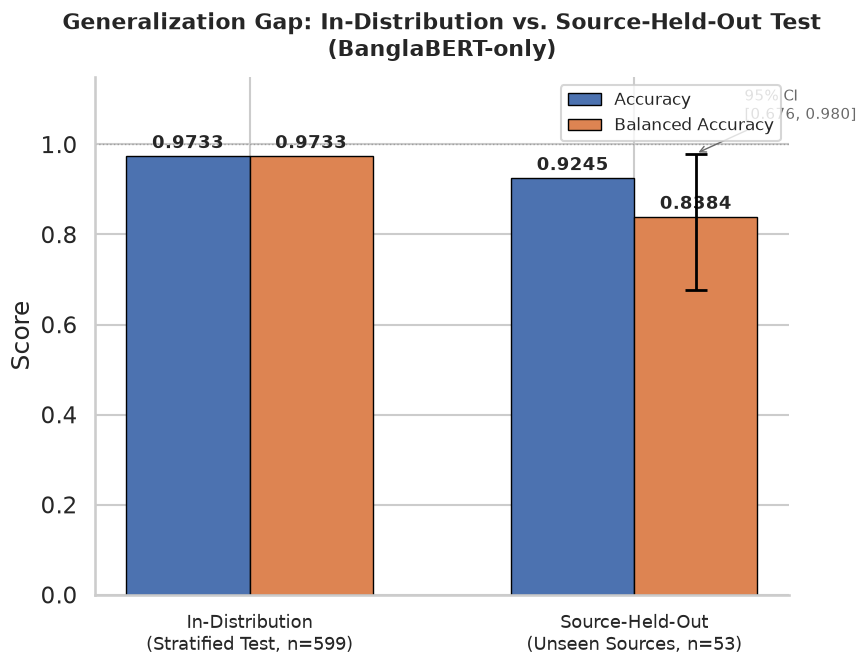

Saved: source_heldout_generalization.png


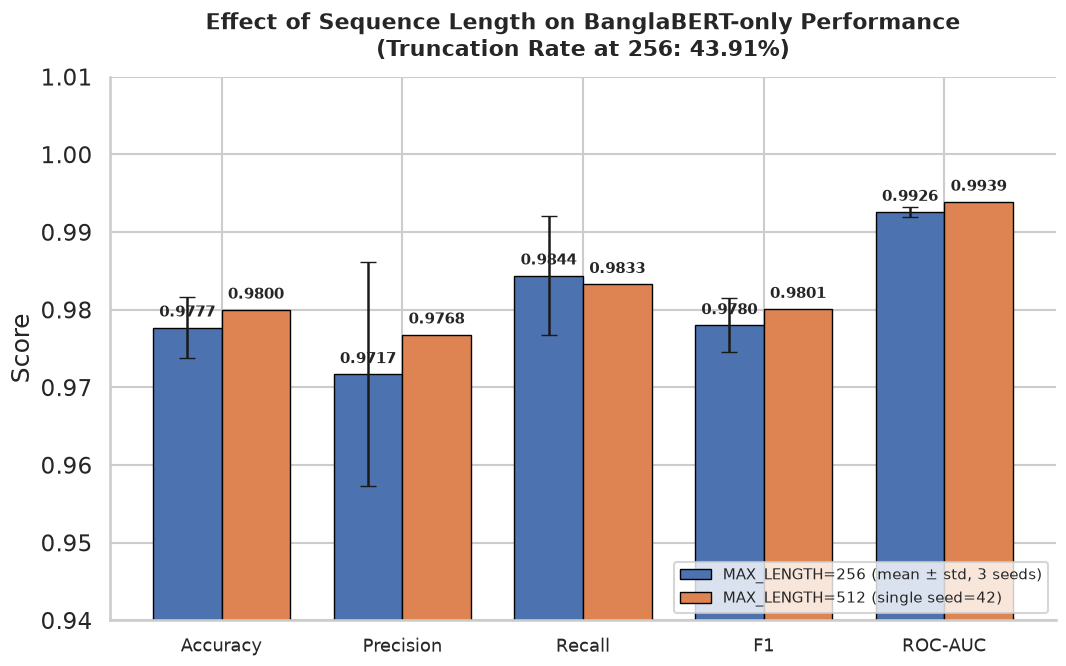

Saved: max_length_comparison.png


In [ ]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 20: Publication-Quality Figures — Source-Held-Out Gap 
#          & MAX_LENGTH Comparison (Seaborn + Matplotlib)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# ---------- Figure 1: Source-Held-Out Generalization Gap ----------

fig, ax = plt.subplots(figsize=(9, 7))

conditions = ["In-Distribution\n(Stratified Test, n=599)", "Source-Held-Out\n(Unseen Sources, n=53)"]
accuracy_vals = [0.9733, 0.9245]
balanced_acc_vals = [0.9733, 0.8384]
ci_lower, ci_upper = 0.6764, 0.9796

x = np.arange(len(conditions))
width = 0.32

bars1 = ax.bar(x - width/2, accuracy_vals, width, label="Accuracy",
               color="#4C72B0", edgecolor="black", linewidth=1)
bars2 = ax.bar(x + width/2, balanced_acc_vals, width, label="Balanced Accuracy",
               color="#DD8452", edgecolor="black", linewidth=1)

err_lower = balanced_acc_vals[1] - ci_lower
err_upper = ci_upper - balanced_acc_vals[1]
ax.errorbar(x[1] + width/2, balanced_acc_vals[1], yerr=[[err_lower], [err_upper]],
            fmt='none', ecolor='black', elinewidth=2, capsize=8, capthick=2, zorder=5)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.4f}", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 6), textcoords="offset points", ha='center',
                    fontsize=13, fontweight='bold')

ax.annotate("95% CI\n[0.676, 0.980]", xy=(x[1] + width/2, ci_upper),
            xytext=(35, 25), textcoords="offset points", fontsize=11,
            ha='left', color='dimgray',
            arrowprops=dict(arrowstyle="->", color='dimgray', lw=1))

ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Generalization Gap: In-Distribution vs. Source-Held-Out Test\n(BanglaBERT-only)",
              fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=13)
ax.legend(loc="upper right", frameon=True, fontsize=12)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.6)
sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "source_heldout_generalization.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("Saved: source_heldout_generalization.png")


# ---------- Figure 2: MAX_LENGTH 256 vs 512 Comparison ----------

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
len256_mean = [0.9777, 0.9717, 0.9844, 0.9780, 0.9926]
len256_std  = [0.0039, 0.0144, 0.0077, 0.0035, 0.0006]
len512_val  = [0.9800, 0.9768, 0.9833, 0.9801, 0.9939]

fig, ax = plt.subplots(figsize=(11, 7))
bar_width = 0.38
x = np.arange(len(metrics))

bars_256 = ax.bar(x - bar_width/2, len256_mean, bar_width, yerr=len256_std,
                   label="MAX_LENGTH=256 (mean ± std, 3 seeds)",
                   color="#4C72B0", edgecolor="black", linewidth=1,
                   capsize=6, error_kw={'elinewidth': 1.8})

bars_512 = ax.bar(x + bar_width/2, len512_val, bar_width,
                   label="MAX_LENGTH=512 (single seed=42)",
                   color="#DD8452", edgecolor="black", linewidth=1)

for bars, vals in [(bars_256, len256_mean), (bars_512, len512_val)]:
    for bar, val in zip(bars, vals):
        ax.annotate(f"{val:.4f}", xy=(bar.get_x() + bar.get_width()/2, val),
                    xytext=(0, 8), textcoords="offset points", ha='center',
                    fontsize=11, fontweight='bold')

ax.set_ylim(0.94, 1.01)
ax.set_ylabel("Score")
ax.set_title("Effect of Sequence Length on BanglaBERT-only Performance\n(Truncation Rate at 256: 43.91%)",
              fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=13)
ax.legend(loc="lower right", frameon=True, fontsize=11)
sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "max_length_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("Saved: max_length_comparison.png")

In [ ]:
# ============================================================
# Notebook: 05_ablation_interpretability.ipynb
# Cell 21: RE-SETUP (kernel restarted — reload everything from disk,
#          NO retraining, uses saved checkpoints + CSVs only)
# ============================================================

import os, re
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import cross_val_score
from tqdm.auto import tqdm

PROJECT_ROOT = "/mnt/g/banglafake-detection"
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "csebuetnlp/banglabert"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_df = pd.read_csv(os.path.join(PROCESSED_DIR, "train.csv"))
val_df   = pd.read_csv(os.path.join(PROCESSED_DIR, "validation.csv"))
test_df  = pd.read_csv(os.path.join(PROCESSED_DIR, "test.csv"))

class BanglaFakeNewsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.dataframe = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        text = str(self.dataframe.iloc[idx]["text"])
        label = int(self.dataframe.iloc[idx]["label"])
        encoding = self.tokenizer(text, truncation=True, padding='max_length',
                                   max_length=self.max_length, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

class BanglaBERTOnly(nn.Module):
    def __init__(self, model_name, num_classes=2, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        return self.classifier(self.dropout(cls_output))

class BanglaBERTWithAttention(nn.Module):
    def __init__(self, model_name, attention_dim=128, num_classes=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.attention_projection = nn.Linear(self.bert.config.hidden_size, attention_dim)
        self.attention_score = nn.Linear(attention_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        att_hidden = torch.tanh(self.attention_projection(x))
        att_logits = self.attention_score(att_hidden).squeeze(-1)
        att_logits = att_logits.masked_fill(attention_mask == 0, -1e9)
        att_weights = torch.softmax(att_logits, dim=1)
        attended = (x * att_weights.unsqueeze(-1)).sum(dim=1)
        return self.classifier(self.dropout(attended))

# ---- Reconstruct Source metadata (same as Cell 13) ----
real_raw = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "raw", "Bangla_Real_News_Dataset.csv"))
fake_raw = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "raw", "Bangla_Fake_News_Dataset.csv"))
raw_df = pd.concat([real_raw, fake_raw], ignore_index=True)

def clean_text_for_analysis(text):
    if pd.isna(text): return ""
    text = str(text).strip()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

raw_df["text"] = (raw_df["Headline"].apply(clean_text_for_analysis) + " " +
                   raw_df["Content"].apply(clean_text_for_analysis)).str.strip()
source_map = raw_df[["text", "Source"]].drop_duplicates(subset=["text"])

train_src = train_df.merge(source_map, on="text", how="left")
val_src   = val_df.merge(source_map, on="text", how="left")
test_src  = test_df.merge(source_map, on="text", how="left")
full_df = pd.concat([train_src, val_src, test_src], ignore_index=True)

# ---- Reconstruct EXACT same Fold-4 source-held-out split (deterministic, random_state=42) ----
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(sgkf.split(full_df, y=full_df["label"], groups=full_df["Source"]))
tr_idx, te_idx = splits[4]
group_train_df = full_df.iloc[tr_idx].reset_index(drop=True)
group_test_df  = full_df.iloc[te_idx].reset_index(drop=True)

sgkf_val = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
tr2_idx, val2_idx = next(sgkf_val.split(group_train_df, y=group_train_df["label"], groups=group_train_df["Source"]))
group_train_final = group_train_df.iloc[tr2_idx].reset_index(drop=True)
group_val_final   = group_train_df.iloc[val2_idx].reset_index(drop=True)

print("Re-setup complete. Shapes:", group_train_final.shape, group_test_df.shape)

Re-setup complete. Shapes: (2818, 4) (53, 4)


In [ ]:
# ============================================================
# Cell 22: Source-Identity-Only Probe (no text, no model needed)
# ============================================================

ohe = OneHotEncoder(handle_unknown='ignore')
X_train_src = ohe.fit_transform(group_train_final[["Source"]])
X_test_src = ohe.transform(group_test_df[["Source"]])

y_train = group_train_final["label"].values
y_test = group_test_df["label"].values

clf = LogisticRegression(max_iter=1000).fit(X_train_src, y_train)
preds = clf.predict(X_test_src)
print("Source-only balanced accuracy:", balanced_accuracy_score(y_test, preds))

Source-only balanced accuracy: 0.5


In [ ]:
# ============================================================
# Cell 23: CLS-Embedding -> Source-ID Probe
# (loads saved BanglaBERT-only checkpoint, NO retraining)
# ============================================================

probe_model = BanglaBERTOnly(MODEL_NAME).to(device)
probe_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "ablation_BanglaBERT-only.pt"), map_location=device))
probe_model.eval()

train_loader_full = DataLoader(BanglaFakeNewsDataset(train_src, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)

cls_embeddings = []
with torch.no_grad():
    for batch in tqdm(train_loader_full, desc="Extracting CLS embeddings"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        out = probe_model.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        cls_embeddings.append(out.cpu().numpy())
cls_embeddings = np.vstack(cls_embeddings)

le = LabelEncoder()
source_labels = le.fit_transform(train_src["Source"])

probe = LogisticRegression(max_iter=2000)
scores = cross_val_score(probe, cls_embeddings, source_labels, cv=5)
print("Source-ID probe accuracy from CLS embeddings:", scores.mean(), "+/-", scores.std())

del probe_model
torch.cuda.empty_cache()

Extracting CLS embeddings:   0%|          | 0/349 [00:00<?, ?it/s]

/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Source-ID probe accuracy from CLS embeddings: 0.9204301075268818 +/- 0.009723770585125828


In [ ]:
# ============================================================
# Cell 24: Attention Entropy Across Full Validation Set
# (loads saved BanglaBERT+Attention checkpoint, NO retraining)
# ============================================================

attn_model = BanglaBERTWithAttention(MODEL_NAME).to(device)
attn_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "ablation_BanglaBERT_Attention.pt"), map_location=device))
attn_model.eval()

val_loader = DataLoader(BanglaFakeNewsDataset(val_df, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)

def compute_attention_entropy(model, loader, device):
    model.eval()
    entropies = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Computing entropy"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            x = model.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
            att_hidden = torch.tanh(model.attention_projection(x))
            att_logits = model.attention_score(att_hidden).squeeze(-1)
            att_logits = att_logits.masked_fill(attention_mask == 0, -1e9)
            alpha = torch.softmax(att_logits, dim=1)

            n_valid = attention_mask.sum(dim=1).float()
            eps = 1e-12
            H = -(alpha * torch.log(alpha + eps) * attention_mask).sum(dim=1)
            H_max = torch.log(n_valid)
            H_norm = (H / H_max).cpu().numpy()
            entropies.extend(H_norm.tolist())
    return np.array(entropies)

ent = compute_attention_entropy(attn_model, val_loader, device)
print(f"Mean normalized entropy: {ent.mean():.4f} +/- {ent.std():.4f}")
print(f"Min: {ent.min():.4f}, Max: {ent.max():.4f}")

pd.DataFrame({"normalized_entropy": ent}).to_csv(os.path.join(REPORTS_DIR, "attention_entropy_full_val.csv"), index=False)

del attn_model
torch.cuda.empty_cache()

Computing entropy:   0%|          | 0/75 [00:00<?, ?it/s]

Mean normalized entropy: 0.9983 +/- 0.0035
Min: 0.9694, Max: 1.0000


In [ ]:
# ============================================================
# Cell 25: Save Category-wise Test Accuracy (paper-ready)
# Reuses Notebook 3 logic; NO retraining.
# ============================================================
import re as _re

def _clean(t):
    if pd.isna(t): return ""
    t = str(t).strip()
    t = _re.sub(r"<[^>]+>", " ", t)
    t = _re.sub(r"[\u200b\u200c\u200d\ufeff]", "", t)
    t = _re.sub(r"\s+", " ", t)
    return t.strip()

raw = pd.concat([
    pd.read_csv(os.path.join(PROJECT_ROOT, "data", "raw", "Bangla_Real_News_Dataset.csv")),
    pd.read_csv(os.path.join(PROJECT_ROOT, "data", "raw", "Bangla_Fake_News_Dataset.csv"))
], ignore_index=True)
raw["text"] = (raw["Headline"].apply(_clean) + " " + raw["Content"].apply(_clean)).str.strip()
cat_map = raw[["text", "Category"]].drop_duplicates(subset=["text"])

# Load saved test predictions (produced earlier)
preds_path = os.path.join(REPORTS_DIR, "test_predictions.csv")
preds_df = pd.read_csv(preds_path)

cat_df = test_df.merge(cat_map, on="text", how="left").merge(
    preds_df[["Global_ID", "actual", "predicted"]], on="Global_ID", how="left"
)
cat_df["Category"] = cat_df["Category"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
cat_df["correct"] = cat_df["actual"] == cat_df["predicted"]

cat_tbl = cat_df.groupby("Category").agg(Samples=("correct","size"), Correct=("correct","sum"))
cat_tbl["Errors"] = cat_tbl["Samples"] - cat_tbl["Correct"]
cat_tbl["Accuracy"] = (cat_tbl["Correct"] / cat_tbl["Samples"]).round(4)
cat_tbl = cat_tbl.sort_values("Accuracy", ascending=False)

cat_tbl.to_csv(os.path.join(REPORTS_DIR, "category_wise_accuracy.csv"))
display(cat_tbl)
print("Saved:", os.path.join(REPORTS_DIR, "category_wise_accuracy.csv"))

,Samples,Correct,Errors,Accuracy
Category,,,,
Crime,46,46,0,1.0000
Finance,22,22,0,1.0000
National,52,52,0,1.0000
Politics,111,110,1,0.9910
Miscellaneous,91,90,1,0.9890
International,88,86,2,0.9773
Sports,47,45,2,0.9574
Editorial,21,20,1,0.9524
Lifestyle,32,30,2,0.9375


Saved: /mnt/g/banglafake-detection/reports/category_wise_accuracy.csv


In [ ]:
# ============================================================
# Cell 26 (FIXED): Bootstrap CI on Fold-4 held-out accuracy
# Uses correct model: BanglaBERTOnly trained ON the held-out split
# ============================================================
from sklearn.utils import resample

fold_model = BanglaBERTOnly(MODEL_NAME).to(device)
state = torch.load(os.path.join(MODELS_DIR, "source_heldout_banglabert_only.pt"), map_location=device)
fold_model.load_state_dict(state)   # plain state_dict, no "model_state_dict" key
fold_model.eval()

group_test_loader = DataLoader(
    BanglaFakeNewsDataset(group_test_df, tokenizer, MAX_LENGTH),
    batch_size=8, shuffle=False, pin_memory=True
)

y_true, y_pred = [], []
with torch.no_grad():
    for batch in group_test_loader:
        ids = batch["input_ids"].to(device)
        am  = batch["attention_mask"].to(device)
        logits = fold_model(ids, am)
        y_pred.extend(torch.argmax(logits, dim=1).cpu().numpy())
        y_true.extend(batch["labels"].numpy())

y_true = np.array(y_true); y_pred = np.array(y_pred)
acc = (y_true == y_pred).mean()

rng = np.random.default_rng(42)
boot_accs = []
for _ in range(2000):
    idx = rng.integers(0, len(y_true), len(y_true))
    boot_accs.append((y_true[idx] == y_pred[idx]).mean())
boot_accs = np.array(boot_accs)
lo, hi = np.percentile(boot_accs, [2.5, 97.5])

print(f"Held-out (Fold-4) accuracy: {acc:.4f}")
print(f"95% bootstrap CI: [{lo:.4f}, {hi:.4f}]")

del fold_model
torch.cuda.empty_cache()

Held-out (Fold-4) accuracy: 0.9245
95% bootstrap CI: [0.8491, 0.9811]


In [ ]:
# ============================================================
# Cell 27: Per-class metrics on Fold-4 held-out
# Uses y_true/y_pred from Cell 26.
# ============================================================
from sklearn.metrics import classification_report

# Cell 27 — RE-RUN as-is, right after the fixed Cell 26, same session
rep = classification_report(
    y_true, y_pred, target_names=["Fake","Real"], digits=4, zero_division=0
)
print("Fold-4 held-out classification report:")
print(rep)
with open(os.path.join(REPORTS_DIR, "fold4_heldout_classification_report.txt"), "w", encoding="utf-8") as f:
    f.write(rep)
print("Saved:", os.path.join(REPORTS_DIR, "fold4_heldout_classification_report.txt"))

Fold-4 held-out classification report:
              precision    recall  f1-score   support

        Fake     0.8750    0.7000    0.7778        10
        Real     0.9333    0.9767    0.9545        43

    accuracy                         0.9245        53
   macro avg     0.9042    0.8384    0.8662        53
weighted avg     0.9223    0.9245    0.9212        53

Saved: /mnt/g/banglafake-detection/reports/fold4_heldout_classification_report.txt


In [ ]:
# ============================================================
# Cell 28: Truncation-stratified accuracy table (test set)
# ============================================================
test_preds = pd.read_csv(os.path.join(REPORTS_DIR, "test_predictions.csv"))
tok_lens = []
for t in test_df["text"]:
    tok_lens.append(len(tokenizer(str(t), add_special_tokens=True, truncation=False)["input_ids"]))
test_df_ = test_df.copy()
test_df_["token_length"] = tok_lens
test_df_["is_truncated"] = test_df_["token_length"] > MAX_LENGTH
test_df_ = test_df_.merge(test_preds[["Global_ID","actual","predicted"]], on="Global_ID", how="left")
test_df_["correct"] = test_df_["actual"] == test_df_["predicted"]

trunc_tbl = test_df_.groupby("is_truncated").agg(Samples=("correct","size"), Correct=("correct","sum"))
trunc_tbl["Errors"] = trunc_tbl["Samples"] - trunc_tbl["Correct"]
trunc_tbl["Accuracy"] = (trunc_tbl["Correct"] / trunc_tbl["Samples"]).round(4)
trunc_tbl.index = trunc_tbl.index.map({False:"Not Truncated", True:"Truncated"})

trunc_tbl.to_csv(os.path.join(REPORTS_DIR, "truncation_stratified_accuracy.csv"))
display(trunc_tbl)
print("Saved:", os.path.join(REPORTS_DIR, "truncation_stratified_accuracy.csv"))

,Samples,Correct,Errors,Accuracy
is_truncated,,,,
Not Truncated,336,331,5,0.9851
Truncated,263,252,11,0.9582


Saved: /mnt/g/banglafake-detection/reports/truncation_stratified_accuracy.csv


In [ ]:
# ============================================================
# Cell 29: Attention entropy per class (Fake vs Real)
# Reuses attention model; computes entropy separately per label.
# ============================================================
attn_model = BanglaBERTWithAttention(MODEL_NAME).to(device)
attn_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "ablation_BanglaBERT_Attention.pt"), map_location=device))
attn_model.eval()

val_loader = DataLoader(BanglaFakeNewsDataset(val_df, tokenizer, MAX_LENGTH),
                        batch_size=8, shuffle=False, pin_memory=True)

ent_fake, ent_real = [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Entropy per class"):
        ids = batch["input_ids"].to(device)
        am  = batch["attention_mask"].to(device)
        labs = batch["labels"].numpy()

        x = attn_model.bert(input_ids=ids, attention_mask=am).last_hidden_state
        h = torch.tanh(attn_model.attention_projection(x))
        logits = attn_model.attention_score(h).squeeze(-1)
        logits = logits.masked_fill(am == 0, -1e9)
        alpha = torch.softmax(logits, dim=1)

        n_valid = am.sum(dim=1).float()
        eps = 1e-12
        H = -(alpha * torch.log(alpha + eps) * am).sum(dim=1)
        H_norm = (H / torch.log(n_valid)).cpu().numpy()

        for hn, lb in zip(H_norm, labs):
            (ent_fake if lb == 0 else ent_real).append(hn)

ent_fake = np.array(ent_fake); ent_real = np.array(ent_real)
print(f"Fake (n={len(ent_fake)}): mean={ent_fake.mean():.4f}, std={ent_fake.std():.4f}")
print(f"Real (n={len(ent_real)}): mean={ent_real.mean():.4f}, std={ent_real.std():.4f}")

pd.DataFrame({
    "class": ["Fake"]*len(ent_fake) + ["Real"]*len(ent_real),
    "normalized_entropy": np.concatenate([ent_fake, ent_real])
}).to_csv(os.path.join(REPORTS_DIR, "attention_entropy_per_class.csv"), index=False)
print("Saved:", os.path.join(REPORTS_DIR, "attention_entropy_per_class.csv"))

del attn_model
torch.cuda.empty_cache()

Entropy per class:   0%|          | 0/75 [00:00<?, ?it/s]

Fake (n=298): mean=0.9986, std=0.0037
Real (n=300): mean=0.9981, std=0.0032
Saved: /mnt/g/banglafake-detection/reports/attention_entropy_per_class.csv


In [2]:
# ============================================================
# Cell 29c: RE-SETUP before Cell 30-36 (all-in-one)
# ============================================================
import os, re
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, roc_auc_score, balanced_accuracy_score)
from tqdm.auto import tqdm

PROJECT_ROOT = "/mnt/g/banglafake-detection"
MODELS_DIR  = os.path.join(PROJECT_ROOT, "models")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")
FIGURES_DIR = os.path.join(REPORTS_DIR, "figures")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
os.makedirs(FIGURES_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "csebuetnlp/banglabert"
MAX_LENGTH = 256
NUM_EPOCHS = 3

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_df = pd.read_csv(os.path.join(PROCESSED_DIR, "train.csv"))
val_df   = pd.read_csv(os.path.join(PROCESSED_DIR, "validation.csv"))
test_df  = pd.read_csv(os.path.join(PROCESSED_DIR, "test.csv"))

class BanglaFakeNewsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self): return len(self.dataframe)
    def __getitem__(self, idx):
        text = str(self.dataframe.iloc[idx]["text"])
        label = int(self.dataframe.iloc[idx]["label"])
        enc = self.tokenizer(text, truncation=True, padding='max_length',
                             max_length=self.max_length, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'labels': torch.tensor(label, dtype=torch.long)}

class BanglaBERTOnly(nn.Module):
    def __init__(self, model_name, num_classes=2, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
    def forward(self, input_ids, attention_mask):
        o = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(o.last_hidden_state[:, 0, :]))

class BanglaBERTWithCNN(nn.Module):
    def __init__(self, model_name, cnn_channels=256, kernel_size=3, num_classes=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.cnn = nn.Conv1d(self.bert.config.hidden_size, cnn_channels, kernel_size, padding=kernel_size//2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(cnn_channels, num_classes)
    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        x = x * attention_mask.unsqueeze(-1).float()
        x = torch.relu(self.cnn(x.permute(0,2,1)))
        return self.classifier(self.dropout(torch.mean(x, dim=2)))

class BanglaBERTWithAttention(nn.Module):
    def __init__(self, model_name, attention_dim=128, num_classes=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.attention_projection = nn.Linear(self.bert.config.hidden_size, attention_dim)
        self.attention_score = nn.Linear(attention_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        h = torch.tanh(self.attention_projection(x))
        s = self.attention_score(h).squeeze(-1).masked_fill(attention_mask==0, -1e9)
        w = torch.softmax(s, dim=1)
        return self.classifier(self.dropout((x*w.unsqueeze(-1)).sum(dim=1)))

class BanglaBERTFullModel(nn.Module):
    def __init__(self, model_name, cnn_channels=256, kernel_size=3, attention_dim=128, num_classes=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.cnn = nn.Conv1d(self.bert.config.hidden_size, cnn_channels, kernel_size, padding=kernel_size//2)
        self.attention_projection = nn.Linear(cnn_channels, attention_dim)
        self.attention_score = nn.Linear(attention_dim, 1)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(cnn_channels, num_classes))
    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        x = x * attention_mask.unsqueeze(-1).float()
        x = torch.relu(self.cnn(x.permute(0,2,1))).permute(0,2,1)
        h = torch.tanh(self.attention_projection(x))
        s = self.attention_score(h).squeeze(-1).masked_fill(attention_mask==0, -1e9)
        w = torch.softmax(s, dim=1)
        return self.classifier((x*w.unsqueeze(-1)).sum(dim=1))

import random
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_one_epoch(model, loader, optimizer, device):
    model.train(); loss_fn = nn.CrossEntropyLoss(); tot = 0
    for batch in tqdm(loader, desc="Train", leave=False):
        ids = batch['input_ids'].to(device); am = batch['attention_mask'].to(device)
        y = batch['labels'].to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(ids, am), y)
        loss.backward(); optimizer.step(); tot += loss.item()
    return tot / len(loader)

def eval_split(model, loader, device):
    model.eval(); preds, ys, probs = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Eval", leave=False):
            ids = batch['input_ids'].to(device); am = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)
            logits = model(ids, am)
            probs.extend(torch.softmax(logits, dim=1)[:,1].cpu().numpy())
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            ys.extend(y.cpu().numpy())
    return {"Accuracy": accuracy_score(ys, preds),
            "Precision": precision_score(ys, preds, zero_division=0),
            "Recall": recall_score(ys, preds, zero_division=0),
            "F1": f1_score(ys, preds, zero_division=0),
            "ROC-AUC": roc_auc_score(ys, probs)}

# Rebuild source metadata + folds
real_raw = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "raw", "Bangla_Real_News_Dataset.csv"))
fake_raw = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "raw", "Bangla_Fake_News_Dataset.csv"))
raw_df = pd.concat([real_raw, fake_raw], ignore_index=True)
def _clean(t):
    if pd.isna(t): return ""
    t = str(t).strip()
    t = re.sub(r"<[^>]+>", " ", t); t = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", t)
    t = re.sub(r"\s+", " ", t); return t.strip()
raw_df["text"] = (raw_df["Headline"].apply(_clean) + " " + raw_df["Content"].apply(_clean)).str.strip()
source_map = raw_df[["text", "Source"]].drop_duplicates(subset=["text"])

train_src = train_df.merge(source_map, on="text", how="left")
val_src   = val_df.merge(source_map, on="text", how="left")
test_src  = test_df.merge(source_map, on="text", how="left")
full_df   = pd.concat([train_src, val_src, test_src], ignore_index=True)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(sgkf.split(full_df, y=full_df["label"], groups=full_df["Source"]))

tr_idx, te_idx = splits[4]
group_train_df = full_df.iloc[tr_idx].reset_index(drop=True)
group_test_df  = full_df.iloc[te_idx].reset_index(drop=True)
sgkf_val = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
tr2_idx, val2_idx = next(sgkf_val.split(group_train_df, y=group_train_df["label"], groups=group_train_df["Source"]))
group_train_final = group_train_df.iloc[tr2_idx].reset_index(drop=True)
group_val_final   = group_train_df.iloc[val2_idx].reset_index(drop=True)

group_train_loader = DataLoader(BanglaFakeNewsDataset(group_train_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=True)
group_val_loader   = DataLoader(BanglaFakeNewsDataset(group_val_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)
group_test_loader  = DataLoader(BanglaFakeNewsDataset(group_test_df, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)

print("Re-setup complete:", train_df.shape, val_df.shape, test_df.shape)

Re-setup complete: (2790, 3) (598, 3) (599, 3)


In [3]:
# Cell 30: Classical Baseline (TF-IDF + LogReg/SVM)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(train_df["text"])
X_test_tfidf  = tfidf.transform(test_df["text"])
y_train_c, y_test_c = train_df["label"], test_df["label"]

lr_clf = LogisticRegression(max_iter=1000).fit(X_train_tfidf, y_train_c)
lr_preds = lr_clf.predict(X_test_tfidf)
lr_probs = lr_clf.predict_proba(X_test_tfidf)[:,1]

svm_clf = CalibratedClassifierCV(LinearSVC(max_iter=5000)).fit(X_train_tfidf, y_train_c)
svm_preds = svm_clf.predict(X_test_tfidf)

classical_results = pd.DataFrame([
    {"Model":"TF-IDF+LogReg","Accuracy":accuracy_score(y_test_c,lr_preds),
     "F1":f1_score(y_test_c,lr_preds),"ROC-AUC":roc_auc_score(y_test_c,lr_probs)},
    {"Model":"TF-IDF+SVM","Accuracy":accuracy_score(y_test_c,svm_preds),
     "F1":f1_score(y_test_c,svm_preds),"ROC-AUC":float("nan")},
])
display(classical_results)
classical_results.to_csv(os.path.join(REPORTS_DIR, "classical_baseline_results.csv"), index=False)
print("Saved: classical_baseline_results.csv")

,Model,Accuracy,F1,ROC-AUC
0,TF-IDF+LogReg,0.928214,0.929853,0.975853
1,TF-IDF+SVM,0.936561,0.937086,NaN


Saved: classical_baseline_results.csv


In [5]:
# Cell 31: ANOVA Effect Size (partial eta^2 + Cohen's d), reuses saved multi-seed CSV
msr = pd.read_csv(os.path.join(REPORTS_DIR, "multi_seed_raw_results.csv"))
anova_res = pd.read_csv(os.path.join(REPORTS_DIR, "anova_architecture_effect.csv"))

k, n = msr["Model"].nunique(), msr["Seed"].nunique()
eff_rows = []
for _, row in anova_res.iterrows():
    F = row["F_statistic"]
    df_effect, df_error = k-1, (k-1)*(n-1)
    partial_eta2 = (F*df_effect) / (F*df_effect + df_error)
    eff_rows.append({"Metric": row["Metric"], "F": F, "partial_eta2": partial_eta2})
effect_df = pd.DataFrame(eff_rows)
display(effect_df)

# Cohen's d: BanglaBERT-only vs Full model, per metric, across seeds
d_rows = []
for metric in ["Accuracy","F1"]:
    a = msr[msr["Model"]=="BanglaBERT-only"][metric].values
    b = msr[msr["Model"]=="BanglaBERT+CNN+Attention (Full)"][metric].values
    pooled_sd = np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2)/2)
    d = (a.mean()-b.mean())/pooled_sd if pooled_sd>0 else 0.0
    d_rows.append({"Metric":metric,"Cohens_d_baseline_vs_full":d})
d_df = pd.DataFrame(d_rows)
display(d_df)

effect_df.to_csv(os.path.join(REPORTS_DIR,"anova_effect_size.csv"), index=False)
d_df.to_csv(os.path.join(REPORTS_DIR,"cohens_d_baseline_vs_full.csv"), index=False)
print("Saved: anova_effect_size.csv, cohens_d_baseline_vs_full.csv")

,Metric,F,partial_eta2
0,Accuracy,0.041754,0.020450
1,F1,0.046410,0.022679


,Metric,Cohens_d_baseline_vs_full
0,Accuracy,0.127515
1,F1,0.176787


Saved: anova_effect_size.csv, cohens_d_baseline_vs_full.csv


In [6]:
# Cell 31b: Delete corrupted CNN checkpoint
import os
p = os.path.join(MODELS_DIR, "ablation_BanglaBERT_CNN.pt")
if os.path.exists(p):
    os.remove(p)
    print("Deleted:", p)
else:
    print("Not found:", p)

Deleted: /mnt/g/banglafake-detection/models/ablation_BanglaBERT_CNN.pt


In [7]:
# Cell 31c: Re-train ONLY BanglaBERT+CNN and save checkpoint
from torch.optim import AdamW
from torch.utils.data import DataLoader

train_loader_cnn = DataLoader(
    BanglaFakeNewsDataset(train_df, tokenizer, MAX_LENGTH),
    batch_size=8, shuffle=True, pin_memory=True
)
val_loader_cnn = DataLoader(
    BanglaFakeNewsDataset(val_df, tokenizer, MAX_LENGTH),
    batch_size=8, shuffle=False, pin_memory=True
)

set_seed(42)
cnn_model = BanglaBERTWithCNN(MODEL_NAME).to(device)
opt_cnn = AdamW(cnn_model.parameters(), lr=2e-5, weight_decay=0.01)
best_f1_cnn, best_state_cnn = -1, None

for epoch in range(NUM_EPOCHS):
    tl = train_one_epoch(cnn_model, train_loader_cnn, opt_cnn, device)
    vm = eval_split(cnn_model, val_loader_cnn, device)
    print(f"CNN Epoch {epoch+1}: loss={tl:.4f} val_f1={vm['F1']:.4f}")
    if vm["F1"] > best_f1_cnn:
        best_f1_cnn = vm["F1"]
        best_state_cnn = {k: v.cpu().clone() for k, v in cnn_model.state_dict().items()}

torch.save(best_state_cnn, os.path.join(MODELS_DIR, "ablation_BanglaBERT_CNN.pt"))
print("Saved ablation_BanglaBERT_CNN.pt, best_val_f1=", round(best_f1_cnn, 4))

del cnn_model, opt_cnn
torch.cuda.empty_cache()

Train:   0%|          | 0/349 [00:00<?, ?it/s]

Eval:   0%|          | 0/75 [00:00<?, ?it/s]

CNN Epoch 1: loss=0.2533 val_f1=0.9768


Train:   0%|          | 0/349 [00:00<?, ?it/s]

Eval:   0%|          | 0/75 [00:00<?, ?it/s]

CNN Epoch 2: loss=0.1033 val_f1=0.9851


Train:   0%|          | 0/349 [00:00<?, ?it/s]

Eval:   0%|          | 0/75 [00:00<?, ?it/s]

CNN Epoch 3: loss=0.0622 val_f1=0.9836
Saved ablation_BanglaBERT_CNN.pt, best_val_f1= 0.9851


In [8]:
# Cell 32: CNN Branch Channel Redundancy (analogue of attention entropy)
cnn_model = BanglaBERTWithCNN(MODEL_NAME).to(device)
cnn_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "ablation_BanglaBERT_CNN.pt"), map_location=device))
cnn_model.eval()

val_loader_cnn = DataLoader(BanglaFakeNewsDataset(val_df, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)

pooled_all = []
with torch.no_grad():
    for batch in tqdm(val_loader_cnn, desc="CNN pooled activations"):
        ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
        x = cnn_model.bert(input_ids=ids, attention_mask=am).last_hidden_state
        mask = am.unsqueeze(-1).float()
        x = (x*mask).permute(0,2,1)
        x = torch.relu(cnn_model.cnn(x))
        pooled = torch.mean(x, dim=2)  # (batch, 256 channels)
        pooled_all.append(pooled.cpu().numpy())
pooled_all = np.vstack(pooled_all)

corr = np.corrcoef(pooled_all.T)  # 256x256 channel correlation
iu = np.triu_indices_from(corr, k=1)
mean_abs_corr = np.abs(corr[iu]).mean()
frac_high_corr = (np.abs(corr[iu]) > 0.9).mean()

print(f"Mean |pairwise channel correlation|: {mean_abs_corr:.4f}")
print(f"Fraction of channel pairs with |corr|>0.9: {frac_high_corr:.4f}")

pd.DataFrame([{"mean_abs_channel_corr":mean_abs_corr,"frac_high_corr_pairs":frac_high_corr}]
).to_csv(os.path.join(REPORTS_DIR,"cnn_channel_redundancy.csv"), index=False)
print("Saved: cnn_channel_redundancy.csv")
del cnn_model; torch.cuda.empty_cache()

CNN pooled activations:   0%|          | 0/75 [00:00<?, ?it/s]

Mean |pairwise channel correlation|: 0.8191
Fraction of channel pairs with |corr|>0.9: 0.4274
Saved: cnn_channel_redundancy.csv


In [9]:
# Cell 33: Qualitative Error Analysis — Fold-4 Held-Out Misclassifications
fold_model = BanglaBERTOnly(MODEL_NAME).to(device)
fold_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "source_heldout_banglabert_only.pt"), map_location=device))
fold_model.eval()

gt_loader = DataLoader(BanglaFakeNewsDataset(group_test_df, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)
preds, probs = [], []
with torch.no_grad():
    for batch in gt_loader:
        ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
        logits = fold_model(ids, am)
        preds.extend(torch.argmax(logits,dim=1).cpu().numpy())
        probs.extend(torch.softmax(logits,dim=1)[:,1].cpu().numpy())

err_df = group_test_df.copy()
err_df["predicted"] = preds
err_df["pred_prob_real"] = probs
err_df["correct"] = err_df["label"] == err_df["predicted"]
err_df["text_snippet"] = err_df["text"].str.slice(0,150)

misclassified = err_df[~err_df["correct"]][["Global_ID","Source","label","predicted","pred_prob_real","text_snippet"]]
display(misclassified)
misclassified.to_csv(os.path.join(REPORTS_DIR,"fold4_misclassified_examples.csv"), index=False)
print(f"Saved: fold4_misclassified_examples.csv ({len(misclassified)} errors)")
del fold_model; torch.cuda.empty_cache()

,Global_ID,Source,label,predicted,pred_prob_real,text_snippet
22,3686,jachai.org,0,1,0.945728,পুলিশ কর্মকর্তার বাড়ি থেকে পুঁতে রাখা ১০ তরুণী...
35,870,India Today,1,0,0.106253,"চ্যাটজিপিটি দিয়ে লিখেছেন জব অ্যাপ্লিকেশন, তারপ..."
37,3682,jachai.org,0,1,0.983850,শেখ হাসিনা সরকারের সাফল্য বর্তমান সরকার ২০১৯ স...
47,3685,jachai.org,0,1,0.995165,বিসিবি না চাইলেও ‘বিদায়’ জানিয়ে দিয়েছে বাংলাদে...


Saved: fold4_misclassified_examples.csv (4 errors)


Fold-4 held-out ECE: 0.17808957426053174


,bin,n,acc,conf
0,0.0-0.1,7,1.000000,0.032471
1,0.1-0.2,1,0.000000,0.106253
2,0.9-1.0,45,0.933333,0.990218


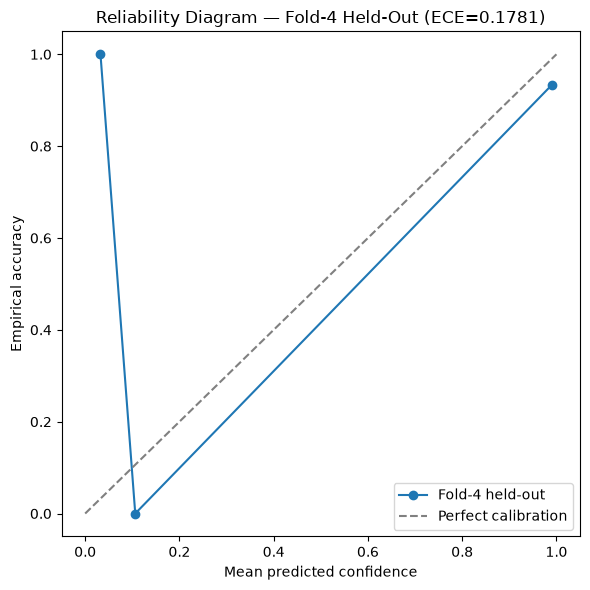

Saved: calibration_ece.csv, calibration_fold4_heldout.png


In [10]:
# Cell 34: Calibration Check (ECE) — Fold-4 Held-Out vs In-Distribution Test
def expected_calibration_error(y_true, probs, n_bins=10):
    bins = np.linspace(0,1,n_bins+1)
    ece, bin_rows = 0.0, []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (probs > lo) & (probs <= hi) if i>0 else (probs >= lo) & (probs <= hi)
        if mask.sum()==0: continue
        acc_bin = (y_true[mask]==(probs[mask]>0.5).astype(int)).mean()
        conf_bin = probs[mask].mean()
        w = mask.sum()/len(probs)
        ece += w*abs(acc_bin-conf_bin)
        bin_rows.append({"bin":f"{lo:.1f}-{hi:.1f}","n":mask.sum(),"acc":acc_bin,"conf":conf_bin})
    return ece, pd.DataFrame(bin_rows)

# reuse probs/labels from Cell 33 (fold-4) — recompute labels_all as array
y_true_fold4 = err_df["label"].values
probs_fold4 = err_df["pred_prob_real"].values
ece_fold4, bins_fold4 = expected_calibration_error(y_true_fold4, probs_fold4)
print("Fold-4 held-out ECE:", ece_fold4)
display(bins_fold4)

plt.figure(figsize=(6,6))
plt.plot(bins_fold4["conf"], bins_fold4["acc"], marker="o", label="Fold-4 held-out")
plt.plot([0,1],[0,1],"--",color="gray",label="Perfect calibration")
plt.xlabel("Mean predicted confidence"); plt.ylabel("Empirical accuracy")
plt.title(f"Reliability Diagram — Fold-4 Held-Out (ECE={ece_fold4:.4f})")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,"calibration_fold4_heldout.png"), dpi=300)
plt.show(); plt.close()

pd.DataFrame([{"split":"fold4_heldout","ECE":ece_fold4}]).to_csv(
    os.path.join(REPORTS_DIR,"calibration_ece.csv"), index=False)
print("Saved: calibration_ece.csv, calibration_fold4_heldout.png")

In [11]:
# Cell 35: Fold-3 Source-Held-Out Training (second usable fold)
tr_idx3, te_idx3 = splits[3]
g_train_df3 = full_df.iloc[tr_idx3].reset_index(drop=True)
g_test_df3  = full_df.iloc[te_idx3].reset_index(drop=True)

sgkf_val3 = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
tr2_idx3, val2_idx3 = next(sgkf_val3.split(g_train_df3, y=g_train_df3["label"], groups=g_train_df3["Source"]))
g_train_final3 = g_train_df3.iloc[tr2_idx3].reset_index(drop=True)
g_val_final3   = g_train_df3.iloc[val2_idx3].reset_index(drop=True)

g_train_loader3 = DataLoader(BanglaFakeNewsDataset(g_train_final3, tokenizer, MAX_LENGTH), batch_size=8, shuffle=True)
g_val_loader3   = DataLoader(BanglaFakeNewsDataset(g_val_final3, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)
g_test_loader3  = DataLoader(BanglaFakeNewsDataset(g_test_df3, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)

set_seed(42)
model3 = BanglaBERTOnly(MODEL_NAME).to(device)
opt3 = AdamW(model3.parameters(), lr=2e-5, weight_decay=0.01)
best_f1_3, best_state_3 = -1, None
for epoch in range(NUM_EPOCHS):
    tl = train_one_epoch(model3, g_train_loader3, opt3, device)
    vm = eval_split(model3, g_val_loader3, device)
    print(f"Fold3 Epoch {epoch+1}: loss={tl:.4f} val_f1={vm['F1']:.4f}")
    if vm["F1"] > best_f1_3:
        best_f1_3 = vm["F1"]; best_state_3 = {k:v.cpu().clone() for k,v in model3.state_dict().items()}
model3.load_state_dict(best_state_3)
torch.save(best_state_3, os.path.join(MODELS_DIR, "source_heldout_fold3_banglabert_only.pt"))

model3.eval()
preds3, labels3 = [], []
with torch.no_grad():
    for batch in g_test_loader3:
        ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
        logits = model3(ids, am)
        preds3.extend(torch.argmax(logits,dim=1).cpu().numpy())
        labels3.extend(batch["labels"].numpy())
preds3, labels3 = np.array(preds3), np.array(labels3)
acc3, bal3 = accuracy_score(labels3,preds3), balanced_accuracy_score(labels3,preds3)
print(f"Fold-3 held-out: acc={acc3:.4f} balanced_acc={bal3:.4f} n={len(labels3)}")

pd.DataFrame([
    {"Fold":4,"Balanced_Accuracy":0.8384,"N":53},
    {"Fold":3,"Balanced_Accuracy":bal3,"N":len(labels3)},
]).to_csv(os.path.join(REPORTS_DIR,"multi_fold_source_heldout.csv"), index=False)
print("Saved: multi_fold_source_heldout.csv")
del model3; torch.cuda.empty_cache()

Train:   0%|          | 0/187 [00:00<?, ?it/s]

Eval:   0%|          | 0/306 [00:00<?, ?it/s]

Fold3 Epoch 1: loss=0.0816 val_f1=0.7588


Train:   0%|          | 0/187 [00:00<?, ?it/s]

Eval:   0%|          | 0/306 [00:00<?, ?it/s]

Fold3 Epoch 2: loss=0.0230 val_f1=0.8699


Train:   0%|          | 0/187 [00:00<?, ?it/s]

Eval:   0%|          | 0/306 [00:00<?, ?it/s]

Fold3 Epoch 3: loss=0.0071 val_f1=0.7176
Fold-3 held-out: acc=0.9811 balanced_acc=0.9444 n=53
Saved: multi_fold_source_heldout.csv


In [12]:
# Cell 35b: Patch eval_split to guard single-class ROC-AUC (val split imbalance fix)
def eval_split(model, loader, device):
    model.eval(); preds, ys, probs = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Eval", leave=False):
            ids = batch['input_ids'].to(device); am = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)
            logits = model(ids, am)
            probs.extend(torch.softmax(logits, dim=1)[:,1].cpu().numpy())
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            ys.extend(y.cpu().numpy())
    roc = roc_auc_score(ys, probs) if len(set(ys)) > 1 else float("nan")
    return {"Accuracy": accuracy_score(ys, preds),
            "Precision": precision_score(ys, preds, zero_division=0),
            "Recall": recall_score(ys, preds, zero_division=0),
            "F1": f1_score(ys, preds, zero_division=0),
            "ROC-AUC": roc}

print("group_val_final label distribution:", group_val_final["label"].value_counts().to_dict())

group_val_final label distribution: {0: 1116}


In [13]:
# Cell 35c: Fix — pick a val fold that actually has both classes
sgkf_val = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
found = False
for tr2_idx, val2_idx in sgkf_val.split(group_train_df, y=group_train_df["label"], groups=group_train_df["Source"]):
    val_labels = group_train_df.iloc[val2_idx]["label"]
    if val_labels.nunique() == 2:
        found = True
        break

if not found:
    raise RuntimeError("No 10-fold split has both classes in val — need a different val strategy (e.g. smaller n_splits).")

group_train_final = group_train_df.iloc[tr2_idx].reset_index(drop=True)
group_val_final   = group_train_df.iloc[val2_idx].reset_index(drop=True)

print("New group_val_final label distribution:", group_val_final["label"].value_counts().to_dict())

# rebuild loaders that depend on these
group_train_loader = DataLoader(BanglaFakeNewsDataset(group_train_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=True)
group_val_loader   = DataLoader(BanglaFakeNewsDataset(group_val_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)

New group_val_final label distribution: {1: 25, 0: 1}


In [14]:
# Cell 35d: Fix — pick the val fold that maximizes minority-class count
best_min_count, best_split = -1, None

for n_splits_try in [5, 10]:
    sgkf_val = StratifiedGroupKFold(n_splits=n_splits_try, shuffle=True, random_state=42)
    for tr2_idx, val2_idx in sgkf_val.split(group_train_df, y=group_train_df["label"], groups=group_train_df["Source"]):
        val_labels = group_train_df.iloc[val2_idx]["label"]
        counts = val_labels.value_counts()
        min_count = counts.min() if len(counts) == 2 else 0
        if min_count > best_min_count:
            best_min_count = min_count
            best_split = (tr2_idx, val2_idx, n_splits_try)

tr2_idx, val2_idx, chosen_n = best_split
group_train_final = group_train_df.iloc[tr2_idx].reset_index(drop=True)
group_val_final   = group_train_df.iloc[val2_idx].reset_index(drop=True)

print("Chosen n_splits:", chosen_n, "| min class count in val:", best_min_count)
print("New group_val_final label distribution:", group_val_final["label"].value_counts().to_dict())

group_train_loader = DataLoader(BanglaFakeNewsDataset(group_train_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=True)
group_val_loader   = DataLoader(BanglaFakeNewsDataset(group_val_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)

Chosen n_splits: 5 | min class count in val: 554
New group_val_final label distribution: {1: 1889, 0: 554}


In [15]:
# Cell 36: Multi-Seed Source-Held-Out (Fold 4, seeds 42/123/2024)
heldout_seed_results = []
for seed in [42,123,2024]:
    set_seed(seed)
    m = BanglaBERTOnly(MODEL_NAME).to(device)
    opt = AdamW(m.parameters(), lr=2e-5, weight_decay=0.01)
    best_f1_s, best_state_s = -1, None
    for epoch in range(NUM_EPOCHS):
        train_one_epoch(m, group_train_loader, opt, device)
        vm = eval_split(m, group_val_loader, device)
        if vm["F1"] > best_f1_s:
            best_f1_s = vm["F1"]; best_state_s = {k:v.cpu().clone() for k,v in m.state_dict().items()}
    m.load_state_dict(best_state_s); m.eval()

    p_s, l_s = [], []
    with torch.no_grad():
        for batch in group_test_loader:
            ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
            logits = m(ids, am)
            p_s.extend(torch.argmax(logits,dim=1).cpu().numpy())
            l_s.extend(batch["labels"].numpy())
    p_s, l_s = np.array(p_s), np.array(l_s)
    bal_s = balanced_accuracy_score(l_s, p_s)
    heldout_seed_results.append({"Seed":seed,"Balanced_Accuracy":bal_s,"Accuracy":accuracy_score(l_s,p_s)})
    print(f"Seed {seed}: balanced_acc={bal_s:.4f}")
    del m; torch.cuda.empty_cache()

hs_df = pd.DataFrame(heldout_seed_results)
display(hs_df)
print(f"Mean balanced acc: {hs_df['Balanced_Accuracy'].mean():.4f} ± {hs_df['Balanced_Accuracy'].std():.4f}")
hs_df.to_csv(os.path.join(REPORTS_DIR,"fold4_multiseed_heldout.csv"), index=False)
print("Saved: fold4_multiseed_heldout.csv")

Train:   0%|          | 0/187 [00:00<?, ?it/s]

Eval:   0%|          | 0/306 [00:00<?, ?it/s]

Train:   0%|          | 0/187 [00:00<?, ?it/s]

Eval:   0%|          | 0/306 [00:00<?, ?it/s]

Train:   0%|          | 0/187 [00:00<?, ?it/s]

...

Train:   0%|          | 0/187 [00:00<?, ?it/s]

Eval:   0%|          | 0/306 [00:00<?, ?it/s]

Seed 2024: balanced_acc=0.8023


,Seed,Balanced_Accuracy,Accuracy
0,42,0.888372,0.943396
1,123,0.845349,0.811321
2,2024,0.802326,0.679245


Mean balanced acc: 0.8453 ± 0.0430
Saved: fold4_multiseed_heldout.csv


In [1]:
# Cell 37: FULL RE-SETUP v2 (run this first after any kernel restart)
import os, re, random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, roc_auc_score, balanced_accuracy_score)
from tqdm.auto import tqdm

PROJECT_ROOT = "/mnt/g/banglafake-detection"
MODELS_DIR  = os.path.join(PROJECT_ROOT, "models")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")
FIGURES_DIR = os.path.join(REPORTS_DIR, "figures")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
os.makedirs(FIGURES_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "csebuetnlp/banglabert"
MAX_LENGTH = 256
NUM_EPOCHS = 3

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_df = pd.read_csv(os.path.join(PROCESSED_DIR, "train.csv"))
val_df   = pd.read_csv(os.path.join(PROCESSED_DIR, "validation.csv"))
test_df  = pd.read_csv(os.path.join(PROCESSED_DIR, "test.csv"))

class BanglaFakeNewsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer; self.max_length = max_length
    def __len__(self): return len(self.dataframe)
    def __getitem__(self, idx):
        text = str(self.dataframe.iloc[idx]["text"])
        label = int(self.dataframe.iloc[idx]["label"])
        enc = self.tokenizer(text, truncation=True, padding='max_length',
                             max_length=self.max_length, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'labels': torch.tensor(label, dtype=torch.long)}

class BanglaBERTOnly(nn.Module):
    def __init__(self, model_name, num_classes=2, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
    def forward(self, input_ids, attention_mask):
        o = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(o.last_hidden_state[:, 0, :]))

class BanglaBERTWithCNN(nn.Module):
    def __init__(self, model_name, cnn_channels=256, kernel_size=3, num_classes=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.cnn = nn.Conv1d(self.bert.config.hidden_size, cnn_channels, kernel_size, padding=kernel_size//2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(cnn_channels, num_classes)
    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        x = x * attention_mask.unsqueeze(-1).float()
        x = torch.relu(self.cnn(x.permute(0,2,1)))
        return self.classifier(self.dropout(torch.mean(x, dim=2)))

class BanglaBERTWithAttention(nn.Module):
    def __init__(self, model_name, attention_dim=128, num_classes=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.attention_projection = nn.Linear(self.bert.config.hidden_size, attention_dim)
        self.attention_score = nn.Linear(attention_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        h = torch.tanh(self.attention_projection(x))
        s = self.attention_score(h).squeeze(-1).masked_fill(attention_mask==0, -1e9)
        w = torch.softmax(s, dim=1)
        return self.classifier(self.dropout((x*w.unsqueeze(-1)).sum(dim=1)))

class BanglaBERTFullModel(nn.Module):
    def __init__(self, model_name, cnn_channels=256, kernel_size=3, attention_dim=128, num_classes=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.cnn = nn.Conv1d(self.bert.config.hidden_size, cnn_channels, kernel_size, padding=kernel_size//2)
        self.attention_projection = nn.Linear(cnn_channels, attention_dim)
        self.attention_score = nn.Linear(attention_dim, 1)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(cnn_channels, num_classes))
    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        x = x * attention_mask.unsqueeze(-1).float()
        x = torch.relu(self.cnn(x.permute(0,2,1))).permute(0,2,1)
        h = torch.tanh(self.attention_projection(x))
        s = self.attention_score(h).squeeze(-1).masked_fill(attention_mask==0, -1e9)
        w = torch.softmax(s, dim=1)
        return self.classifier((x*w.unsqueeze(-1)).sum(dim=1))

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_one_epoch(model, loader, optimizer, device):
    model.train(); loss_fn = nn.CrossEntropyLoss(); tot = 0
    for batch in tqdm(loader, desc="Train", leave=False):
        ids = batch['input_ids'].to(device); am = batch['attention_mask'].to(device)
        y = batch['labels'].to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(ids, am), y)
        loss.backward(); optimizer.step(); tot += loss.item()
    return tot / len(loader)

def eval_split(model, loader, device):
    model.eval(); preds, ys, probs = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Eval", leave=False):
            ids = batch['input_ids'].to(device); am = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)
            logits = model(ids, am)
            probs.extend(torch.softmax(logits, dim=1)[:,1].cpu().numpy())
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            ys.extend(y.cpu().numpy())
    roc = roc_auc_score(ys, probs) if len(set(ys)) > 1 else float("nan")
    return {"Accuracy": accuracy_score(ys, preds),
            "Precision": precision_score(ys, preds, zero_division=0),
            "Recall": recall_score(ys, preds, zero_division=0),
            "F1": f1_score(ys, preds, zero_division=0),
            "ROC-AUC": roc}

# Rebuild source metadata + fold-4 split
real_raw = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "raw", "Bangla_Real_News_Dataset.csv"))
fake_raw = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "raw", "Bangla_Fake_News_Dataset.csv"))
raw_df = pd.concat([real_raw, fake_raw], ignore_index=True)
def _clean(t):
    if pd.isna(t): return ""
    t = str(t).strip()
    t = re.sub(r"<[^>]+>", " ", t); t = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", t)
    t = re.sub(r"\s+", " ", t); return t.strip()
raw_df["text"] = (raw_df["Headline"].apply(_clean) + " " + raw_df["Content"].apply(_clean)).str.strip()
source_map = raw_df[["text", "Source"]].drop_duplicates(subset=["text"])

train_src = train_df.merge(source_map, on="text", how="left")
val_src   = val_df.merge(source_map, on="text", how="left")
test_src  = test_df.merge(source_map, on="text", how="left")
full_df   = pd.concat([train_src, val_src, test_src], ignore_index=True)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(sgkf.split(full_df, y=full_df["label"], groups=full_df["Source"]))

tr_idx, te_idx = splits[4]
group_train_df = full_df.iloc[tr_idx].reset_index(drop=True)
group_test_df  = full_df.iloc[te_idx].reset_index(drop=True)

# FIXED val split (pick fold maximizing minority-class count, from Cell 35d)
best_min_count, best_split = -1, None
for n_splits_try in [5, 10]:
    sgkf_val = StratifiedGroupKFold(n_splits=n_splits_try, shuffle=True, random_state=42)
    for t_idx, v_idx in sgkf_val.split(group_train_df, y=group_train_df["label"], groups=group_train_df["Source"]):
        vl = group_train_df.iloc[v_idx]["label"]
        c = vl.value_counts()
        mc = c.min() if len(c) == 2 else 0
        if mc > best_min_count:
            best_min_count = mc; best_split = (t_idx, v_idx)
tr2_idx, val2_idx = best_split
group_train_final = group_train_df.iloc[tr2_idx].reset_index(drop=True)
group_val_final   = group_train_df.iloc[val2_idx].reset_index(drop=True)

group_train_loader = DataLoader(BanglaFakeNewsDataset(group_train_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=True)
group_val_loader   = DataLoader(BanglaFakeNewsDataset(group_val_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)
group_test_loader  = DataLoader(BanglaFakeNewsDataset(group_test_df, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)

print("Re-setup v2 complete.")
print("group_val_final labels:", group_val_final["label"].value_counts().to_dict())
print("group_test_df labels:", group_test_df["label"].value_counts().to_dict())

Re-setup v2 complete.
group_val_final labels: {1: 1889, 0: 554}
group_test_df labels: {1: 43, 0: 10}


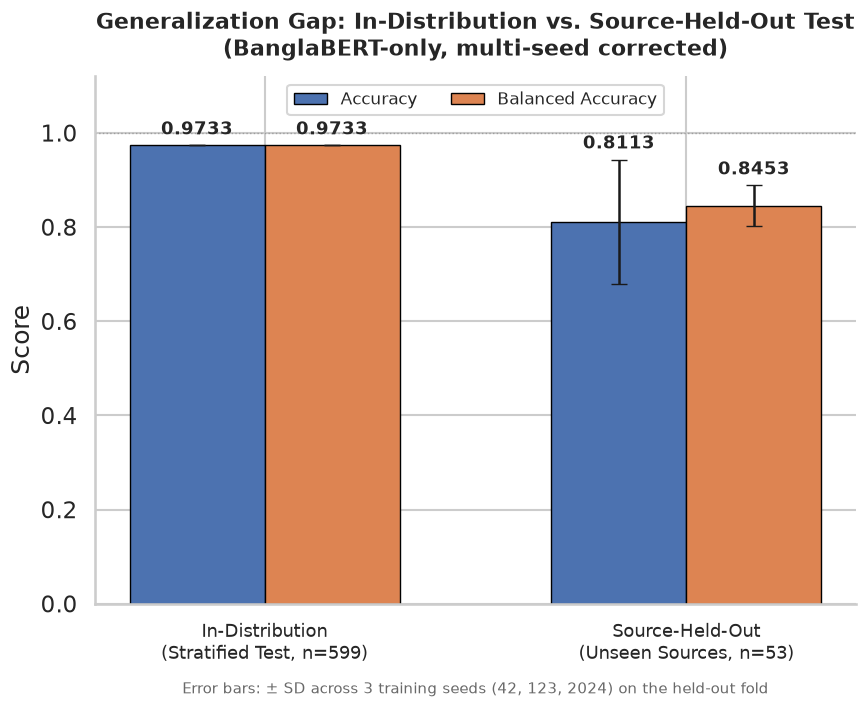

Saved (overwritten): source_heldout_generalization.png


In [3]:
# Cell 38: Regenerate Figure — Source-Held-Out Gap (multi-seed corrected, fixed layout)
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    FIGURES_DIR
except NameError:
    PROJECT_ROOT = "/mnt/g/banglafake-detection"
    REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")
    FIGURES_DIR = os.path.join(REPORTS_DIR, "figures")
    os.makedirs(FIGURES_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")

conditions = ["In-Distribution\n(Stratified Test, n=599)", "Source-Held-Out\n(Unseen Sources, n=53)"]
accuracy_vals = [0.9733, 0.8113]
balanced_acc_vals = [0.9733, 0.8453]
accuracy_sd = [0.0, 0.1321]
balanced_sd = [0.0, 0.0430]

fig, ax = plt.subplots(figsize=(9, 7.5))
x = np.arange(len(conditions))
width = 0.32

bars1 = ax.bar(x - width/2, accuracy_vals, width, yerr=accuracy_sd, capsize=6,
               label="Accuracy", color="#4C72B0", edgecolor="black", linewidth=1,
               error_kw={'elinewidth': 1.8, 'zorder': 5})
bars2 = ax.bar(x + width/2, balanced_acc_vals, width, yerr=balanced_sd, capsize=6,
               label="Balanced Accuracy", color="#DD8452", edgecolor="black", linewidth=1,
               error_kw={'elinewidth': 1.8, 'zorder': 5})

for bars, sds in [(bars1, accuracy_sd), (bars2, balanced_sd)]:
    for bar, sd in zip(bars, sds):
        height = bar.get_height()
        ax.annotate(f"{height:.4f}", xy=(bar.get_x() + bar.get_width()/2, height + sd),
                    xytext=(0, 8), textcoords="offset points", ha='center',
                    fontsize=13, fontweight='bold')

ax.text(0.5, -0.17, "Error bars: ± SD across 3 training seeds (42, 123, 2024) on the held-out fold",
        transform=ax.transAxes, ha='center', fontsize=11, color='dimgray')

ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Generalization Gap: In-Distribution vs. Source-Held-Out Test\n(BanglaBERT-only, multi-seed corrected)",
              fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=13)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=True, fontsize=12)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.6)
sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "source_heldout_generalization.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("Saved (overwritten): source_heldout_generalization.png")

In [4]:
import transformers
print("transformers version:", transformers.__version__)
print("tokenizer class:", type(tokenizer).__name__)
print("vocab size:", tokenizer.vocab_size)
print("CLS/SEP/PAD ids:", tokenizer.cls_token_id, tokenizer.sep_token_id, tokenizer.pad_token_id)
print("is_fast:", tokenizer.is_fast)

transformers version: 4.41.0
tokenizer class: ElectraTokenizerFast
vocab size: 32000
CLS/SEP/PAD ids: 2 3 0
is_fast: True


In [5]:
# Cell 39: Domain-Adversarial Training (Gradient Reversal) — Mitigation for Source-Entanglement
import torch.autograd as autograd

class GradientReversalFn(autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None

class GradientReversalLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.lambd = 0.0
    def forward(self, x):
        return GradientReversalFn.apply(x, self.lambd)

class BanglaBERTAdversarial(nn.Module):
    def __init__(self, model_name, num_sources, num_classes=2, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
        self.grl = GradientReversalLayer()
        self.source_classifier = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_sources)
        )
    def forward(self, input_ids, attention_mask):
        cls = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        class_logits = self.classifier(self.dropout(cls))
        source_logits = self.source_classifier(self.grl(cls))
        return class_logits, source_logits

# Source label encoding (only training-set sources; held-out sources are unseen by design)
from sklearn.preprocessing import LabelEncoder
source_le = LabelEncoder()
group_train_final["source_id"] = source_le.fit_transform(group_train_final["Source"])
num_train_sources = len(source_le.classes_)
print(f"Training sources: {num_train_sources}")

class AdvDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer; self.max_length = max_length
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tokenizer(str(row["text"]), truncation=True, padding='max_length',
                             max_length=self.max_length, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'labels': torch.tensor(int(row['label']), dtype=torch.long),
                'source_id': torch.tensor(int(row['source_id']), dtype=torch.long)}

adv_train_loader = DataLoader(AdvDataset(group_train_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=True)

def train_adversarial(model, loader, optimizer, device, epoch, total_epochs, source_loss_weight=1.0):
    model.train()
    class_loss_fn = nn.CrossEntropyLoss()
    source_loss_fn = nn.CrossEntropyLoss()
    total_loss = 0
    n_batches = len(loader)
    for i, batch in enumerate(tqdm(loader, desc=f"AdvTrain E{epoch}", leave=False)):
        ids = batch['input_ids'].to(device); am = batch['attention_mask'].to(device)
        y = batch['labels'].to(device); src = batch['source_id'].to(device)

        # DANN lambda schedule: ramps 0 -> 1 over training
        p = (epoch * n_batches + i) / (total_epochs * n_batches)
        lambd = 2.0 / (1.0 + np.exp(-10 * p)) - 1.0
        model.grl.lambd = lambd

        optimizer.zero_grad()
        class_logits, source_logits = model(ids, am)
        loss = class_loss_fn(class_logits, y) + source_loss_weight * source_loss_fn(source_logits, src)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

adv_results = []
for seed in [42, 123, 2024]:
    set_seed(seed)
    adv_model = BanglaBERTAdversarial(MODEL_NAME, num_train_sources).to(device)
    opt = AdamW(adv_model.parameters(), lr=2e-5, weight_decay=0.01)
    for epoch in range(NUM_EPOCHS):
        tl = train_adversarial(adv_model, adv_train_loader, opt, device, epoch, NUM_EPOCHS)
        print(f"Seed {seed} Epoch {epoch+1}: loss={tl:.4f}")

    adv_model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in group_test_loader:
            ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
            logits, _ = adv_model(ids, am)
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            labels.extend(batch["labels"].numpy())
    preds, labels = np.array(preds), np.array(labels)
    bal_acc = balanced_accuracy_score(labels, preds)
    acc = accuracy_score(labels, preds)
    adv_results.append({"Seed": seed, "Balanced_Accuracy": bal_acc, "Accuracy": acc})
    print(f"Seed {seed} [ADVERSARIAL] held-out balanced_acc={bal_acc:.4f}")
    if seed == 42:
        torch.save(adv_model.state_dict(), os.path.join(MODELS_DIR, "adversarial_banglabert_seed42.pt"))
    del adv_model; torch.cuda.empty_cache()

adv_df = pd.DataFrame(adv_results)
display(adv_df)
print(f"Adversarial mean balanced acc: {adv_df['Balanced_Accuracy'].mean():.4f} ± {adv_df['Balanced_Accuracy'].std():.4f}")
print(f"Baseline (non-adversarial) was: 0.8453 ± 0.0430")
adv_df.to_csv(os.path.join(REPORTS_DIR, "adversarial_mitigation_results.csv"), index=False)
print("Saved: adversarial_mitigation_results.csv")

Training sources: 24


AdvTrain E0:   0%|          | 0/187 [00:00<?, ?it/s]

Seed 42 Epoch 1: loss=4.0961


AdvTrain E1:   0%|          | 0/187 [00:00<?, ?it/s]

Seed 42 Epoch 2: loss=3.6146


...

Seed 2024 Epoch 2: loss=3.4856


AdvTrain E2:   0%|          | 0/187 [00:00<?, ?it/s]

Seed 2024 Epoch 3: loss=3.5447
Seed 2024 [ADVERSARIAL] held-out balanced_acc=0.8023


,Seed,Balanced_Accuracy,Accuracy
0,42,0.755814,0.603774
1,123,0.720930,0.547170
2,2024,0.802326,0.679245


Adversarial mean balanced acc: 0.7597 ± 0.0408
Baseline (non-adversarial) was: 0.8453 ± 0.0430
Saved: adversarial_mitigation_results.csv


In [6]:
# Cell 40: Re-run Source-Identity Probe on Adversarially-Trained Embeddings
adv_model_check = BanglaBERTAdversarial(MODEL_NAME, num_train_sources).to(device)
adv_model_check.load_state_dict(torch.load(os.path.join(MODELS_DIR, "adversarial_banglabert_seed42.pt"), map_location=device))
adv_model_check.eval()

val_probe_loader = DataLoader(AdvDataset(group_train_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)
embeddings, source_labels = [], []
with torch.no_grad():
    for batch in tqdm(val_probe_loader, desc="Extracting adversarial embeddings"):
        ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
        cls = adv_model_check.bert(input_ids=ids, attention_mask=am).last_hidden_state[:, 0, :]
        embeddings.append(cls.cpu().numpy())
        source_labels.extend(batch["source_id"].numpy())
embeddings = np.vstack(embeddings)
source_labels = np.array(source_labels)

from sklearn.model_selection import cross_val_score
probe_clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(probe_clf, embeddings, source_labels, cv=5)
print(f"Source-identity probe on ADVERSARIAL embeddings: {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Chance level: {1/num_train_sources:.4f}")
print(f"Original (non-adversarial) probe was: 0.9204 ± 0.0097")

pd.DataFrame([{"probe_acc_adversarial": scores.mean(), "probe_acc_std": scores.std(),
               "probe_acc_baseline": 0.9204, "chance_level": 1/num_train_sources}]
).to_csv(os.path.join(REPORTS_DIR, "adversarial_probe_check.csv"), index=False)
print("Saved: adversarial_probe_check.csv")
del adv_model_check; torch.cuda.empty_cache()

Extracting adversarial embeddings:   0%|          | 0/187 [00:00<?, ?it/s]

/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Source-identity probe on ADVERSARIAL embeddings: 0.9302 ± 0.0088
Chance level: 0.0417
Original (non-adversarial) probe was: 0.9204 ± 0.0097
Saved: adversarial_probe_check.csv


In [7]:
# Cell 41: Source-Balanced/Group-Weighted Sampling Mitigation
from torch.utils.data import WeightedRandomSampler

# Weight each sample inversely to its source's frequency, so every source
# contributes roughly equally to each training batch regardless of size.
source_counts = group_train_final["Source"].value_counts()
sample_weights = group_train_final["Source"].map(lambda s: 1.0 / source_counts[s]).values
sample_weights = torch.DoubleTensor(sample_weights)

print("Source count range:", source_counts.min(), "-", source_counts.max())
print("Sample weight range:", sample_weights.min().item(), "-", sample_weights.max().item())

balanced_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
balanced_train_loader = DataLoader(
    BanglaFakeNewsDataset(group_train_final, tokenizer, MAX_LENGTH),
    batch_size=8, sampler=balanced_sampler
)

balanced_results = []
for seed in [42, 123, 2024]:
    set_seed(seed)
    bal_model = BanglaBERTOnly(MODEL_NAME).to(device)
    opt = AdamW(bal_model.parameters(), lr=2e-5, weight_decay=0.01)
    best_f1_b, best_state_b = -1, None
    for epoch in range(NUM_EPOCHS):
        tl = train_one_epoch(bal_model, balanced_train_loader, opt, device)
        vm = eval_split(bal_model, group_val_loader, device)
        print(f"Seed {seed} Epoch {epoch+1}: loss={tl:.4f} val_f1={vm['F1']:.4f}")
        if vm["F1"] > best_f1_b:
            best_f1_b = vm["F1"]
            best_state_b = {k: v.cpu().clone() for k, v in bal_model.state_dict().items()}
    bal_model.load_state_dict(best_state_b)
    bal_model.eval()

    preds, labels = [], []
    with torch.no_grad():
        for batch in group_test_loader:
            ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
            logits = bal_model(ids, am)
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            labels.extend(batch["labels"].numpy())
    preds, labels = np.array(preds), np.array(labels)
    bal_acc = balanced_accuracy_score(labels, preds)
    acc = accuracy_score(labels, preds)
    balanced_results.append({"Seed": seed, "Balanced_Accuracy": bal_acc, "Accuracy": acc})
    print(f"Seed {seed} [SOURCE-BALANCED] held-out balanced_acc={bal_acc:.4f}")
    if seed == 42:
        torch.save(best_state_b, os.path.join(MODELS_DIR, "source_balanced_banglabert_seed42.pt"))
    del bal_model; torch.cuda.empty_cache()

balanced_df = pd.DataFrame(balanced_results)
display(balanced_df)
print(f"Source-balanced mean: {balanced_df['Balanced_Accuracy'].mean():.4f} ± {balanced_df['Balanced_Accuracy'].std():.4f}")
print(f"Baseline (unweighted) was:    0.8453 ± 0.0430")
print(f"Adversarial (DANN) was:       0.7597 ± 0.0408")
balanced_df.to_csv(os.path.join(REPORTS_DIR, "source_balanced_mitigation_results.csv"), index=False)
print("Saved: source_balanced_mitigation_results.csv")

/tmp/ipykernel_1107/3948581768.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  sample_weights = torch.DoubleTensor(sample_weights)
'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 6589d165-6ad3-4a78-afb5-6d0e97294bee)')' thrown while requesting HEAD https://huggingface.co/csebuetnlp/banglabert/resolve/main/config.json
Retrying in 1s [Retry 1/5].


Source count range: 1 - 1116
Sample weight range: 0.0008960573476702509 - 1.0


Train:   0%|          | 0/187 [00:00<?, ?it/s]

Eval:   0%|          | 0/306 [00:00<?, ?it/s]

Seed 42 Epoch 1: loss=0.0868 val_f1=0.8044


...

Train:   0%|          | 0/187 [00:00<?, ?it/s]

Eval:   0%|          | 0/306 [00:00<?, ?it/s]

Seed 2024 Epoch 3: loss=0.0202 val_f1=0.6850
Seed 2024 [SOURCE-BALANCED] held-out balanced_acc=0.8884


,Seed,Balanced_Accuracy,Accuracy
0,42,0.888372,0.943396
1,123,0.903488,0.905660
2,2024,0.888372,0.943396


Source-balanced mean: 0.8934 ± 0.0087
Baseline (unweighted) was:    0.8453 ± 0.0430
Adversarial (DANN) was:       0.7597 ± 0.0408
Saved: source_balanced_mitigation_results.csv


In [11]:
import pandas as pd
df = pd.read_csv(os.path.join(REPORTS_DIR, "source_balanced_mitigation_results.csv"))
print(df)
print(f"Mean: {df['Balanced_Accuracy'].mean():.4f} ± {df['Balanced_Accuracy'].std():.4f}")

   Seed  Balanced_Accuracy  Accuracy
0    42           0.888372  0.943396
1   123           0.903488  0.905660
2  2024           0.888372  0.943396
Mean: 0.8934 ± 0.0087


In [10]:
# Cell 42: Re-run Source-Identity Probe on Source-Balanced Model's Embeddings
bal_model_check = BanglaBERTOnly(MODEL_NAME).to(device)
bal_model_check.load_state_dict(torch.load(os.path.join(MODELS_DIR, "source_balanced_banglabert_seed42.pt"), map_location=device))
bal_model_check.eval()

probe_loader = DataLoader(BanglaFakeNewsDataset(group_train_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)
embeddings2 = []
with torch.no_grad():
    for batch in tqdm(probe_loader, desc="Extracting source-balanced embeddings"):
        ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
        cls = bal_model_check.bert(input_ids=ids, attention_mask=am).last_hidden_state[:, 0, :]
        embeddings2.append(cls.cpu().numpy())
embeddings2 = np.vstack(embeddings2)

source_ids_probe = LabelEncoder().fit_transform(group_train_final["Source"])
probe_clf2 = LogisticRegression(max_iter=1000)
scores2 = cross_val_score(probe_clf2, embeddings2, source_ids_probe, cv=5)
print(f"Source-identity probe on SOURCE-BALANCED embeddings: {scores2.mean():.4f} ± {scores2.std():.4f}")
print(f"Baseline (unweighted) probe was:  0.9204 ± 0.0097")
print(f"Adversarial (DANN) probe was:     0.9302 ± 0.0088")
print(f"Chance level: {1/len(set(source_ids_probe)):.4f}")

pd.DataFrame([{"probe_acc_source_balanced": scores2.mean(), "probe_acc_std": scores2.std(),
               "probe_acc_baseline": 0.9204, "probe_acc_adversarial": 0.9302}]
).to_csv(os.path.join(REPORTS_DIR, "source_balanced_probe_check.csv"), index=False)
print("Saved: source_balanced_probe_check.csv")
del bal_model_check; torch.cuda.empty_cache()

Extracting source-balanced embeddings:   0%|          | 0/187 [00:00<?, ?it/s]

Source-identity probe on SOURCE-BALANCED embeddings: 0.8605 ± 0.0196
Baseline (unweighted) probe was:  0.9204 ± 0.0097
Adversarial (DANN) probe was:     0.9302 ± 0.0088
Chance level: 0.0417
Saved: source_balanced_probe_check.csv


In [7]:
# Cell 42b (update): suppress single-member class warning from cross_val_score
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.model_selection")
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
print("Warnings suppressed.")

Warnings suppressed.


In [8]:
# Cell 42c: Import cross_val_score (needed by Cell 43)
from sklearn.model_selection import cross_val_score
print("cross_val_score imported.")

cross_val_score imported.


In [9]:
# Cell 43: Layer-wise Source-Identity Probing
# Baseline (non-mitigated) BanglaBERTOnly checkpoint — same one as Cell 23's
# final-layer probe (0.9204 ± 0.0097), so results are directly comparable.

layerwise_model = BanglaBERTOnly(MODEL_NAME).to(device)
layerwise_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "ablation_BanglaBERT-only.pt"), map_location=device))
layerwise_model.eval()

layerwise_loader = DataLoader(BanglaFakeNewsDataset(group_train_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)

num_layers = layerwise_model.bert.config.num_hidden_layers  # 12 for BanglaBERT (ELECTRA-base)
layer_embeddings = [[] for _ in range(num_layers + 1)]  # index 0 = embedding output, 1..12 = transformer layers

with torch.no_grad():
    for batch in tqdm(layerwise_loader, desc="Extracting per-layer CLS embeddings"):
        ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
        out = layerwise_model.bert(input_ids=ids, attention_mask=am, output_hidden_states=True)
        for l, hs in enumerate(out.hidden_states):
            layer_embeddings[l].append(hs[:, 0, :].cpu().numpy())

layer_embeddings = [np.vstack(e) for e in layer_embeddings]
source_ids_layerwise = LabelEncoder().fit_transform(group_train_final["Source"])

layerwise_results = []
for l, emb in enumerate(tqdm(layer_embeddings, desc="Probing each layer")):
    clf = LogisticRegression(max_iter=1000)
    scores = cross_val_score(clf, emb, source_ids_layerwise, cv=5)
    layerwise_results.append({"layer": l, "probe_acc_mean": scores.mean(), "probe_acc_std": scores.std()})
    print(f"Layer {l:2d}: {scores.mean():.4f} ± {scores.std():.4f}")

layerwise_df = pd.DataFrame(layerwise_results)
layerwise_df.to_csv(os.path.join(REPORTS_DIR, "layerwise_source_probe.csv"), index=False)
print("Saved: layerwise_source_probe.csv")

del layerwise_model
torch.cuda.empty_cache()

Extracting per-layer CLS embeddings:   0%|          | 0/187 [00:00<?, ?it/s]

Probing each layer:   0%|          | 0/13 [00:00<?, ?it/s]

Layer  0: 0.7485 ± 0.0019
Layer  1: 0.7485 ± 0.0019
Layer  2: 0.7478 ± 0.0015
Layer  3: 0.7840 ± 0.0095
Layer  4: 0.8008 ± 0.0102
Layer  5: 0.8243 ± 0.0063
Layer  6: 0.8270 ± 0.0136
Layer  7: 0.8229 ± 0.0144
Layer  8: 0.8276 ± 0.0130
Layer  9: 0.7485 ± 0.0019
Layer 10: 0.7592 ± 0.0042
Layer 11: 0.8431 ± 0.0058
Layer 12: 0.8484 ± 0.0189
Saved: layerwise_source_probe.csv


In [11]:
# Cell 43a: Recompute correct baseline (final-layer probe on group_train_final)
# This should match layer_embeddings[12] from Cell 43 exactly — sanity confirm:
print("Layer-12 (final) probe = correct group_train_final baseline:",
      layerwise_df.loc[layerwise_df["layer"]==12, "probe_acc_mean"].values[0])
print("vs stale train_src-based number used everywhere else: 0.9204")
print("Recalibrated: adversarial vs TRUE baseline ->", 0.9302 - layerwise_df.loc[12,"probe_acc_mean"] if False else None)

Layer-12 (final) probe = correct group_train_final baseline: 0.848414177010617
vs stale train_src-based number used everywhere else: 0.9204
Recalibrated: adversarial vs TRUE baseline -> None


In [12]:
# Cell 43b: Sanity check — are layer 0, 1, 9 embeddings literally identical arrays?
for l in [0, 1, 2, 9, 12]:
    print(f"Layer {l}: mean={layer_embeddings[l].mean():.8f}, "
          f"first_row_sum={layer_embeddings[l][0].sum():.8f}")

print("Layer0 == Layer1 (exact)?", np.array_equal(layer_embeddings[0], layer_embeddings[1]))
print("Layer0 == Layer9 (exact)?", np.array_equal(layer_embeddings[0], layer_embeddings[9]))
print("Layer1 == Layer9 (exact)?", np.array_equal(layer_embeddings[1], layer_embeddings[9]))

Layer 0: mean=-0.00269590, first_row_sum=-2.07044983
Layer 1: mean=-0.00651210, first_row_sum=-5.09338665
Layer 2: mean=-0.00707429, first_row_sum=-5.63778734
Layer 9: mean=-0.00707611, first_row_sum=-5.52013826
Layer 12: mean=-0.02734049, first_row_sum=-21.72112083
Layer0 == Layer1 (exact)? False
Layer0 == Layer9 (exact)? False
Layer1 == Layer9 (exact)? False


In [13]:
# Cell 43c: Is the "floor" caused by unseen-source-in-test-fold under non-shuffled KFold?
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=False)  # matches cross_val_score's default exactly

dummy_scores = []
for i, (train_idx, test_idx) in enumerate(kf.split(layer_embeddings[0])):
    y_train, y_test = source_ids_layerwise[train_idx], source_ids_layerwise[test_idx]
    dummy = DummyClassifier(strategy="most_frequent").fit(np.zeros((len(train_idx), 1)), y_train)
    preds = dummy.predict(np.zeros((len(test_idx), 1)))
    dummy_scores.append((preds == y_test).mean())

    train_sources = set(y_train)
    test_sources = set(y_test)
    unseen = test_sources - train_sources
    print(f"Fold {i}: {len(unseen)}/{len(test_sources)} test-fold sources unseen in this fold's train set, "
          f"n_unseen_examples={sum(1 for s in y_test if s in unseen)}/{len(y_test)}")

print("Majority-class dummy baseline (same folds, zero real features):",
      np.mean(dummy_scores), "±", np.std(dummy_scores))

Fold 0: 4/14 test-fold sources unseen in this fold's train set, n_unseen_examples=4/299
Fold 1: 0/6 test-fold sources unseen in this fold's train set, n_unseen_examples=0/298
Fold 2: 4/13 test-fold sources unseen in this fold's train set, n_unseen_examples=4/298
Fold 3: 3/8 test-fold sources unseen in this fold's train set, n_unseen_examples=3/298
Fold 4: 2/10 test-fold sources unseen in this fold's train set, n_unseen_examples=2/298
Majority-class dummy baseline (same folds, zero real features): 0.7485151848443358 ± 0.02254766001163506


In [14]:
# Cell 43d: Corrected layer-wise probe — stratified+shuffled CV, report lift over majority floor
from sklearn.model_selection import StratifiedKFold
from collections import Counter

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
majority_floor = Counter(source_ids_layerwise).most_common(1)[0][1] / len(source_ids_layerwise)
print(f"Majority-class floor (whole set): {majority_floor:.4f}")

layerwise_results_v2 = []
for l, emb in enumerate(tqdm(layer_embeddings, desc="Re-probing (stratified+shuffled)")):
    clf = LogisticRegression(max_iter=1000)
    scores = cross_val_score(clf, emb, source_ids_layerwise, cv=skf)
    lift = scores.mean() - majority_floor
    layerwise_results_v2.append({"layer": l, "probe_acc_mean": scores.mean(),
                                  "probe_acc_std": scores.std(), "lift_over_floor": lift})
    print(f"Layer {l:2d}: {scores.mean():.4f} ± {scores.std():.4f}  (lift over floor: {lift:+.4f})")

layerwise_df_v2 = pd.DataFrame(layerwise_results_v2)
layerwise_df_v2.to_csv(os.path.join(REPORTS_DIR, "layerwise_source_probe_v2_stratified.csv"), index=False)
print("Saved: layerwise_source_probe_v2_stratified.csv")

Majority-class floor (whole set): 0.7485


Re-probing (stratified+shuffled):   0%|          | 0/13 [00:00<?, ?it/s]

Layer  0: 0.7485 ± 0.0019  (lift over floor: +0.0000)
Layer  1: 0.7485 ± 0.0019  (lift over floor: +0.0000)
Layer  2: 0.7492 ± 0.0040  (lift over floor: +0.0007)
Layer  3: 0.7854 ± 0.0061  (lift over floor: +0.0369)
Layer  4: 0.8075 ± 0.0095  (lift over floor: +0.0590)
Layer  5: 0.8296 ± 0.0100  (lift over floor: +0.0811)
Layer  6: 0.8384 ± 0.0118  (lift over floor: +0.0899)
Layer  7: 0.8290 ± 0.0120  (lift over floor: +0.0805)
Layer  8: 0.8390 ± 0.0094  (lift over floor: +0.0905)
Layer  9: 0.7485 ± 0.0019  (lift over floor: +0.0000)
Layer 10: 0.7619 ± 0.0044  (lift over floor: +0.0134)
Layer 11: 0.8457 ± 0.0115  (lift over floor: +0.0972)
Layer 12: 0.8491 ± 0.0183  (lift over floor: +0.1006)
Saved: layerwise_source_probe_v2_stratified.csv


In [15]:
# Cell 43e: Diagnose layer 9 — is the embedding degenerate?
import warnings

for l in [7, 8, 9, 10, 11]:
    emb = layer_embeddings[l]
    print(f"Layer {l}: shape={emb.shape}, "
          f"has_nan={np.isnan(emb).any()}, has_inf={np.isinf(emb).any()}, "
          f"mean_abs={np.abs(emb).mean():.6f}, std={emb.std():.6f}, "
          f"row_norm_mean={np.linalg.norm(emb, axis=1).mean():.4f}, "
          f"row_norm_std={np.linalg.norm(emb, axis=1).std():.6f}")

# Check if LogisticRegression is actually failing to converge / collapsing to majority class on layer 9
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    clf9 = LogisticRegression(max_iter=1000).fit(layer_embeddings[9], source_ids_layerwise)
    preds9 = clf9.predict(layer_embeddings[9])
    print("Layer 9 in-sample predicted classes (unique):", len(set(preds9)), "/ true classes:", len(set(source_ids_layerwise)))
    print("Layer 9 convergence warnings:", [str(x.message) for x in w if "converg" in str(x.message).lower()])

Layer 7: shape=(1491, 768), has_nan=False, has_inf=False, mean_abs=0.078258, std=0.262912, row_norm_mean=7.2869, row_norm_std=0.055232
Layer 8: shape=(1491, 768), has_nan=False, has_inf=False, mean_abs=0.094193, std=0.261240, row_norm_mean=7.2419, row_norm_std=0.036718
Layer 9: shape=(1491, 768), has_nan=False, has_inf=False, mean_abs=0.039357, std=0.213378, row_norm_mean=5.9165, row_norm_std=0.007658
Layer 10: shape=(1491, 768), has_nan=False, has_inf=False, mean_abs=0.051556, std=0.248534, row_norm_mean=6.8951, row_norm_std=0.039116
Layer 11: shape=(1491, 768), has_nan=False, has_inf=False, mean_abs=0.085429, std=0.246005, row_norm_mean=6.8276, row_norm_std=0.110629
Layer 9 in-sample predicted classes (unique): 1 / true classes: 24
Layer 9 convergence warnings: []


In [16]:
# Cell 43f: Is the layer-9 collapse specific to this fine-tuned checkpoint,
# or does it also happen in the vanilla (non-fine-tuned) pretrained BanglaBERT?

from transformers import AutoModel as _AutoModel

vanilla_bert = _AutoModel.from_pretrained(MODEL_NAME).to(device)
vanilla_bert.eval()

vanilla_row_norm_std = []
vanilla_loader = DataLoader(BanglaFakeNewsDataset(group_train_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)
vanilla_layer_embeddings = [[] for _ in range(num_layers + 1)]

with torch.no_grad():
    for batch in tqdm(vanilla_loader, desc="Extracting vanilla per-layer CLS embeddings"):
        ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
        out = vanilla_bert(input_ids=ids, attention_mask=am, output_hidden_states=True)
        for l, hs in enumerate(out.hidden_states):
            vanilla_layer_embeddings[l].append(hs[:, 0, :].cpu().numpy())

vanilla_layer_embeddings = [np.vstack(e) for e in vanilla_layer_embeddings]

print(f"{'Layer':>5} | {'FineTuned row_norm_std':>22} | {'Vanilla row_norm_std':>20}")
for l in range(num_layers + 1):
    ft_std = np.linalg.norm(layer_embeddings[l], axis=1).std()
    van_std = np.linalg.norm(vanilla_layer_embeddings[l], axis=1).std()
    print(f"{l:>5} | {ft_std:>22.6f} | {van_std:>20.6f}")

del vanilla_bert
torch.cuda.empty_cache()

Extracting vanilla per-layer CLS embeddings:   0%|          | 0/187 [00:00<?, ?it/s]

Layer | FineTuned row_norm_std | Vanilla row_norm_std
    0 |               0.000000 |             0.000002
    1 |               0.011948 |             0.011845
    2 |               0.013435 |             0.017068
    3 |               0.031641 |             0.041934
    4 |               0.070438 |             0.081189
    5 |               0.095321 |             0.090033
    6 |               0.072164 |             0.075622
    7 |               0.055232 |             0.067485
    8 |               0.036718 |             0.015342
    9 |               0.007658 |             0.002420
   10 |               0.039116 |             0.015535
   11 |               0.110629 |             0.013716
   12 |               0.258949 |             0.280749


In [18]:
# Cell 44b: Redefine AdvDataset (needed by Cell 45; defined originally in Cell 39)
from torch.utils.data import Dataset

class AdvDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tokenizer(
            str(row["text"]),
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(int(row["label"]), dtype=torch.long),
            "source_id": torch.tensor(int(row["source_id"]), dtype=torch.long),
        }

print("AdvDataset redefined.")

AdvDataset redefined.


In [24]:
# Cell 44c: Redefine BanglaBERTAdversarial + GRL (defined originally in Cell 39)
import torch.autograd as autograd

class GradientReversalFn(autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None

class GradientReversalLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.lambd = 0.0
    def forward(self, x):
        return GradientReversalFn.apply(x, self.lambd)

class BanglaBERTAdversarial(nn.Module):
    def __init__(self, model_name, num_sources, num_classes=2, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
        self.grl = GradientReversalLayer()
        self.source_classifier = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_sources)
        )
    def forward(self, input_ids, attention_mask):
        cls = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        class_logits = self.classifier(self.dropout(cls))
        source_logits = self.source_classifier(self.grl(cls))
        return class_logits, source_logits

print("BanglaBERTAdversarial + GRL redefined.")

BanglaBERTAdversarial + GRL redefined.


In [26]:
# Cell 44b (updated): always compute num_train_sources, regardless of source_id presence
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder

if "source_id" not in group_train_final.columns:
    source_le = LabelEncoder()
    group_train_final["source_id"] = source_le.fit_transform(group_train_final["Source"])
    print("Re-created source_id column.")

# Always compute this (Cell 45 uses it)
num_train_sources = group_train_final["source_id"].nunique()

class AdvDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tokenizer(
            str(row["text"]),
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(int(row["label"]), dtype=torch.long),
            "source_id": torch.tensor(int(row["source_id"]), dtype=torch.long),
        }

print(f"AdvDataset ready. num_train_sources = {num_train_sources}")

Re-created source_id column.
AdvDataset ready. num_train_sources = 24


In [28]:
# Sanity check before running Cell 45
print("num_train_sources:", num_train_sources)
print("group_train_final rows:", len(group_train_final))
print("Expected from brief: 24 sources")

num_train_sources: 24
group_train_final rows: 1491
Expected from brief: 24 sources


In [29]:
# Cell 45: RECONCILED PROBE COMPARISON — StratifiedKFold(shuffle=True) for all three,
# self-contained (reloads each checkpoint fresh, doesn't depend on earlier cell state)

from sklearn.model_selection import StratifiedKFold, cross_val_score
from collections import Counter

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
source_ids_final = LabelEncoder().fit_transform(group_train_final["Source"])
majority_floor = Counter(source_ids_final).most_common(1)[0][1] / len(source_ids_final)
chance_level = 1 / len(set(source_ids_final))

def extract_final_cls(model_obj, loader):
    embs = []
    model_obj.eval()
    with torch.no_grad():
        for batch in tqdm(loader, desc="extracting", leave=False):
            ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
            cls = model_obj.bert(input_ids=ids, attention_mask=am).last_hidden_state[:, 0, :]
            embs.append(cls.cpu().numpy())
    return np.vstack(embs)

probe_loader = DataLoader(BanglaFakeNewsDataset(group_train_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)

results = {}

# --- Baseline ---
m = BanglaBERTOnly(MODEL_NAME).to(device)
m.load_state_dict(torch.load(os.path.join(MODELS_DIR, "ablation_BanglaBERT-only.pt"), map_location=device))
emb_baseline = extract_final_cls(m, probe_loader)
scores = cross_val_score(LogisticRegression(max_iter=1000), emb_baseline, source_ids_final, cv=skf)
results["baseline"] = (scores.mean(), scores.std())
del m; torch.cuda.empty_cache()

# --- Adversarial (DANN) ---
adv_loader = DataLoader(AdvDataset(group_train_final, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)
m = BanglaBERTAdversarial(MODEL_NAME, num_train_sources).to(device)
m.load_state_dict(torch.load(os.path.join(MODELS_DIR, "adversarial_banglabert_seed42.pt"), map_location=device))
m.eval()
embs = []
with torch.no_grad():
    for batch in tqdm(adv_loader, desc="extracting adversarial", leave=False):
        ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
        cls = m.bert(input_ids=ids, attention_mask=am).last_hidden_state[:, 0, :]
        embs.append(cls.cpu().numpy())
emb_adv = np.vstack(embs)
scores = cross_val_score(LogisticRegression(max_iter=1000), emb_adv, source_ids_final, cv=skf)
results["adversarial"] = (scores.mean(), scores.std())
del m; torch.cuda.empty_cache()

# --- Source-balanced ---
m = BanglaBERTOnly(MODEL_NAME).to(device)
m.load_state_dict(torch.load(os.path.join(MODELS_DIR, "source_balanced_banglabert_seed42.pt"), map_location=device))
emb_bal = extract_final_cls(m, probe_loader)
scores = cross_val_score(LogisticRegression(max_iter=1000), emb_bal, source_ids_final, cv=skf)
results["source_balanced"] = (scores.mean(), scores.std())
del m; torch.cuda.empty_cache()

# --- Consolidated table ---
print(f"Majority-class floor: {majority_floor:.4f}   |   Naive chance (1/n_sources): {chance_level:.4f}\n")
rows = []
for name, (mean, std) in results.items():
    lift = mean - majority_floor
    print(f"{name:>16}: {mean:.4f} ± {std:.4f}   (lift over floor: {lift:+.4f})")
    rows.append({"probe": name, "acc_mean": mean, "acc_std": std,
                 "majority_floor": majority_floor, "lift_over_floor": lift})

reconciled_df = pd.DataFrame(rows)
reconciled_df.to_csv(os.path.join(REPORTS_DIR, "reconciled_probe_comparison.csv"), index=False)
print("\nSaved: reconciled_probe_comparison.csv")

extracting:   0%|          | 0/187 [00:00<?, ?it/s]

extracting adversarial:   0%|          | 0/187 [00:00<?, ?it/s]

extracting:   0%|          | 0/187 [00:00<?, ?it/s]

Majority-class floor: 0.7485   |   Naive chance (1/n_sources): 0.0417

        baseline: 0.8491 ± 0.0183   (lift over floor: +0.1006)
     adversarial: 0.9316 ± 0.0050   (lift over floor: +0.1831)
 source_balanced: 0.8719 ± 0.0233   (lift over floor: +0.1234)

Saved: reconciled_probe_comparison.csv


In [30]:
# Cell 46: Paired significance test across matched CV folds
from scipy import stats

def cv_fold_scores(embeddings, y, skf):
    scores = []
    for train_idx, test_idx in skf.split(embeddings, y):
        clf = LogisticRegression(max_iter=1000).fit(embeddings[train_idx], y[train_idx])
        scores.append(clf.score(embeddings[test_idx], y[test_idx]))
    return np.array(scores)

skf_fixed = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # identical to Cell 45's skf
fs_baseline = cv_fold_scores(emb_baseline, source_ids_final, skf_fixed)
fs_adv      = cv_fold_scores(emb_adv, source_ids_final, skf_fixed)
fs_bal      = cv_fold_scores(emb_bal, source_ids_final, skf_fixed)

print("Per-fold scores:")
print("baseline:       ", np.round(fs_baseline, 4))
print("adversarial:    ", np.round(fs_adv, 4))
print("source_balanced:", np.round(fs_bal, 4))

t_adv, p_adv = stats.ttest_rel(fs_adv, fs_baseline)
t_bal, p_bal = stats.ttest_rel(fs_bal, fs_baseline)

print(f"\nAdversarial vs baseline: mean diff={fs_adv.mean()-fs_baseline.mean():+.4f}, paired t={t_adv:.3f}, p={p_adv:.4f}")
print(f"Source-balanced vs baseline: mean diff={fs_bal.mean()-fs_baseline.mean():+.4f}, paired t={t_bal:.3f}, p={p_bal:.4f}")

Per-fold scores:
baseline:        [0.8428 0.8725 0.8691 0.8322 0.8289]
adversarial:     [0.9264 0.9396 0.9329 0.9329 0.9262]
source_balanced: [0.8495 0.906  0.8826 0.8792 0.8423]

Adversarial vs baseline: mean diff=+0.0825, paired t=10.932, p=0.0004
Source-balanced vs baseline: mean diff=+0.0228, paired t=3.027, p=0.0389


In [2]:
# Cell 47: Fold-3 Source-Held-Out Split (self-contained, minority-count val fix — same as Cell 37's fold-4 fix)
tr_idx3, te_idx3 = splits[3]
g_train_df3 = full_df.iloc[tr_idx3].reset_index(drop=True)
g_test_df3  = full_df.iloc[te_idx3].reset_index(drop=True)

best_min_count3, best_split3 = -1, None
for n_splits_try in [5, 10]:
    sgkf_val3 = StratifiedGroupKFold(n_splits=n_splits_try, shuffle=True, random_state=42)
    for t_idx, v_idx in sgkf_val3.split(g_train_df3, y=g_train_df3["label"], groups=g_train_df3["Source"]):
        vl = g_train_df3.iloc[v_idx]["label"]
        c = vl.value_counts()
        mc = c.min() if len(c) == 2 else 0
        if mc > best_min_count3:
            best_min_count3 = mc; best_split3 = (t_idx, v_idx)
tr2_idx3, val2_idx3 = best_split3
g_train_final3 = g_train_df3.iloc[tr2_idx3].reset_index(drop=True)
g_val_final3   = g_train_df3.iloc[val2_idx3].reset_index(drop=True)

g_train_loader3 = DataLoader(BanglaFakeNewsDataset(g_train_final3, tokenizer, MAX_LENGTH), batch_size=8, shuffle=True)
g_val_loader3   = DataLoader(BanglaFakeNewsDataset(g_val_final3, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)
g_test_loader3  = DataLoader(BanglaFakeNewsDataset(g_test_df3, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)

print("Fold-3 rebuilt. Train:", g_train_final3.shape, "Val:", g_val_final3.shape, "Test:", g_test_df3.shape)
print("Val labels:", g_val_final3["label"].value_counts().to_dict())
print("Test labels:", g_test_df3["label"].value_counts().to_dict())
print("Train sources:", g_train_final3["Source"].nunique())

Fold-3 rebuilt. Train: (1491, 4) Val: (2443, 4) Test: (53, 4)
Val labels: {1: 1889, 0: 554}
Test labels: {1: 44, 0: 9}
Train sources: 25


In [3]:
# Cell 48: Fold-3 Multi-Seed BASELINE (unweighted) — needed for fair comparison vs source-balanced
heldout_seed_results3 = []
for seed in [42, 123, 2024]:
    set_seed(seed)
    m = BanglaBERTOnly(MODEL_NAME).to(device)
    opt = AdamW(m.parameters(), lr=2e-5, weight_decay=0.01)
    best_f1_s, best_state_s = -1, None
    for epoch in range(NUM_EPOCHS):
        train_one_epoch(m, g_train_loader3, opt, device)
        vm = eval_split(m, g_val_loader3, device)
        if vm["F1"] > best_f1_s:
            best_f1_s = vm["F1"]; best_state_s = {k: v.cpu().clone() for k, v in m.state_dict().items()}
    m.load_state_dict(best_state_s); m.eval()

    p_s, l_s = [], []
    with torch.no_grad():
        for batch in g_test_loader3:
            ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
            logits = m(ids, am)
            p_s.extend(torch.argmax(logits, dim=1).cpu().numpy())
            l_s.extend(batch["labels"].numpy())
    p_s, l_s = np.array(p_s), np.array(l_s)
    bal_s = balanced_accuracy_score(l_s, p_s)
    heldout_seed_results3.append({"Seed": seed, "Balanced_Accuracy": bal_s, "Accuracy": accuracy_score(l_s, p_s)})
    print(f"Fold-3 baseline seed {seed}: balanced_acc={bal_s:.4f}")
    if seed == 42:
        torch.save(best_state_s, os.path.join(MODELS_DIR, "source_heldout_fold3_baseline_seed42.pt"))
    del m; torch.cuda.empty_cache()

hs_df3 = pd.DataFrame(heldout_seed_results3)
display(hs_df3)
print(f"Fold-3 baseline mean: {hs_df3['Balanced_Accuracy'].mean():.4f} ± {hs_df3['Balanced_Accuracy'].std():.4f}")
hs_df3.to_csv(os.path.join(REPORTS_DIR, "fold3_multiseed_baseline.csv"), index=False)
print("Saved: fold3_multiseed_baseline.csv")

Train:   0%|          | 0/187 [00:00<?, ?it/s]

Eval:   0%|          | 0/306 [00:00<?, ?it/s]

Train:   0%|          | 0/187 [00:00<?, ?it/s]

Eval:   0%|          | 0/306 [00:00<?, ?it/s]

Train:   0%|          | 0/187 [00:00<?, ?it/s]

...

Train:   0%|          | 0/187 [00:00<?, ?it/s]

Eval:   0%|          | 0/306 [00:00<?, ?it/s]

Fold-3 baseline seed 2024: balanced_acc=0.8220


,Seed,Balanced_Accuracy,Accuracy
0,42,0.944444,0.981132
1,123,0.877525,0.943396
2,2024,0.821970,0.924528


Fold-3 baseline mean: 0.8813 ± 0.0613
Saved: fold3_multiseed_baseline.csv


In [4]:
# Cell 49: Fold-3 Source-Balanced Sampling Mitigation — Multi-Seed
from torch.utils.data import WeightedRandomSampler

source_counts3 = g_train_final3["Source"].value_counts()
sample_weights3 = torch.DoubleTensor(g_train_final3["Source"].map(lambda s: 1.0 / source_counts3[s]).values)
balanced_sampler3 = WeightedRandomSampler(sample_weights3, num_samples=len(sample_weights3), replacement=True)
balanced_train_loader3 = DataLoader(BanglaFakeNewsDataset(g_train_final3, tokenizer, MAX_LENGTH),
                                     batch_size=8, sampler=balanced_sampler3)

balanced_results3 = []
for seed in [42, 123, 2024]:
    set_seed(seed)
    bal_model = BanglaBERTOnly(MODEL_NAME).to(device)
    opt = AdamW(bal_model.parameters(), lr=2e-5, weight_decay=0.01)
    best_f1_b, best_state_b = -1, None
    for epoch in range(NUM_EPOCHS):
        tl = train_one_epoch(bal_model, balanced_train_loader3, opt, device)
        vm = eval_split(bal_model, g_val_loader3, device)
        print(f"Fold-3 [balanced] seed {seed} epoch {epoch+1}: loss={tl:.4f} val_f1={vm['F1']:.4f}")
        if vm["F1"] > best_f1_b:
            best_f1_b = vm["F1"]; best_state_b = {k: v.cpu().clone() for k, v in bal_model.state_dict().items()}
    bal_model.load_state_dict(best_state_b); bal_model.eval()

    preds, labels = [], []
    with torch.no_grad():
        for batch in g_test_loader3:
            ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
            logits = bal_model(ids, am)
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            labels.extend(batch["labels"].numpy())
    preds, labels = np.array(preds), np.array(labels)
    bal_acc = balanced_accuracy_score(labels, preds)
    balanced_results3.append({"Seed": seed, "Balanced_Accuracy": bal_acc, "Accuracy": accuracy_score(labels, preds)})
    print(f"Fold-3 seed {seed} [SOURCE-BALANCED] balanced_acc={bal_acc:.4f}")
    if seed == 42:
        torch.save(best_state_b, os.path.join(MODELS_DIR, "source_balanced_fold3_banglabert_seed42.pt"))
    del bal_model; torch.cuda.empty_cache()

balanced_df3 = pd.DataFrame(balanced_results3)
display(balanced_df3)
print(f"Fold-3 source-balanced mean: {balanced_df3['Balanced_Accuracy'].mean():.4f} ± {balanced_df3['Balanced_Accuracy'].std():.4f}")
balanced_df3.to_csv(os.path.join(REPORTS_DIR, "source_balanced_fold3_results.csv"), index=False)

print("\n--- Cross-fold comparison ---")
print(f"Fold-4 baseline:        0.8453 ± 0.0430")
print(f"Fold-3 baseline:        {hs_df3['Balanced_Accuracy'].mean():.4f} ± {hs_df3['Balanced_Accuracy'].std():.4f}")
print(f"Fold-3 source-balanced: {balanced_df3['Balanced_Accuracy'].mean():.4f} ± {balanced_df3['Balanced_Accuracy'].std():.4f}")

/tmp/ipykernel_984/3860076702.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  sample_weights3 = torch.DoubleTensor(g_train_final3["Source"].map(lambda s: 1.0 / source_counts3[s]).values)


Train:   0%|          | 0/187 [00:00<?, ?it/s]

Eval:   0%|          | 0/306 [00:00<?, ?it/s]

Fold-3 [balanced] seed 42 epoch 1: loss=0.0750 val_f1=0.8379


Train:   0%|          | 0/187 [00:00<?, ?it/s]

...

Train:   0%|          | 0/187 [00:00<?, ?it/s]

Eval:   0%|          | 0/306 [00:00<?, ?it/s]

Fold-3 [balanced] seed 2024 epoch 3: loss=0.0135 val_f1=0.8614
Fold-3 seed 2024 [SOURCE-BALANCED] balanced_acc=0.8333


,Seed,Balanced_Accuracy,Accuracy
0,42,0.833333,0.943396
1,123,0.833333,0.943396
2,2024,0.833333,0.943396


Fold-3 source-balanced mean: 0.8333 ± 0.0000

--- Cross-fold comparison ---
Fold-4 baseline:        0.8453 ± 0.0430
Fold-3 baseline:        0.8813 ± 0.0613
Fold-3 source-balanced: 0.8333 ± 0.0000


In [5]:
# Cell 50: Fold-3 Corrected Source-Identity Probe — Baseline vs Source-Balanced
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from scipy import stats

skf3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
source_ids_final3 = LabelEncoder().fit_transform(g_train_final3["Source"])
majority_floor3 = Counter(source_ids_final3).most_common(1)[0][1] / len(source_ids_final3)
chance_level3 = 1 / len(set(source_ids_final3))
probe_loader3 = DataLoader(BanglaFakeNewsDataset(g_train_final3, tokenizer, MAX_LENGTH), batch_size=8, shuffle=False)

def extract_final_cls3(model_obj, loader):
    embs = []
    model_obj.eval()
    with torch.no_grad():
        for batch in tqdm(loader, desc="extracting", leave=False):
            ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
            cls = model_obj.bert(input_ids=ids, attention_mask=am).last_hidden_state[:, 0, :]
            embs.append(cls.cpu().numpy())
    return np.vstack(embs)

results3 = {}

m = BanglaBERTOnly(MODEL_NAME).to(device)
m.load_state_dict(torch.load(os.path.join(MODELS_DIR, "source_heldout_fold3_baseline_seed42.pt"), map_location=device))
emb_baseline3 = extract_final_cls3(m, probe_loader3)
scores = cross_val_score(LogisticRegression(max_iter=1000), emb_baseline3, source_ids_final3, cv=skf3)
results3["baseline_fold3"] = (scores.mean(), scores.std())
del m; torch.cuda.empty_cache()

m = BanglaBERTOnly(MODEL_NAME).to(device)
m.load_state_dict(torch.load(os.path.join(MODELS_DIR, "source_balanced_fold3_banglabert_seed42.pt"), map_location=device))
emb_bal3 = extract_final_cls3(m, probe_loader3)
scores = cross_val_score(LogisticRegression(max_iter=1000), emb_bal3, source_ids_final3, cv=skf3)
results3["source_balanced_fold3"] = (scores.mean(), scores.std())
del m; torch.cuda.empty_cache()

print(f"Fold-3 majority-class floor: {majority_floor3:.4f}   |   Naive chance: {chance_level3:.4f}\n")
rows3 = []
for name, (mean, std) in results3.items():
    lift = mean - majority_floor3
    print(f"{name:>24}: {mean:.4f} ± {std:.4f}   (lift over floor: {lift:+.4f})")
    rows3.append({"probe": name, "acc_mean": mean, "acc_std": std,
                  "majority_floor": majority_floor3, "lift_over_floor": lift})
pd.DataFrame(rows3).to_csv(os.path.join(REPORTS_DIR, "reconciled_probe_comparison_fold3.csv"), index=False)
print("\nSaved: reconciled_probe_comparison_fold3.csv")

def cv_fold_scores3(embeddings, y, skf):
    scores = []
    for train_idx, test_idx in skf.split(embeddings, y):
        clf = LogisticRegression(max_iter=1000).fit(embeddings[train_idx], y[train_idx])
        scores.append(clf.score(embeddings[test_idx], y[test_idx]))
    return np.array(scores)

skf3_fixed = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fs_base3 = cv_fold_scores3(emb_baseline3, source_ids_final3, skf3_fixed)
fs_bal3  = cv_fold_scores3(emb_bal3, source_ids_final3, skf3_fixed)
t3, p3 = stats.ttest_rel(fs_bal3, fs_base3)
print(f"\nFold-3 source-balanced vs baseline probe: mean diff={fs_bal3.mean()-fs_base3.mean():+.4f}, paired t={t3:.3f}, p={p3:.4f}")

extracting:   0%|          | 0/187 [00:00<?, ?it/s]

/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


extracting:   0%|          | 0/187 [00:00<?, ?it/s]

/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Fold-3 majority-class floor: 0.7485   |   Naive chance: 0.0400

          baseline_fold3: 0.8484 ± 0.0109   (lift over floor: +0.0999)
   source_balanced_fold3: 0.8451 ± 0.0079   (lift over floor: +0.0966)

Saved: reconciled_probe_comparison_fold3.csv


/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



Fold-3 source-balanced vs baseline probe: mean diff=-0.0034, paired t=-0.475, p=0.6598


In [6]:
# Cell 51: DEBUG — (A) fold-4 vs fold-3 split-size sanity, (B) sampler determinism check,
#          (C) seed-42 source-balanced checkpoint: test-set prediction confidence
# No retraining — all cheap/inference-only checks.

print("="*60)
print("(A) SPLIT SIZE COMPARISON — Fold-4 vs Fold-3")
print("="*60)
for name, df in [("Fold-4 train_final", group_train_final), ("Fold-4 val_final", group_val_final),
                  ("Fold-4 test", group_test_df),
                  ("Fold-3 train_final3", g_train_final3), ("Fold-3 val_final3", g_val_final3),
                  ("Fold-3 test3", g_test_df3)]:
    print(f"{name:>22}: n={len(df):5d}  sources={df['Source'].nunique():3d}  "
          f"label_dist={df['label'].value_counts().to_dict()}")

f4_heldin = len(group_train_final) + len(group_val_final)
f3_heldin = len(g_train_final3) + len(g_val_final3)
print(f"\nFold-4 held-in total: {f4_heldin}  -> train%={len(group_train_final)/f4_heldin:.1%}  val%={len(group_val_final)/f4_heldin:.1%}")
print(f"Fold-3 held-in total: {f3_heldin}  -> train%={len(g_train_final3)/f3_heldin:.1%}  val%={len(g_val_final3)/f3_heldin:.1%}")

print("\n" + "="*60)
print("(B) SAMPLER DETERMINISM CHECK — does WeightedRandomSampler")
print("    actually draw different indices per seed?")
print("="*60)
source_counts3 = g_train_final3["Source"].value_counts()
sample_weights3 = torch.DoubleTensor(g_train_final3["Source"].map(lambda s: 1.0 / source_counts3[s]).values)

draws = {}
for seed in [42, 123, 2024]:
    set_seed(seed)
    # mimic exactly how Cell 49 builds it, but fresh sampler object per seed here
    m_dummy = BanglaBERTOnly(MODEL_NAME)  # consumes RNG state like real training does
    sampler_test = WeightedRandomSampler(sample_weights3, num_samples=len(sample_weights3), replacement=True)
    idx_draw = list(sampler_test)[:20]
    draws[seed] = idx_draw
    print(f"Seed {seed} first 20 sampled indices: {idx_draw}")
    del m_dummy

print("\nSeed 42 == Seed 123 draws identical?", draws[42] == draws[123])
print("Seed 42 == Seed 2024 draws identical?", draws[42] == draws[2024])

print("\n" + "="*60)
print("(C) SAVED SEED-42 SOURCE-BALANCED CHECKPOINT — test-set prediction confidence")
print("="*60)
chk_model = BanglaBERTOnly(MODEL_NAME).to(device)
chk_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "source_balanced_fold3_banglabert_seed42.pt"), map_location=device))
chk_model.eval()

probs_list, labels_list = [], []
with torch.no_grad():
    for batch in g_test_loader3:
        ids, am = batch["input_ids"].to(device), batch["attention_mask"].to(device)
        logits = chk_model(ids, am)
        p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        probs_list.extend(p)
        labels_list.extend(batch["labels"].numpy())

probs_arr = np.array(probs_list)
labels_arr = np.array(labels_list)
print("Predicted P(real) on 53 test examples, sorted:")
print(np.round(np.sort(probs_arr), 4))
print(f"\nHow many predictions are within 0.05 of the 0.5 decision boundary (borderline)? "
      f"{((probs_arr > 0.45) & (probs_arr < 0.55)).sum()} / {len(probs_arr)}")
print(f"How many are extremely confident (>0.95 or <0.05)? "
      f"{((probs_arr > 0.95) | (probs_arr < 0.05)).sum()} / {len(probs_arr)}")
del chk_model; torch.cuda.empty_cache()

(A) SPLIT SIZE COMPARISON — Fold-4 vs Fold-3
    Fold-4 train_final: n= 1491  sources= 24  label_dist={0: 1426, 1: 65}
      Fold-4 val_final: n= 2443  sources=  1  label_dist={1: 1889, 0: 554}
           Fold-4 test: n=   53  sources= 20  label_dist={1: 43, 0: 10}
   Fold-3 train_final3: n= 1491  sources= 25  label_dist={0: 1427, 1: 64}
     Fold-3 val_final3: n= 2443  sources=  1  label_dist={1: 1889, 0: 554}
          Fold-3 test3: n=   53  sources= 19  label_dist={1: 44, 0: 9}

Fold-4 held-in total: 3934  -> train%=37.9%  val%=62.1%
Fold-3 held-in total: 3934  -> train%=37.9%  val%=62.1%

(B) SAMPLER DETERMINISM CHECK — does WeightedRandomSampler
    actually draw different indices per seed?
Seed 42 first 20 sampled indices: [1419, 892, 860, 142, 959, 1318, 54, 792, 314, 959, 84, 315, 792, 1015, 1477, 1377, 792, 1266, 1444, 315]
Seed 123 first 20 sampled indices: [528, 1377, 1377, 1015, 829, 54, 528, 1377, 1377, 528, 1266, 1473, 32, 450, 1015, 54, 1302, 959, 1015, 1477]
Seed 2024 f

In [7]:
# Cell 52: DEBUG — Source-size skew + Fold-3/Fold-4 pool overlap (confirm hypothesis, no retraining)

print("="*60)
print("(1) SOURCE-SIZE SKEW — how heterogeneous are the sources?")
print("="*60)
src_counts_full = full_df["Source"].value_counts()
print(f"Total sources: {len(src_counts_full)}   Total samples: {len(full_df)}")
print(f"Min source size: {src_counts_full.min()}   Max source size: {src_counts_full.max()}")
print(f"Median: {src_counts_full.median():.0f}   Mean: {src_counts_full.mean():.1f}")
print("\nTop 10 largest sources:")
print(src_counts_full.head(10))
top3_share = src_counts_full.head(3).sum() / len(full_df)
top1_share = src_counts_full.head(1).sum() / len(full_df)
print(f"\nLargest single source = {top1_share:.1%} of ALL data")
print(f"Top-3 sources combined = {top3_share:.1%} of ALL data")

print("\n" + "="*60)
print("(2) FOLD OUTER-TEST SIZES — are outer folds actually ~20% each?")
print("="*60)
for i, (tr, te) in enumerate(splits):
    print(f"Outer fold {i}: train_pool={len(tr):5d} ({len(tr)/len(full_df):.1%})   "
          f"test={len(te):4d} ({len(te)/len(full_df):.1%})   "
          f"test_sources={full_df.iloc[te]['Source'].nunique()}")

print("\n" + "="*60)
print("(3) FOLD-3 vs FOLD-4 HELD-IN POOL OVERLAP")
print("="*60)
f4_heldin_idx = set(splits[4][0])
f3_heldin_idx = set(splits[3][0])
overlap = f4_heldin_idx & f3_heldin_idx
print(f"Fold-4 held-in size: {len(f4_heldin_idx)}")
print(f"Fold-3 held-in size: {len(f3_heldin_idx)}")
print(f"Overlap (shared samples): {len(overlap)}  ({len(overlap)/len(f4_heldin_idx):.1%} of fold-4's held-in)")

f4_sources_heldin = set(full_df.iloc[list(f4_heldin_idx)]["Source"].unique())
f3_sources_heldin = set(full_df.iloc[list(f3_heldin_idx)]["Source"].unique())
print(f"\nFold-4 held-in sources: {len(f4_sources_heldin)}")
print(f"Fold-3 held-in sources: {len(f3_sources_heldin)}")
print(f"Shared sources: {len(f4_sources_heldin & f3_sources_heldin)}")

f4_test_sources = set(full_df.iloc[splits[4][1]]["Source"].unique())
f3_test_sources = set(full_df.iloc[splits[3][1]]["Source"].unique())
print(f"\nFold-4 TEST sources: {f4_test_sources}")
print(f"Fold-3 TEST sources: {f3_test_sources}")
print(f"Any overlap between the two test-source sets? {f4_test_sources & f3_test_sources}")

print("\n" + "="*60)
print("(4) train_final vs val_final SOURCE COMPOSITION (why val=1 source)")
print("="*60)
print("Fold-4 val_final source(s):", group_val_final["Source"].unique().tolist(),
      "-> n =", len(group_val_final), f"({len(group_val_final)/src_counts_full.sum()*100:.1f}% of ALL data from ONE source)")
print("Fold-3 val_final3 source(s):", g_val_final3["Source"].unique().tolist(),
      "-> n =", len(g_val_final3))

(1) SOURCE-SIZE SKEW — how heterogeneous are the sources?
Total sources: 45   Total samples: 3987
Min source size: 1   Max source size: 2443
Median: 1   Mean: 88.6

Top 10 largest sources:
Source
Reporter            2443
rumorscanner.com    1116
fact-watch.org       301
Reuters               26
BBC                   10
jachai.org            10
Al Jazeera             8
AFP                    7
Bold Sky               6
CNN                    6
Name: count, dtype: int64

Largest single source = 61.3% of ALL data
Top-3 sources combined = 96.8% of ALL data

(2) FOLD OUTER-TEST SIZES — are outer folds actually ~20% each?
Outer fold 0: train_pool= 1544 (38.7%)   test=2443 (61.3%)   test_sources=1
Outer fold 1: train_pool= 2864 (71.8%)   test=1123 (28.2%)   test_sources=2
Outer fold 2: train_pool= 3672 (92.1%)   test= 315 (7.9%)   test_sources=3
Outer fold 3: train_pool= 3934 (98.7%)   test=  53 (1.3%)   test_sources=19
Outer fold 4: train_pool= 3934 (98.7%)   test=  53 (1.3%)   test_sources=2

In [8]:
# Cell 53: DEBUG — Label distribution within top-3 dominant sources (before designing leave-one-out test)
top3_sources = ["Reporter", "rumorscanner.com", "fact-watch.org"]

print("="*60)
print("LABEL DISTRIBUTION PER TOP-3 SOURCE")
print("="*60)
for src in top3_sources:
    sub = full_df[full_df["Source"] == src]
    print(f"\n{src} (n={len(sub)}):")
    print(sub["label"].value_counts().to_dict())
    print(f"  Label ratio: {sub['label'].value_counts(normalize=True).to_dict()}")

print("\n" + "="*60)
print("Cross-tab: all sources with n >= 20 (for context — any other usable mid-size sources?)")
print("="*60)
mid_sources = src_counts_full[src_counts_full >= 20].index.tolist()
for src in mid_sources:
    sub = full_df[full_df["Source"] == src]
    lc = sub["label"].value_counts().to_dict()
    print(f"{src:>25} (n={len(sub):5d}): {lc}")

LABEL DISTRIBUTION PER TOP-3 SOURCE

Reporter (n=2443):
{1: 1889, 0: 554}
  Label ratio: {1: 0.7732296356938191, 0: 0.22677036430618092}

rumorscanner.com (n=1116):
{0: 1116}
  Label ratio: {0: 1.0}

fact-watch.org (n=301):
{0: 301}
  Label ratio: {0: 1.0}

Cross-tab: all sources with n >= 20 (for context — any other usable mid-size sources?)
                 Reporter (n= 2443): {1: 1889, 0: 554}
         rumorscanner.com (n= 1116): {0: 1116}
           fact-watch.org (n=  301): {0: 301}
                  Reuters (n=   26): {1: 25, 0: 1}


In [9]:
# Cell 54: LABEL-ONLY BASELINE vs EMBEDDING PROBE — quantify how much of source-identity
# "leakage" is explained purely by the label-source confound (no retraining, cheap)

print("="*60)
print("FOLD-4: does ground-truth LABEL alone predict source_id almost as well as embeddings?")
print("="*60)
skf4 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
source_ids_f4 = LabelEncoder().fit_transform(group_train_final["Source"])
label_only_X4 = group_train_final["label"].values.reshape(-1, 1)
label_only_scores4 = cross_val_score(LogisticRegression(max_iter=1000), label_only_X4, source_ids_f4, cv=skf4)
print(f"Label-only baseline (fold-4): {label_only_scores4.mean():.4f} ± {label_only_scores4.std():.4f}")
print("Compare to embedding probes (from Cell 65 reconciled_df / earlier run):")
print(reconciled_df if 'reconciled_df' in dir() else "  (reconciled_df not in memory — check reconciled_probe_comparison.csv)")

print("\n" + "="*60)
print("FOLD-3: same check")
print("="*60)
label_only_X3 = g_train_final3["label"].values.reshape(-1, 1)
label_only_scores3 = cross_val_score(LogisticRegression(max_iter=1000), label_only_X3, source_ids_final3, cv=skf3)
print(f"Label-only baseline (fold-3): {label_only_scores3.mean():.4f} ± {label_only_scores3.std():.4f}")
print(f"Embedding probe baseline (fold-3):        0.8484 ± 0.0109")
print(f"Embedding probe source-balanced (fold-3): 0.8451 ± 0.0079")
print(f"Majority-class floor (fold-3):            0.7485")

print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)
gap4 = None
try:
    emb_baseline_acc4 = reconciled_df.loc[reconciled_df["probe"]=="baseline", "acc_mean"].values[0]
    gap4 = emb_baseline_acc4 - label_only_scores4.mean()
    print(f"Fold-4: embedding probe explains {gap4:+.4f} BEYOND label-only baseline")
except Exception as e:
    print("(fold-4 embedding value not loaded this session — read from reconciled_probe_comparison.csv if needed)")
gap3 = 0.8484 - label_only_scores3.mean()
print(f"Fold-3: embedding probe explains {gap3:+.4f} BEYOND label-only baseline")

FOLD-4: does ground-truth LABEL alone predict source_id almost as well as embeddings?
Label-only baseline (fold-4): 0.7653 ± 0.0021
Compare to embedding probes (from Cell 65 reconciled_df / earlier run):
  (reconciled_df not in memory — check reconciled_probe_comparison.csv)

FOLD-3: same check
Label-only baseline (fold-3): 0.7552 ± 0.0003
Embedding probe baseline (fold-3):        0.8484 ± 0.0109
Embedding probe source-balanced (fold-3): 0.8451 ± 0.0079
Majority-class floor (fold-3):            0.7485

INTERPRETATION
(fold-4 embedding value not loaded this session — read from reconciled_probe_comparison.csv if needed)
Fold-3: embedding probe explains +0.0932 BEYOND label-only baseline


/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [10]:
# Cell 55: Load fold-4 embedding-probe baseline from CSV, compute label-only gap, and
# add label-only control as a 4th row to BOTH reconciled comparison tables (fold-4 & fold-3)

f4_probe_df = pd.read_csv(os.path.join(REPORTS_DIR, "reconciled_probe_comparison.csv"))
print("Fold-4 reconciled probe table (from disk):")
print(f4_probe_df)

emb_baseline_acc4 = f4_probe_df.loc[f4_probe_df["probe"] == "baseline", "acc_mean"].values[0]
gap4 = emb_baseline_acc4 - label_only_scores4.mean()
print(f"\nFold-4: embedding probe ({emb_baseline_acc4:.4f}) vs label-only ({label_only_scores4.mean():.4f})"
      f"  -> gap = {gap4:+.4f}")

# Append label-only control row to fold-4 table
f4_probe_df = pd.concat([f4_probe_df, pd.DataFrame([{
    "probe": "label_only_control", "acc_mean": label_only_scores4.mean(),
    "acc_std": label_only_scores4.std(),
    "majority_floor": f4_probe_df["majority_floor"].iloc[0],
    "lift_over_floor": label_only_scores4.mean() - f4_probe_df["majority_floor"].iloc[0]
}])], ignore_index=True)
f4_probe_df.to_csv(os.path.join(REPORTS_DIR, "reconciled_probe_comparison.csv"), index=False)
print("\nUpdated fold-4 table:")
print(f4_probe_df)

# Same for fold-3
f3_probe_df = pd.read_csv(os.path.join(REPORTS_DIR, "reconciled_probe_comparison_fold3.csv"))
f3_probe_df = pd.concat([f3_probe_df, pd.DataFrame([{
    "probe": "label_only_control", "acc_mean": label_only_scores3.mean(),
    "acc_std": label_only_scores3.std(),
    "majority_floor": f3_probe_df["majority_floor"].iloc[0],
    "lift_over_floor": label_only_scores3.mean() - f3_probe_df["majority_floor"].iloc[0]
}])], ignore_index=True)
f3_probe_df.to_csv(os.path.join(REPORTS_DIR, "reconciled_probe_comparison_fold3.csv"), index=False)
print("\nUpdated fold-3 table:")
print(f3_probe_df)

Fold-4 reconciled probe table (from disk):
             probe  acc_mean   acc_std  majority_floor  lift_over_floor
0         baseline  0.849099  0.018343        0.748491         0.100608
1      adversarial  0.931593  0.004970        0.748491         0.183102
2  source_balanced  0.871913  0.023286        0.748491         0.123422

Fold-4: embedding probe (0.8491) vs label-only (0.7653)  -> gap = +0.0838

Updated fold-4 table:
                probe  acc_mean   acc_std  majority_floor  lift_over_floor
0            baseline  0.849099  0.018343        0.748491         0.100608
1         adversarial  0.931593  0.004970        0.748491         0.183102
2     source_balanced  0.871913  0.023286        0.748491         0.123422
3  label_only_control  0.765258  0.002145        0.748491         0.016767

Updated fold-3 table:
                   probe  acc_mean   acc_std  majority_floor  lift_over_floor
0         baseline_fold3  0.848434  0.010948        0.748491         0.099943
1  source_balance

In [3]:
needed = ["pd", "np", "DataLoader", "BanglaFakeNewsDataset", "tokenizer", "MAX_LENGTH", "full_df"]
missing = [n for n in needed if n not in globals()]
print("Missing:", missing if missing else "ITS ALL OK TO GO")

Missing: ITS ALL OK TO GO


In [2]:
# Cell 55b: Source string normalization
before = full_df["Source"].nunique()
full_df["Source"] = full_df["Source"].str.strip()
print(f"Unique sources: {before} -> {full_df['Source'].nunique()}")
print("Case-insensitive unique:", full_df["Source"].str.lower().nunique())
print("Reuters rows now:", (full_df["Source"] == "Reuters").sum())

Unique sources: 45 -> 43
Case-insensitive unique: 43
Reuters rows now: 31


In [4]:
# Cell 56: Repeated Random Leave-Small-Sources-Out CV — setup
from sklearn.model_selection import train_test_split

TOP3_SOURCES = {"Reporter", "rumorscanner.com", "fact-watch.org"}
tail_sources = [s for s in full_df["Source"].unique() if s not in TOP3_SOURCES]


def sample_test_sources(rng, target_min_size=50, target_max_size=100,
                        min_minority=5, max_tries=200):
    """
    Randomly pick a subset of tail sources whose combined rows fall in
    [target_min_size, target_max_size] and contain at least `min_minority`
    examples of the minority class.
    """
    for _ in range(max_tries):
        shuffled = rng.permutation(tail_sources).tolist()
        picked, running = [], full_df.iloc[0:0]
        for s in shuffled:
            cand = pd.concat([running, full_df[full_df["Source"] == s]])
            if len(cand) > target_max_size:
                continue
            picked.append(s)
            running = cand
            if len(running) >= target_min_size:
                break
        if len(running) < target_min_size:
            continue
        vc = running["label"].value_counts()
        if len(vc) == 2 and vc.min() >= min_minority:
            return picked, running
    raise RuntimeError("Could not find a valid test-source sample; relax constraints.")


def build_repetition(seed):
    rng = np.random.RandomState(seed)
    test_sources, test_df_r = sample_test_sources(rng)
    heldin_df = full_df[~full_df["Source"].isin(test_sources)].reset_index(drop=True)
    train_df, val_df = train_test_split(
        heldin_df, test_size=0.15, stratify=heldin_df["label"], random_state=seed
    )
    return (train_df.reset_index(drop=True),
            val_df.reset_index(drop=True),
            test_df_r.reset_index(drop=True),
            test_sources)


def make_loaders(train_df, val_df, test_df):
    tr = DataLoader(BanglaFakeNewsDataset(train_df, tokenizer, MAX_LENGTH),
                    batch_size=8, shuffle=True)
    va = DataLoader(BanglaFakeNewsDataset(val_df, tokenizer, MAX_LENGTH),
                    batch_size=8, shuffle=False)
    te = DataLoader(BanglaFakeNewsDataset(test_df, tokenizer, MAX_LENGTH),
                    batch_size=8, shuffle=False)
    return tr, va, te


print(f"Tail sources available: {len(tail_sources)}")

# Quick sanity check on one repetition
_tr, _va, _te, _ts = build_repetition(seed=0)
print(f"Rep 0 sanity check -> train={len(_tr)} val={len(_va)} test={len(_te)} test_sources={_ts}")
print("Test label dist:", _te["label"].value_counts().to_dict())

Tail sources available: 40
Rep 0 sanity check -> train=3343 val=591 test=53 test_sources=['Senate', 'Times of India', 'The Network Times', 'The Indian Express', 'The Guardian', 'X', 'Deutsche Welle', 'jachai.org', 'BD Jobs', 'National Geography', 'UNB', 'Social Media', 'Science Times', 'Ei Somoy', 'The Business Standard', 'CMG', 'Joseph E. Stiglitz', 'Al Jazeera', 'The Tribune', 'AFP']
Test label dist: {1: 43, 0: 10}


In [6]:
# Cell 56b: all-rep sanity check + test-set overlap
import itertools
tail_rows = full_df[~full_df["Source"].isin(TOP3_SOURCES)]
print(f"Tail rows: {len(tail_rows)} | tail sources: {len(tail_sources)}")

test_sets, info = [], []
for seed in range(10):
    tr, va, te, ts = build_repetition(seed)
    test_sets.append(set(te["text"]))
    info.append((seed, len(tr), len(va), len(te), len(ts), te["label"].value_counts().to_dict()))
for row in info:
    print("seed=%d train=%d val=%d test=%d n_src=%d labels=%s" % row)

jac = [len(a & b) / len(a | b) for a, b in itertools.combinations(test_sets, 2)]
print(f"Mean pairwise Jaccard of test sets: {np.mean(jac):.2f} (max {np.max(jac):.2f})")

Tail rows: 127 | tail sources: 40
seed=0 train=3343 val=591 test=53 n_src=20 labels={1: 43, 0: 10}
seed=1 train=3343 val=591 test=53 n_src=11 labels={1: 47, 0: 6}
seed=2 train=3346 val=591 test=50 n_src=25 labels={1: 45, 0: 5}
seed=3 train=3326 val=588 test=73 n_src=20 labels={1: 57, 0: 16}
seed=4 train=3343 val=591 test=53 n_src=24 labels={1: 40, 0: 13}
seed=5 train=3321 val=587 test=79 n_src=22 labels={1: 73, 0: 6}
seed=6 train=3346 val=591 test=50 n_src=22 labels={1: 44, 0: 6}
seed=7 train=3343 val=591 test=53 n_src=15 labels={1: 46, 0: 7}
seed=8 train=3331 val=588 test=68 n_src=13 labels={1: 57, 0: 11}
seed=9 train=3343 val=591 test=53 n_src=20 labels={1: 37, 0: 16}
Mean pairwise Jaccard of test sets: 0.30 (max 0.62)


In [11]:
# Cell 57: Repeated Random Leave-Small-Sources-Out — baseline vs source-balanced
import time
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import (balanced_accuracy_score, accuracy_score, f1_score,
                             roc_auc_score, recall_score)

for n in ["build_repetition", "tokenizer", "MAX_LENGTH", "NUM_EPOCHS", "set_seed",
          "train_one_epoch", "BanglaBERTOnly", "BanglaFakeNewsDataset"]:
    assert n in globals(), f"missing: {n}"

REPS = list(range(10))   # শেষ হওয়া (rep, method) নিজে skip হবে
WEIGHT_POWER = 1.0
EMB_DIR = os.path.join(REPORTS_DIR, "repeated_lsso_emb")
os.makedirs(EMB_DIR, exist_ok=True)

def result_path(method):
    name = "repeated_lsso_baseline.csv" if method == "baseline" \
           else f"repeated_lsso_sourcebal_p{WEIGHT_POWER}.csv"
    return os.path.join(REPORTS_DIR, name)

def predict(model, loader):
    model.eval(); ys, ps, pr = [], [], []
    with torch.no_grad():
        for b in loader:
            logits = model(b["input_ids"].to(device), b["attention_mask"].to(device))
            pr.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
            ps.extend(logits.argmax(dim=1).cpu().numpy())
            ys.extend(b["labels"].numpy())
    return np.array(ys), np.array(ps), np.array(pr)

def extract_cls(model, df):
    loader = DataLoader(BanglaFakeNewsDataset(df, tokenizer, MAX_LENGTH), batch_size=16, shuffle=False)
    model.eval(); out = []
    with torch.no_grad():
        for b in loader:
            h = model.bert(input_ids=b["input_ids"].to(device),
                           attention_mask=b["attention_mask"].to(device)).last_hidden_state[:, 0, :]
            out.append(h.cpu().numpy())
    return np.vstack(out).astype("float32")

def run_one(rep, method):
    train_df, val_df, test_df_r, test_sources = build_repetition(rep)
    ds_train = BanglaFakeNewsDataset(train_df, tokenizer, MAX_LENGTH)
    if method == "baseline":
        train_loader = DataLoader(ds_train, batch_size=8, shuffle=True)
    else:
        counts = train_df["Source"].value_counts()
        w = train_df["Source"].map(lambda s: 1.0 / counts[s] ** WEIGHT_POWER).values
        sampler = WeightedRandomSampler(torch.tensor(w, dtype=torch.double),
                                        num_samples=len(w), replacement=True)
        train_loader = DataLoader(ds_train, batch_size=8, sampler=sampler)
    val_loader = DataLoader(BanglaFakeNewsDataset(val_df, tokenizer, MAX_LENGTH), batch_size=16, shuffle=False)
    test_loader = DataLoader(BanglaFakeNewsDataset(test_df_r, tokenizer, MAX_LENGTH), batch_size=16, shuffle=False)

    set_seed(1000 + rep)
    model = BanglaBERTOnly(MODEL_NAME).to(device)
    opt = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    best_f1, best_epoch, best_state = -1, -1, None
    for epoch in range(NUM_EPOCHS):
        train_one_epoch(model, train_loader, opt, device)
        yv, pv, _ = predict(model, val_loader)
        f1 = f1_score(yv, pv, zero_division=0)
        if f1 > best_f1:
            best_f1, best_epoch = f1, epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)

    yv, pv, _ = predict(model, val_loader)
    yt, pt, prt = predict(model, test_loader)

    # per-example prediction save (error analysis-এর জন্য)
    pred_df = test_df_r[["text", "Source", "label"]].copy()
    pred_df["text"] = pred_df["text"].str.slice(0, 200)
    pred_df["pred"] = pt
    pred_df["p_real"] = prt
    pred_df["rep"] = rep
    pred_df["method"] = method
    pred_df.to_csv(os.path.join(EMB_DIR, f"pred_rep{rep}_{method}.csv"), index=False)

    row = {
        "rep": rep, "method": method, "model_seed": 1000 + rep,
        "weight_power": WEIGHT_POWER if method != "baseline" else np.nan,
        "best_epoch": best_epoch, "val_f1": best_f1,
        "val_bal_acc": balanced_accuracy_score(yv, pv),
        "test_bal_acc": balanced_accuracy_score(yt, pt),
        "test_acc": accuracy_score(yt, pt),
        "test_auc": roc_auc_score(yt, prt) if len(set(yt)) > 1 else np.nan,
        "test_recall_fake": recall_score(yt, pt, pos_label=0, zero_division=0),
        "test_recall_real": recall_score(yt, pt, pos_label=1, zero_division=0),
        "n_test": len(yt), "n_test_fake": int((yt == 0).sum()),
        "n_test_sources": len(test_sources), "reuters_in_test": "Reuters" in test_sources,
    }
    np.save(os.path.join(EMB_DIR, f"rep{rep}_{method}.npy"), extract_cls(model, train_df))
    del model, opt; torch.cuda.empty_cache()
    return row

for rep in REPS:
    for method in ["baseline", "source_balanced"]:
        path = result_path(method)
        if os.path.exists(path) and (pd.read_csv(path)["rep"] == rep).any():
            print(f"skip rep {rep} {method} (already done)"); continue
        t0 = time.time()
        row = run_one(rep, method)
        pd.DataFrame([row]).to_csv(path, mode="a", header=not os.path.exists(path), index=False)
        print(f"rep {rep} {method:>15}: best_epoch={row['best_epoch']} "
              f"val_bal={row['val_bal_acc']:.4f} test_bal={row['test_bal_acc']:.4f} "
              f"recall_fake={row['test_recall_fake']:.2f} "
              f"(n_fake={row['n_test_fake']}, reuters={row['reuters_in_test']}) "
              f"[{(time.time()-t0)/60:.1f} min]")
print("ALL REPS DONE")

skip rep 0 baseline (already done)
skip rep 0 source_balanced (already done)
skip rep 1 baseline (already done)
skip rep 1 source_balanced (already done)
skip rep 2 baseline (already done)
skip rep 2 source_balanced (already done)
skip rep 3 baseline (already done)
skip rep 3 source_balanced (already done)


Train:   0%|          | 0/418 [00:00<?, ?it/s]

Train:   0%|          | 0/418 [00:00<?, ?it/s]

Train:   0%|          | 0/418 [00:00<?, ?it/s]

rep 4        baseline: best_epoch=1 val_bal=0.9645 test_bal=0.8212 recall_fake=0.69 (n_fake=13, reuters=False) [8.3 min]


...

rep 9        baseline: best_epoch=2 val_bal=0.9848 test_bal=0.8970 recall_fake=0.88 (n_fake=16, reuters=False) [8.5 min]


Train:   0%|          | 0/418 [00:00<?, ?it/s]

Train:   0%|          | 0/418 [00:00<?, ?it/s]

Train:   0%|          | 0/418 [00:00<?, ?it/s]

rep 9 source_balanced: best_epoch=1 val_bal=0.9627 test_bal=0.9062 recall_fake=0.81 (n_fake=16, reuters=False) [8.4 min]
ALL REPS DONE


In [6]:
# Cell 57-pre: restore EMB_DIR after kernel restart (no training)
EMB_DIR = os.path.join(REPORTS_DIR, "repeated_lsso_emb")
os.makedirs(EMB_DIR, exist_ok=True)
print(EMB_DIR, "| files:", len(os.listdir(EMB_DIR)))

/mnt/g/banglafake-detection/reports/repeated_lsso_emb | files: 32


In [7]:
# Cell 58 (v2): source-identity probe on saved training-set embeddings + label-only control
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from scipy import stats

def collapse(s):                       # top-3 source + "other" (tail)
    return s if s in TOP3_SOURCES else "other"

def cv_acc(model, X, y, seed=0):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y).astype(int)
    accs = []
    for tr, te in StratifiedKFold(n_splits=5, shuffle=True, random_state=seed).split(X, y):
        m = clone(model).fit(X[tr], y[tr])
        accs.append(float((m.predict(X[te]) == y[te]).mean()))
    return float(np.mean(accs))

rows = []
for rep in range(10):
    train_df, _, _, _ = build_repetition(rep)
    y_src = LabelEncoder().fit_transform(train_df["Source"].map(collapse).astype(str).values)
    label_col = train_df["label"].values.astype(int).reshape(-1, 1)
    if rep == 0:
        print("dtypes:", y_src.dtype, label_col.dtype, y_src.shape, label_col.shape)
    floor = np.bincount(y_src).max() / len(y_src)
    lab_only = cv_acc(LogisticRegression(max_iter=1000), label_col, y_src)
    for method in ["baseline", "source_balanced"]:
        E = np.load(os.path.join(EMB_DIR, f"rep{rep}_{method}.npy"))
        assert len(E) == len(train_df), f"embedding/train size mismatch rep {rep}"
        acc = cv_acc(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), E, y_src)
        rows.append({"rep": rep, "method": method, "majority_floor": floor,
                     "label_only": lab_only, "probe_acc": acc,
                     "lift_over_label_only": acc - lab_only})
    print(f"rep {rep} done", flush=True)

probe = pd.DataFrame(rows)
probe.to_csv(os.path.join(REPORTS_DIR, "repeated_lsso_probe.csv"), index=False)

print("\n== Probe summary (mean, std over 10 reps)")
print(probe.groupby("method")[["majority_floor", "label_only", "probe_acc",
                               "lift_over_label_only"]].agg(["mean", "std"]).round(4).to_string())
pb = probe[probe.method == "baseline"].set_index("rep")["probe_acc"]
ps_ = probe[probe.method == "source_balanced"].set_index("rep")["probe_acc"]
dd = (ps_ - pb).values
t_, p_ = stats.ttest_rel(ps_.values, pb.values)
print(f"\nsource_balanced - baseline probe_acc: mean={dd.mean():+.4f}  paired t p={p_:.3f}  "
      f"(wins/losses={(dd>0).sum()}/{(dd<0).sum()})")

dtypes: int64 int64 (3343,) (3343, 1)
rep 0 done
rep 1 done
rep 2 done
rep 3 done
rep 4 done
rep 5 done
rep 6 done
rep 7 done
rep 8 done
rep 9 done

== Probe summary (mean, std over 10 reps)
                majority_floor         label_only         probe_acc         lift_over_label_only        
                          mean     std       mean     std      mean     std                 mean     std
method                                                                                                  
baseline                0.6212  0.0035     0.7669  0.0036    0.9285  0.0066               0.1616  0.0048
source_balanced         0.6212  0.0035     0.7669  0.0036    0.9249  0.0069               0.1580  0.0053

source_balanced - baseline probe_acc: mean=-0.0036  paired t p=0.121  (wins/losses=4/6)


In [15]:
# Cell 59: paired comparison over 10 reps + generalization gap
from scipy import stats
b = pd.read_csv(os.path.join(REPORTS_DIR, "repeated_lsso_baseline.csv")).sort_values("rep").reset_index(drop=True)
s = pd.read_csv(os.path.join(REPORTS_DIR, "repeated_lsso_sourcebal_p1.0.csv")).sort_values("rep").reset_index(drop=True)
assert len(b) == len(s) == 10 and (b["rep"].values == s["rep"].values).all(), "10 rep শেষ হয়নি"

print(pd.DataFrame({"rep": b["rep"], "n_test": b["n_test"], "n_fake": b["n_test_fake"],
                    "reuters": b["reuters_in_test"], "base": b["test_bal_acc"].round(3),
                    "srcbal": s["test_bal_acc"].round(3),
                    "diff": (s["test_bal_acc"] - b["test_bal_acc"]).round(3)}).to_string(index=False))

rng = np.random.RandomState(0)
def boot_ci(x, n=10000):
    x = np.asarray(x, float)
    m = [rng.choice(x, len(x), replace=True).mean() for _ in range(n)]
    return np.percentile(m, [2.5, 97.5])
def summarize(name, x):
    lo, hi = boot_ci(x)
    print(f"{name:<34} mean={np.mean(x):+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]")

print("\n== Baseline")
summarize("val_bal_acc", b["val_bal_acc"].values)
summarize("test_bal_acc", b["test_bal_acc"].values)
summarize("gap (val - test)", (b["val_bal_acc"] - b["test_bal_acc"]).values)

def compare(bb, ss, tag):
    print(f"\n== Source-balanced minus baseline, paired over reps [{tag}, n={len(bb)}]")
    for col in ["test_bal_acc", "test_recall_fake", "test_recall_real", "test_auc"]:
        dd = ss[col].values - bb[col].values
        summarize(col, dd)
        p_t = stats.ttest_rel(ss[col], bb[col]).pvalue
        try: p_w = stats.wilcoxon(dd).pvalue
        except ValueError: p_w = np.nan
        print(f"    paired t p={p_t:.3f} | Wilcoxon p={p_w:.3f} | "
              f"wins/losses/ties={(dd>0).sum()}/{(dd<0).sum()}/{(dd==0).sum()}")

compare(b, s, "all reps")
mask = ~b["reuters_in_test"].astype(bool).values
if mask.sum() >= 3:
    compare(b[mask], s[mask], "reps without Reuters in test")

 rep  n_test  n_fake  reuters  base  srcbal   diff
   0      53      10    False 0.850   0.850  0.000
   1      53       6     True 0.906   0.823 -0.083
   2      50       5    False 0.889   0.933  0.044
   3      73      16     True 0.804   0.835  0.031
   4      53      13    False 0.821   0.898  0.077
   5      79       6     True 0.833   0.910  0.076
   6      50       6    False 0.833   0.833  0.000
   7      53       7     True 0.857   0.764 -0.093
   8      68      11     True 0.818   0.855  0.037
   9      53      16    False 0.897   0.906  0.009

== Baseline
val_bal_acc                        mean=+0.9804  95% CI [+0.9760, +0.9838]
test_bal_acc                       mean=+0.8509  95% CI [+0.8307, +0.8715]
gap (val - test)                   mean=+0.1296  95% CI [+0.1090, +0.1494]

== Source-balanced minus baseline, paired over reps [all reps, n=10]
test_bal_acc                       mean=+0.0099  95% CI [-0.0266, +0.0421]
    paired t p=0.607 | Wilcoxon p=0.742 | wins/losses/ti

In [16]:
# Cell 60: which sources / which examples are wrong
import glob
P = pd.concat([pd.read_csv(f) for f in glob.glob(os.path.join(EMB_DIR, "pred_rep*_*.csv"))],
              ignore_index=True)
P["wrong"] = P["label"] != P["pred"]
print("reps with predictions:", sorted(P["rep"].unique()))
print("\nerrors by method x true label (0=fake, 1=real):")
print(P.groupby(["method", "label"])["wrong"].agg(["sum", "count"]).to_string())

fake = P[P["label"] == 0]
tab = fake.groupby(["Source", "method"])["wrong"].agg(["sum", "count"]).unstack("method")
tab.columns = [f"{a}_{b_}" for a, b_ in tab.columns]
print("\nFAKE examples per source (sum = misclassified as real, summed over reps):")
print(tab.sort_values("count_baseline", ascending=False).to_string())

pv = P.pivot_table(index=["rep", "text", "Source", "label"], columns="method",
                   values="wrong", aggfunc="first").reset_index()
pv["baseline"] = pv["baseline"].astype(bool); pv["source_balanced"] = pv["source_balanced"].astype(bool)
f = pv[pv["label"] == 0]
print(f"\nfake examples: {len(f)} | both wrong: {(f.baseline & f.source_balanced).sum()} | "
      f"only baseline wrong: {(f.baseline & ~f.source_balanced).sum()} | "
      f"only source_balanced wrong: {(~f.baseline & f.source_balanced).sum()}")

miss = P[(P["label"] == 0) & P["wrong"]].sort_values(["Source", "rep"])
miss[["rep", "method", "Source", "p_real", "text"]].to_csv(
    os.path.join(REPORTS_DIR, "missed_fake_examples.csv"), index=False)
print("\nSaved missed_fake_examples.csv (Section 2.5-এর qualitative table-এর জন্য)")
print(miss[["rep", "method", "Source", "p_real"]].head(30).to_string(index=False))

reps with predictions: [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

errors by method x true label (0=fake, 1=real):
                       sum  count
method          label            
baseline        0       16     59
                1        5    297
source_balanced 0       14     59
                1        6    297

FAKE examples per source (sum = misclassified as real, summed over reps):
                    sum_baseline  sum_source_balanced  count_baseline  count_source_balanced
Source                                                                                      
jachai.org                     8                    6              30                     30
boombd.com                     2                    2              20                     20
bangla.aajtak                  3                    3               4                      4
Reuters                        3                    3               3                      3
dhakafactche

In [12]:
b = pd.read_csv(os.path.join(REPORTS_DIR, "repeated_lsso_baseline.csv"))
s = pd.read_csv(os.path.join(REPORTS_DIR, "repeated_lsso_sourcebal_p1.0.csv"))
cols = ["rep","best_epoch","test_bal_acc","test_recall_fake","test_recall_real","test_auc"]
print(b[cols]); print(s[cols])

   rep  best_epoch  test_bal_acc  test_recall_fake  test_recall_real  test_auc
0    0           2      0.850000          0.700000          1.000000  0.951163
1    1           1      0.906028          0.833333          0.978723  0.960993
2    2           1      0.888889          0.800000          0.977778  0.991111
3    3           3      0.803728          0.625000          0.982456  0.968202
4    4           1      0.821154          0.692308          0.950000  0.965385
5    5           3      0.833333          0.666667          1.000000  0.945205
6    6           3      0.833333          0.666667          1.000000  0.996212
7    7           3      0.857143          0.714286          1.000000  0.975155
8    8           2      0.818182          0.636364          1.000000  0.961722
9    9           2      0.896959          0.875000          0.918919  0.947635
   rep  best_epoch  test_bal_acc  test_recall_fake  test_recall_real  test_auc
0    0           2      0.850000          0.700000  

In [17]:
# Cell 61: unique fake rows — কতবার test-এ পড়েছে, কতবার ভুল
import glob
P = pd.concat([pd.read_csv(f) for f in glob.glob(os.path.join(EMB_DIR, "pred_rep*_*.csv"))],
              ignore_index=True)
P["wrong"] = (P["label"] != P["pred"]).astype(int)
F = P[P["label"] == 0]
g = F.groupby(["Source", "text", "method"])["wrong"].agg(["sum", "count"]).unstack("method")
g.columns = [f"{a}_{b}" for a, b in g.columns]
u = g.reset_index()
u.to_csv(os.path.join(REPORTS_DIR, "unique_fake_rows_errors.csv"), index=False)

missed = (u["sum_baseline"] > 0) | (u["sum_source_balanced"] > 0)
print("unique fake rows in reps 4-9:", len(u))
print("never missed:", (~missed).sum(), "| missed at least once:", missed.sum())
hard = u[missed].copy()
hard["text"] = hard["text"].str.slice(0, 90)
print(hard.sort_values(["sum_baseline", "sum_source_balanced"], ascending=False).to_string(index=False))

unique fake rows in reps 4-9: 19
never missed: 13 | missed at least once: 6
       Source                                                                                       text  sum_baseline  sum_source_balanced  count_baseline  count_source_balanced
      Reuters ট্রাম্প-বাইডেন দ্বৈরথে মেনথল সিগারেট কেন এত গুরুত্বপূর্ণ যুক্তরাষ্ট্রে আগামী নভেম্বরে অনুষ             3                    3               3                      3
bangla.aajtak ভারতের বিরুদ্ধে ভাই-ভাই পাকিস্তান-বাংলাদেশ, ইউনূস থাকতেই গোপন চুক্তির ফন্দি ইসলামাবাদের দক             3                    3               4                      4
   jachai.org বিসিবি না চাইলেও ‘বিদায়’ জানিয়ে দিয়েছে বাংলাদেশের ক্রিকেট টিমের সাকিব আল হাসান বাংলাদেশ ক্             3                    3               3                      3
   jachai.org পুলিশ কর্মকর্তার বাড়ি থেকে পুঁতে রাখা ১০ তরুণীর লাশ উদ্ধার দেশটির অ্যাটর্নি জেনারেলের দপ্ত             3                    2               3                      3
   boombd.com সলমনকে ‘সন্ত্রা

In [18]:
# Cell 62: suspect Reuters row — raw data check + sensitivity (reps 4-9)
key = "ট্রাম্প-বাইডেন দ্বৈরথে মেনথল"
m = full_df[full_df["text"].str.contains(key, regex=False)]
print(len(m), "matching rows | labels:", m["label"].value_counts().to_dict(),
      "| sources:", m["Source"].unique().tolist())
print("\nপ্রথম 600 অক্ষর:\n", m["text"].iloc[0][:600])

import glob
from sklearn.metrics import balanced_accuracy_score
P = pd.concat([pd.read_csv(f) for f in glob.glob(os.path.join(EMB_DIR, "pred_rep*_*.csv"))],
              ignore_index=True)
res = []
for (rep, method), d in P.groupby(["rep", "method"]):
    d2 = d[~d["text"].str.startswith(key)]
    res.append({"rep": rep, "method": method,
                "all": balanced_accuracy_score(d["label"], d["pred"]),
                "without_suspect": balanced_accuracy_score(d2["label"], d2["pred"])})
R = pd.DataFrame(res).pivot(index="rep", columns="method", values=["all", "without_suspect"])
print("\n", R.round(3).to_string())
print("\nমোট গড় (reps 4-9):\n", R.mean().round(4).to_string())

1 matching rows | labels: {0: 1} | sources: ['Reuters']

প্রথম 600 অক্ষর:
 ট্রাম্প-বাইডেন দ্বৈরথে মেনথল সিগারেট কেন এত গুরুত্বপূর্ণ যুক্তরাষ্ট্রে আগামী নভেম্বরে অনুষ্ঠিত হতে যাচ্ছে প্রেসিডেন্ট নির্বাচন। সবকিছু ঠিক থাকলে এতে মুখোমুখি হবেন বর্তমান প্রেসিডেন্ট জো বাইডেন ও সাবেক প্রেসিডেন্ট ডোনাল্ড ট্রাম্প। অবাক করা বিষয়, ট্রাম্প-বাইডেনের এ দ্বৈরথে গুরুত্বপূর্ণ প্রভাবক হয়ে উঠেছে সিগারেট। আরও স্পষ্ট করে বললে, মেনথলযুক্ত সিগারেট। আফ্রিকান-আমেরিকানদের কাছে মেনথলযুক্ত সিগারেট বেশ জনপ্রিয়। কিন্তু জো বাইডেন প্রশাসন এ সিগারেট নিষিদ্ধ করতে চাইছে। এ–সংক্রান্ত একটি প্রস্তাব নিয়ে আলাপ-আলোচনাও চলছে। আর এ আলোচনা নির্বাচনের বছরে এসে আলাদা গুরুত্ব পাচ্ছে। বাইডেনের ডেমোক্রেটিক পার্টির স

             all                 without_suspect                
method baseline source_balanced        baseline source_balanced
rep                                                            
4         0.821           0.898           0.821           0.898
5         0.833           0.910           0.900           0.993
6 

In [8]:
# Cell 63: Fix #4 — Reuters label check + abstract numbers recompute
full_df["Source"] = full_df["Source"].astype(str).str.strip()
TOP3 = ["Reporter", "rumorscanner.com", "fact-watch.org"]

# label 0 = fake, 1 = real
print("Reuters label counts:")
print(full_df[full_df.Source == "Reuters"]["label"].value_counts(), "\n")

g = full_df.groupby("Source")["label"].agg(
    n="size", n_fake=lambda s: int((s == 0).sum())
)
g["n_real"] = g["n"] - g["n_fake"]
g["single_class"] = (g.n_fake == 0) | (g.n_real == 0)

tail = g.drop(index=[s for s in TOP3 if s in g.index])
print("total rows:", len(full_df), "| unique sources:", len(g))
print("tail sources:", len(tail), "| tail rows:", tail.n.sum(),
      "| tail fake:", tail.n_fake.sum(), "| tail real:", tail.n_real.sum())
print("single-class sources (all):", int(g.single_class.sum()), "of", len(g))
print("single-class sources (tail):", int(tail.single_class.sum()), "of", len(tail))
print("mixed-label sources (all):")
print(g[~g.single_class].sort_values("n", ascending=False), "\n")

# suspect Reuters row(s): fake-labelled Reuters
sus = full_df[(full_df.Source == "Reuters") & (full_df.label == 0)]
print("fake-labelled Reuters rows:", len(sus))
for i, r in sus.iterrows():
    print(i, "|", r["text"][:400], "\n")

Reuters label counts:
label
1    30
0     1
Name: count, dtype: int64 

total rows: 3987 | unique sources: 43
tail sources: 40 | tail rows: 127 | tail fake: 19 | tail real: 108
single-class sources (all): 41 of 43
single-class sources (tail): 39 of 40
mixed-label sources (all):
             n  n_fake  n_real  single_class
Source                                      
Reporter  2443     554    1889         False
Reuters     31       1      30         False 

fake-labelled Reuters rows: 1
3759 | ট্রাম্প-বাইডেন দ্বৈরথে মেনথল সিগারেট কেন এত গুরুত্বপূর্ণ যুক্তরাষ্ট্রে আগামী নভেম্বরে অনুষ্ঠিত হতে যাচ্ছে প্রেসিডেন্ট নির্বাচন। সবকিছু ঠিক থাকলে এতে মুখোমুখি হবেন বর্তমান প্রেসিডেন্ট জো বাইডেন ও সাবেক প্রেসিডেন্ট ডোনাল্ড ট্রাম্প। অবাক করা বিষয়, ট্রাম্প-বাইডেনের এ দ্বৈরথে গুরুত্বপূর্ণ প্রভাবক হয়ে উঠেছে সিগারেট। আরও স্পষ্ট করে বললে, মেনথলযুক্ত সিগারেট। আফ্রিকান-আমেরিকানদের কাছে মেনথলযুক্ত সিগারেট বে 



In [10]:
# Cell 64 (v2): vanilla pretrained probe — self-contained, row-id mapping, parallel CV
from transformers import AutoModel as _AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy import stats

TOP3_SOURCES = {"Reporter", "rumorscanner.com", "fact-watch.org"}
def collapse(s):
    return s if s in TOP3_SOURCES else "other"

EMB_DIR = os.path.join(REPORTS_DIR, "repeated_lsso_emb")
os.makedirs(EMB_DIR, exist_ok=True)

# row id survives subsetting; adding a column does not change any split
full_df = full_df.reset_index(drop=True)
full_df["_rid"] = np.arange(len(full_df))

# ---- duplicate-text diagnostic + train/test leakage check ----
dup = full_df[full_df.duplicated("text", keep=False)]
g = dup.groupby("text").agg(n_src=("Source", "nunique"), n_lab=("label", "nunique"))
print("rows with duplicated text:", len(dup), "| distinct duplicated texts:", len(g))
print("dup texts spanning >1 source:", int((g.n_src > 1).sum()),
      "| spanning >1 label:", int((g.n_lab > 1).sum()))
leaks = []
for rep in range(10):
    tr, va, te, _ = build_repetition(rep)
    leaks.append(len(set(te["text"]) & set(tr["text"])))
print("test texts also present in train, per rep:", leaks)

# ---- vanilla CLS embeddings for full_df (cached) ----
VAN_PATH = os.path.join(EMB_DIR, "vanilla_cls_full_df.npy")
if os.path.exists(VAN_PATH):
    V = np.load(VAN_PATH)
else:
    vb = _AutoModel.from_pretrained(MODEL_NAME).to(device).eval()
    dl = DataLoader(BanglaFakeNewsDataset(full_df, tokenizer, MAX_LENGTH),
                    batch_size=16, shuffle=False)
    chunks = []
    with torch.no_grad():
        for b in tqdm(dl, desc="vanilla CLS (last layer)"):
            o = vb(input_ids=b["input_ids"].to(device),
                   attention_mask=b["attention_mask"].to(device))
            chunks.append(o.last_hidden_state[:, 0, :].cpu().numpy())
    V = np.vstack(chunks)
    np.save(VAN_PATH, V)
    del vb; torch.cuda.empty_cache()
assert len(V) == len(full_df)
print("vanilla embeddings:", V.shape)

# ---- probe: same folds as Cell 58 (StratifiedKFold shuffle, seed 0), folds run in parallel ----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
rows = []
for rep in range(10):
    train_df, _, _, _ = build_repetition(rep)
    E = V[train_df["_rid"].values].astype(np.float32)
    y_src = LabelEncoder().fit_transform(train_df["Source"].map(collapse).astype(str).values)
    acc = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
                          E, y_src, cv=cv, scoring="accuracy", n_jobs=5).mean()
    rows.append({"rep": rep, "vanilla_probe_acc": float(acc)})
    print(f"rep {rep}: vanilla probe = {acc:.4f}", flush=True)

van = pd.DataFrame(rows)
van.to_csv(os.path.join(REPORTS_DIR, "repeated_lsso_probe_vanilla.csv"), index=False)

pr = pd.read_csv(os.path.join(REPORTS_DIR, "repeated_lsso_probe.csv"))
ft = pr[pr.method == "baseline"].set_index("rep")
print("\nmajority floor       :", round(ft["majority_floor"].mean(), 4))
print("label-only           :", round(ft["label_only"].mean(), 4))
print("vanilla (pretrained) :", round(van["vanilla_probe_acc"].mean(), 4),
      "+/-", round(van["vanilla_probe_acc"].std(), 4))
print("fine-tuned baseline  :", round(ft["probe_acc"].mean(), 4))
d = ft["probe_acc"].values - van["vanilla_probe_acc"].values
print(f"fine-tuned - vanilla : mean={d.mean():+.4f}  paired t p="
      f"{stats.ttest_rel(ft['probe_acc'].values, van['vanilla_probe_acc'].values)[1]:.3f}")

rows with duplicated text: 8 | distinct duplicated texts: 4
dup texts spanning >1 source: 0 | spanning >1 label: 0
test texts also present in train, per rep: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


vanilla CLS (last layer):   0%|          | 0/250 [00:00<?, ?it/s]

vanilla embeddings: (3987, 768)
rep 0: vanilla probe = 0.9100
rep 1: vanilla probe = 0.9031
rep 2: vanilla probe = 0.9109
rep 3: vanilla probe = 0.9158
rep 4: vanilla probe = 0.9201
rep 5: vanilla probe = 0.9181
rep 6: vanilla probe = 0.9127
rep 7: vanilla probe = 0.9156
rep 8: vanilla probe = 0.9123
rep 9: vanilla probe = 0.9091

majority floor       : 0.6212
label-only           : 0.7669
vanilla (pretrained) : 0.9128 +/- 0.0049
fine-tuned baseline  : 0.9285
fine-tuned - vanilla : mean=+0.0158  paired t p=0.000


In [12]:
# Cell 65-find: locate the downloaded dataset
import glob, os

roots = ["/mnt/g/banglafake-detection/data",
         "/mnt/g/banglafake-detection",
         os.path.expanduser("~")]
roots += glob.glob("/mnt/c/Users/*/Downloads")

exts = (".csv", ".xlsx", ".xls", ".zip", ".json", ".parquet")
found = []
for r in roots:
    for f in glob.glob(os.path.join(r, "**", "*"), recursive=True):
        n = os.path.basename(f).lower()
        if f.lower().endswith(exts) and any(k in n for k in ["fake", "ban", "news", "bangla", "auth", "mendeley"]):
            found.append((os.path.getsize(f) // 1024, f))

for kb, f in sorted(found, key=lambda x: -x[0])[:30]:
    print(f"{kb:>10} KB  {f}")
print("\nroots checked:", roots)

     11704 KB  /mnt/g/banglafake-detection/data/raw/Bangla_Real_News_Dataset.csv
     11704 KB  /mnt/g/banglafake-detection/data/raw/Bangla_Real_News_Dataset.csv
      7299 KB  /mnt/c/Users/Jaimul haque/Downloads/BanglaFakeNews2025 A High-Quality Benchmark Datase.zip
      5135 KB  /mnt/g/banglafake-detection/data/raw/English_Real_News_Dataset.csv
      5135 KB  /mnt/g/banglafake-detection/data/raw/English_Real_News_Dataset.csv
      3856 KB  /mnt/g/banglafake-detection/data/raw/Bangla_Fake_News_Dataset.csv
      3856 KB  /mnt/g/banglafake-detection/data/raw/Bangla_Fake_News_Dataset.csv
      2439 KB  /mnt/g/banglafake-detection/data/processed/bangla_fake_news_500.csv
      2439 KB  /mnt/g/banglafake-detection/data/processed/bangla_fake_news_500.csv
      1751 KB  /mnt/g/banglafake-detection/data/raw/English_Fake_News_Dataset.csv
      1751 KB  /mnt/g/banglafake-detection/data/raw/English_Fake_News_Dataset.csv
        16 KB  /mnt/g/banglafake-detection/reports/missed_fake_examples.csv


In [14]:
# Cell 65 (v2): list + extract zip, inspect tables, overlap with our full_df
import zipfile, glob, os

ZIP = "/mnt/c/Users/Jaimul haque/Downloads/BanglaFakeNews2025 A High-Quality Benchmark Datase.zip"
OUT = "/mnt/g/banglafake-detection/data/raw/banglafakenews2025"

with zipfile.ZipFile(ZIP) as z:
    print("zip contents:")
    for i in z.infolist():
        print(f"  {i.file_size//1024:>8} KB  {i.filename}")
    z.extractall(OUT)

files = sorted(f for f in glob.glob(os.path.join(OUT, "**", "*"), recursive=True) if os.path.isfile(f))

# small text files first (README / license / description)
for f in files:
    if f.lower().endswith((".md", ".txt")) and os.path.getsize(f) < 20000:
        print("\n=====", os.path.relpath(f, OUT)); print(open(f, encoding="utf-8", errors="ignore").read()[:1500])

def load(f):
    return pd.read_excel(f) if f.lower().endswith((".xlsx", ".xls")) else pd.read_csv(f)

dfs = {}
for f in files:
    if f.lower().endswith((".csv", ".xlsx", ".xls")):
        try: dfs[f] = load(f)
        except Exception as e: print("could not read", f, "->", repr(e)[:150])

for f, d in dfs.items():
    print("\n=====", os.path.relpath(f, OUT), d.shape)
    print(d.dtypes.to_string())
    print(d.head(2).T.to_string()[:1200])
    for c in d.columns:
        if d[c].dtype == object and d[c].nunique() < 60:
            print(f"\n-- {c} value counts (top 15)"); print(d[c].value_counts().head(15).to_string())

norm = lambda s: " ".join(str(s).split())
ours = set(full_df["text"].map(norm))
for f, d in dfs.items():
    for c in [c for c in d.columns if d[c].dtype == object and d[c].astype(str).str.len().median() > 200]:
        print(f"\n{os.path.basename(f)}::{c}  rows={len(d)}  exact overlap with our data = {d[c].map(norm).isin(ours).sum()}")

zip contents:
      3424 KB  BanglaFakeNews2025 A High-Quality Benchmark Datase/Bangla_Real_News_Dataset.xlsx
      1266 KB  BanglaFakeNews2025 A High-Quality Benchmark Datase/Bangla_Fake_News_Dataset.xlsx
      2235 KB  BanglaFakeNews2025 A High-Quality Benchmark Datase/Translated_English_Real_News_Dataset.xlsx
       888 KB  BanglaFakeNews2025 A High-Quality Benchmark Datase/Translated_English_Fake_News_Dataset.xlsx
         6 KB  BanglaFakeNews2025 A High-Quality Benchmark Datase/README.txt

===== BanglaFakeNews2025 A High-Quality Benchmark Datase/README.txt
BanglaFakeNews2025: A Balanced and Manually Annotated Bangla Fake News Dataset

Published on:   Mendeley Data
DOI:            10.17632/c6hf7g5f3t.1
License:        CC BY 4.0

CONTRIBUTORS
----------------------------------------------------------------------------
Samia Maliha
Md. Shahrukh Hossain
Department of Information and Communication Technology,
Bangladesh University of Professionals (BUP), Dhaka, Bangladesh

Supervisor: 

In [15]:
# Cell 66: is BanglaFakeNews2025 the SAME data as our full_df?
OUT = "/mnt/g/banglafake-detection/data/raw/banglafakenews2025"
D = os.path.join(OUT, "BanglaFakeNews2025 A High-Quality Benchmark Datase")
fk = pd.read_excel(os.path.join(D, "Bangla_Fake_News_Dataset.xlsx"))
rl = pd.read_excel(os.path.join(D, "Bangla_Real_News_Dataset.xlsx"))
new = pd.concat([fk, rl], ignore_index=True)
print("new:", new.shape, "| labels:", new["Label"].value_counts().to_dict())

for c in ["Domain", "Source", "Category", "Relation", "F-Type"]:
    print(f"\n-- {c}: {new[c].nunique()} unique")
    print(new[c].astype(str).str.strip().value_counts().head(8).to_string())
print("\nour full_df Source top-5:")
print(full_df["Source"].value_counts().head(5).to_string())

norm = lambda s: " ".join(str(s).split())
ours = set(full_df["text"].map(norm))
ours_pref = {t[:120] for t in ours}
cont = new["Content"].map(norm)
hc = (new["Headline"].astype(str) + " " + new["Content"].astype(str)).map(norm)
print("\nexact  Content          :", cont.isin(ours).sum())
print("exact  Headline+Content :", hc.isin(ours).sum())
print("prefix Content          :", cont.map(lambda t: t[:120]).isin(ours_pref).sum())
print("prefix Headline+Content :", hc.map(lambda t: t[:120]).isin(ours_pref).sum())

new: (4000, 10) | labels: {0: 2000, 1: 2000}

-- Domain: 26 unique
Domain
Facebook Page          1432
Prothomalo              600
Earki.com               527
Samakal News            365
Ittefaq                 322
News 24                 181
Bangladesh Pratidin     157
Independent News        141

-- Source: 45 unique
Source
Reporter            2446
rumorscanner.com    1125
fact-watch.org       302
Reuters               31
jachai.org            10
BBC                   10
Al Jazeera             8
AFP                    7

-- Category: 24 unique
Category
Politics         791
Miscellaneous    636
International    537
Sports           344
National         317
Crime            249
Entertainment    216
Lifestyle        194

-- Relation: 2 unique
Relation
Related      3464
Unrelated     536

-- F-Type: 5 unique
F-Type
Not Applicable    2000
Fabricated        1418
Satire             524
Altered             30
Clickbaits          28

our full_df Source top-5:
Source
Reporter            2443
ru

In [16]:
# Cell 67: attach BanglaFakeNews2025 metadata to full_df (no change to full_df) + crosstabs
import glob
K = 120
norm = lambda s: " ".join(str(s).split())

new["_key"] = (new["Headline"].astype(str) + " " + new["Content"].astype(str)).map(norm).str[:K]
print("new keys unique:", new["_key"].is_unique, "| dup keys:", int(new["_key"].duplicated().sum()))
meta = new.drop_duplicates("_key")[["_key", "Domain", "Date", "Category", "Relation", "F-Type", "Label"]]

fm = full_df.copy()
fm["_key"] = fm["text"].map(norm).str[:K]
fm = fm.merge(meta, on="_key", how="left")
assert len(fm) == len(full_df)
print("matched:", int(fm["F-Type"].notna().sum()), "of", len(fm),
      "| label agrees:", int((fm["label"] == fm["Label"]).sum()))
fm = fm[fm["F-Type"].notna()].copy()
fm["year"] = pd.to_datetime(fm["Date"]).dt.year
fm["src3"] = fm["Source"].map(lambda s: s if s in TOP3_SOURCES else "tail")

print("\n== F-Type by label")
print(pd.crosstab(fm["label"], fm["F-Type"]).to_string())
print("\n== fake rows: F-Type by source group")
print(pd.crosstab(fm[fm.label == 0]["src3"], fm[fm.label == 0]["F-Type"]).to_string())
print("\n== Relation by label")
print(pd.crosstab(fm["label"], fm["Relation"]).to_string())
print("\n== year by label")
print(pd.crosstab(fm["year"], fm["label"]).to_string())
print("\n== Domain by label (top 10 by size)")
ct = pd.crosstab(fm["Domain"], fm["label"]); ct["n"] = ct.sum(axis=1)
print(ct.sort_values("n", ascending=False).head(10).to_string())

tf = fm[(fm.label == 0) & (~fm["Source"].isin(TOP3_SOURCES))]
print("\n== 19 tail fakes: F-Type / Relation")
print(tf["F-Type"].value_counts().to_string()); print(tf["Relation"].value_counts().to_string())
print("\n== suspect Reuters fake row(s)")
print(fm[(fm.Source == "Reuters") & (fm.label == 0)][["Domain", "Date", "Category", "Relation", "F-Type"]].to_string())

# miss rate on fake test rows by F-Type (reps 4-9 predictions)
P = pd.concat([pd.read_csv(f) for f in glob.glob(os.path.join(EMB_DIR, "pred_rep*_*.csv"))], ignore_index=True)
P["_key"] = P["text"].map(norm).str[:K]
P = P.merge(meta[["_key", "F-Type", "Relation"]], on="_key", how="left")
pf = P[P.label == 0].copy(); pf["miss"] = (pf["pred"] == 1).astype(int)
print("\n== fake test appearances: miss rate by F-Type (reps 4-9; repeated rows)")
print(pf.groupby(["method", "F-Type"])["miss"].agg(["size", "sum", "mean"]).round(3).to_string())
print("\n== miss rate by Relation")
print(pf.groupby(["method", "Relation"])["miss"].agg(["size", "sum", "mean"]).round(3).to_string())

new keys unique: False | dup keys: 13
matched: 3936 of 3987 | label agrees: 3936

== F-Type by label
F-Type  Altered  Clickbaits  Fabricated  Not Applicable  Satire
label                                                          
0            29          28        1394               0     520
1             0           0           0            1965       0

== fake rows: F-Type by source group
F-Type            Altered  Clickbaits  Fabricated  Satire
src3                                                     
Reporter                0          27           6     517
fact-watch.org          1           0         297       1
rumorscanner.com       28           0        1074       1
tail                    0           1          17       1

== Relation by label
Relation  Related  Unrelated
label                       
0            1439        532
1            1965          0

== year by label
label    0    1
year           
2021    31  533
2022   194  211
2023   410  136
2024   544  749
2025 

In [17]:
# Cell 68: metadata-only controls on the SAME 10 splits (needs Cell 67 objects: fm, meta, norm, K)
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import balanced_accuracy_score

# (a) verify Source x Domain mapping
fm["dom"] = fm["Domain"].astype(str).str.strip().str.lower()
ct = pd.crosstab(fm["src3"], fm["dom"])
print(ct[ct.sum().sort_values(ascending=False).head(8).index].to_string())

# (b) metadata-only predictors
meta2 = meta.copy()
meta2["Domain"] = meta2["Domain"].astype(str).str.strip().str.lower()
meta2["year"] = pd.to_datetime(meta2["Date"]).dt.year.astype(str)
meta2["Category"] = meta2["Category"].astype(str).str.strip().str.lower()

def attach(df):
    d = df.copy()
    d["_key"] = d["text"].map(norm).str[:K]
    d = d.merge(meta2[["_key", "Domain", "year", "Category"]], on="_key", how="left")
    assert len(d) == len(df)
    return d.fillna({"Domain": "unk", "year": "unk", "Category": "unk"})

def fit_eval(tr, ev, cols):
    enc = OneHotEncoder(handle_unknown="ignore")
    m = LogisticRegression(max_iter=1000).fit(enc.fit_transform(tr[cols]), tr["label"])
    return balanced_accuracy_score(ev["label"], m.predict(enc.transform(ev[cols])))

FEATS = {"domain": ["Domain"], "year": ["year"], "category": ["Category"], "domain+year": ["Domain", "year"]}
rows = []
for rep in range(10):
    tr, va, te, _ = build_repetition(rep)
    tr, va, te = attach(tr), attach(va), attach(te)
    r = {"rep": rep}
    for name, cols in FEATS.items():
        r[f"{name}_val"] = fit_eval(tr, va, cols)
        r[f"{name}_test"] = fit_eval(tr, te, cols)
    rows.append(r)
R = pd.DataFrame(rows)
print("\nmean over 10 reps (balanced accuracy):")
print(R.drop(columns="rep").mean().round(3).to_string())
print("\nBanglaBERT baseline: val 0.980 | held-out 0.851")

dom               facebook page  prothomalo  earki.com  samakal news  ittefaq  independent news  news 24  bangladesh pratidin
src3                                                                                                                         
Reporter                      0         534        523           341      317               200      177                  145
fact-watch.org              295           0          0             0        0                 0        0                    0
rumorscanner.com           1100           0          0             0        1                 0        0                    0
tail                         13          51          0            18        2                28        1                    7

mean over 10 reps (balanced accuracy):
domain_val          0.986
domain_test         0.842
year_val            0.691
year_test           0.495
category_val        0.629
category_test       0.778
domain+year_val     0.986
domain+year_test    0.

In [18]:
# Cell 69: does BanglaBERT add anything beyond Domain? (reps 4-9, baseline method)
import glob

P = pd.concat([pd.read_csv(f) for f in glob.glob(os.path.join(EMB_DIR, "pred_rep*_*.csv"))], ignore_index=True)
P = P[P["method"] == "baseline"].copy()
P["_key"] = P["text"].map(norm).str[:K]
P = P.drop_duplicates(["rep", "_key"])
P = P.merge(meta2[["_key", "Domain", "Category"]].drop_duplicates("_key"), on="_key", how="left")

D = []
for rep in range(4, 10):
    tr, va, te, _ = build_repetition(rep)
    tr, te = attach(tr), attach(te)
    enc = OneHotEncoder(handle_unknown="ignore")
    m = LogisticRegression(max_iter=1000).fit(enc.fit_transform(tr[["Domain"]]), tr["label"])
    D.append(pd.DataFrame({"rep": rep, "_key": te["text"].map(norm).str[:K],
                           "dom_pred": m.predict(enc.transform(te[["Domain"]]))}))
D = pd.concat(D).drop_duplicates(["rep", "_key"])

M = P.merge(D, on=["rep", "_key"], how="inner")
print("merged rows:", len(M), "of", len(P))
M["bb_err"] = (M["pred"] != M["label"]).astype(int)
M["dom_err"] = (M["dom_pred"] != M["label"]).astype(int)
print("\nerror overlap (rows: BanglaBERT wrong?, cols: Domain-only wrong?)")
print(pd.crosstab(M["bb_err"], M["dom_err"]).to_string())

M["grp"] = np.where(M["Domain"].isin(["facebook page", "earki.com"]), "fake-only domain", "portal/other")
for lab, name in [(0, "FAKE rows"), (1, "REAL rows")]:
    print(f"\n== {name}: errors by domain group")
    print(M[M.label == lab].groupby("grp").agg(n=("label", "size"), bb_err=("bb_err", "sum"),
                                              dom_err=("dom_err", "sum")).to_string())

print("\n== unique tail-fake rows: domain, times in test, misses (BanglaBERT / Domain-only)")
u = (M[M.label == 0].groupby("_key")
       .agg(Domain=("Domain", "first"), Category=("Category", "first"),
            n=("label", "size"), bb_miss=("bb_err", "sum"), dom_miss=("dom_err", "sum"))
       .sort_values(["bb_miss", "n"], ascending=False))
print(u.reset_index(drop=True).to_string())

merged rows: 352 of 352

error overlap (rows: BanglaBERT wrong?, cols: Domain-only wrong?)
dom_err    0   1
bb_err          
0        320  11
1         13   8

== FAKE rows: errors by domain group
                   n  bb_err  dom_err
grp                                  
fake-only domain  40       8        0
portal/other      19       8       19

== REAL rows: errors by domain group
                n  bb_err  dom_err
grp                               
portal/other  293       5        0

== unique tail-fake rows: domain, times in test, misses (BanglaBERT / Domain-only)
             Domain       Category  n  bb_miss  dom_miss
0     facebook page       politics  4        3         0
1        prothomalo  international  3        3         3
2     facebook page  miscellaneous  3        3         0
3            news24  miscellaneous  3        3         3
4       anandabazar  international  4        2         4
5     facebook page  miscellaneous  3        2         0
6     facebook page      

In [19]:
# Cell 70: qualitative table for the 19 unique tail-fake rows
info = new.drop_duplicates("_key")[["_key", "Source", "F-Type", "Relation", "Headline"]]
U = u.reset_index().merge(info, on="_key", how="left")
U["Headline"] = U["Headline"].astype(str).str[:90]
print(U[["Domain", "Source", "F-Type", "Relation", "n", "bb_miss", "dom_miss", "Headline"]].to_string())
print("\nBanglaBERT missed at least once:", int((U.bb_miss > 0).sum()), "of", len(U))
print(U.groupby("F-Type")[["n", "bb_miss"]].sum())

             Domain              Source      F-Type Relation  n  bb_miss  dom_miss                                                                                    Headline
0     facebook page       bangla.aajtak  Fabricated  Related  4        3         0     ভারতের বিরুদ্ধে ভাই-ভাই পাকিস্তান-বাংলাদেশ, ইউনূস থাকতেই গোপন চুক্তির ফন্দি ইসলামাবাদের
1        prothomalo             Reuters  Clickbaits  Related  3        3         3                                    ট্রাম্প-বাইডেন দ্বৈরথে মেনথল সিগারেট কেন এত গুরুত্বপূর্ণ
2     facebook page          jachai.org  Fabricated  Related  3        3         0                                  পুলিশ কর্মকর্তার বাড়ি থেকে পুঁতে রাখা ১০ তরুণীর লাশ উদ্ধার
3            news24          jachai.org  Fabricated  Related  3        3         3              বিসিবি না চাইলেও ‘বিদায়’ জানিয়ে দিয়েছে বাংলাদেশের ক্রিকেট টিমের সাকিব আল হাসান
4       anandabazar          boombd.com  Fabricated  Related  4        2         4                                           